# 🌾 Seasonal Agriculture Performance Analysis

### VOIS AICTE Batch 1 2026–2027
### Major Project

---

## 1. Introduction

Agriculture is strongly influenced by seasonal and environmental conditions.
Factors such as rainfall, temperature, humidity, sunlight, soil characteristics,
irrigation, fertilizer usage, and water availability can affect crop production,
yield, resource consumption, and economic performance.

This project analyzes agricultural data collected across different seasons,
geographical regions, crops, farming conditions, and resource usage patterns.

The primary focus of this analysis is to understand how agricultural performance
varies across seasons and to identify meaningful patterns, relationships,
differences, and trends within the available data.

The analysis combines data cleaning, exploratory data analysis, statistical
techniques, visualization, correlation analysis, and seasonal comparisons to
develop evidence-based agricultural insights.

---

## Problem Statement

Raw agricultural data does not directly explain how agricultural performance
changes across different seasons.

The objective of this project is therefore to analyze the available agricultural
dataset and investigate seasonal differences in:

- Crop yield and production
- Environmental conditions
- Soil characteristics
- Resource utilization
- Water efficiency
- Disease and pest risk
- Revenue and profitability

The analysis aims to identify meaningful seasonal patterns and relationships
that can support evidence-based agricultural planning and decision-making.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the agricultural dataset

file_path = "seasonal_agriculture_performance_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Dataset loaded successfully!
Number of rows: 4000
Number of columns: 28


In [3]:
# Display first five records

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [4]:
# Dataset dimensions

rows, columns = df.shape

print("Dataset Dimensions")
print("------------------")
print(f"Rows    : {rows}")
print(f"Columns : {columns}")

Dataset Dimensions
------------------
Rows    : 4000
Columns : 28


In [5]:
# Display column names

print("Column Names:")
print("-------------")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Column Names:
-------------
1. Farm_ID
2. State
3. District
4. Crop
5. Season
6. Farm_Area_Hectares
7. Rainfall_mm
8. Avg_Temperature_C
9. Humidity_pct
10. Sunlight_Hours_Day
11. Soil_pH
12. Soil_Moisture_pct
13. Nitrogen_kg_ha
14. Phosphorus_kg_ha
15. Potassium_kg_ha
16. Irrigation_Method
17. Fertilizer_kg_ha
18. Pesticide_Litre_ha
19. Seed_Quality_Score
20. Yield_Tonnes_Ha
21. Production_Tonnes
22. Market_Price_INR_Tonne
23. Total_Cost_INR
24. Revenue_INR
25. Profit_INR
26. Water_Used_m3
27. Water_Efficiency_t_per_1000m3
28. Disease_Pest_Risk_pct


In [6]:
# Check data types

df.dtypes

Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Profit_INR      

In [7]:
# Detailed information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [8]:
# Check missing values

missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    'Column': missing_values.index,
    'Missing_Values': missing_values.values,
    'Missing_Percentage': (missing_values.values / len(df)) * 100
})

missing_summary.sort_values(
    by='Missing_Values',
    ascending=False
)

,Column,Missing_Values,Missing_Percentage
6,Rainfall_mm,48,1.20
11,Soil_Moisture_pct,40,1.00
19,Yield_Tonnes_Ha,32,0.80
0,Farm_ID,0,0.00
3,Crop,0,0.00
2,District,0,0.00
5,Farm_Area_Hectares,0,0.00
4,Season,0,0.00
7,Avg_Temperature_C,0,0.00
8,Humidity_pct,0,0.00


In [9]:
# Check duplicate records

duplicate_count = df.duplicated().sum()

print(f"Number of duplicate records: {duplicate_count}")

Number of duplicate records: 0


In [10]:
# Statistical summary of numerical variables

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.00,7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,3952.00,601.15,288.93,80.00,370.20,582.00,834.95,1395.20
Avg_Temperature_C,4000.00,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,4000.00,63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,4000.00,7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,4000.00,6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,3960.00,26.51,6.71,8.00,21.70,26.40,31.30,47.00
Nitrogen_kg_ha,4000.00,120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,4000.00,57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,4000.00,104.76,27.74,30.00,86.20,105.10,123.60,200.00


In [11]:
# Identify categorical columns

categorical_columns = df.select_dtypes(
    include=['object', 'category']
).columns

print("Categorical Columns:")
for column in categorical_columns:
    print(f"- {column}")

Categorical Columns:
- Farm_ID
- State
- District
- Crop
- Season
- Irrigation_Method


In [12]:
# Identify numerical columns

numerical_columns = df.select_dtypes(
    include=np.number
).columns

print("Numerical Columns:")
for column in numerical_columns:
    print(f"- {column}")

Numerical Columns:
- Farm_Area_Hectares
- Rainfall_mm
- Avg_Temperature_C
- Humidity_pct
- Sunlight_Hours_Day
- Soil_pH
- Soil_Moisture_pct
- Nitrogen_kg_ha
- Phosphorus_kg_ha
- Potassium_kg_ha
- Fertilizer_kg_ha
- Pesticide_Litre_ha
- Seed_Quality_Score
- Yield_Tonnes_Ha
- Production_Tonnes
- Market_Price_INR_Tonne
- Total_Cost_INR
- Revenue_INR
- Profit_INR
- Water_Used_m3
- Water_Efficiency_t_per_1000m3
- Disease_Pest_Risk_pct


In [13]:
# Examine available seasons

print("Unique Seasons:")
print("----------------")

print(df['Season'].unique())

print("\nNumber of records per season:")
print("-----------------------------")

print(df['Season'].value_counts())

Unique Seasons:
----------------
['Kharif' 'Rabi' 'Zaid']

Number of records per season:
-----------------------------
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


In [14]:
# Explore important categorical variables

print("Number of unique values")
print("-----------------------")

for column in ['State', 'District', 'Crop', 'Season', 'Irrigation_Method']:
    print(f"{column}: {df[column].nunique()}")

Number of unique values
-----------------------
State: 8
District: 10
Crop: 8
Season: 3
Irrigation_Method: 4


## 7. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the structure,
distribution and characteristics of the agricultural dataset.

The analysis focuses on identifying:

- Distribution of agricultural activities
- Seasonal representation
- Crop distribution
- Geographical distribution
- Environmental conditions
- Resource utilization
- Production and yield patterns
- Economic performance
- Disease and pest risk

EDA will help identify important variables and guide the subsequent
seasonal performance analysis.

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


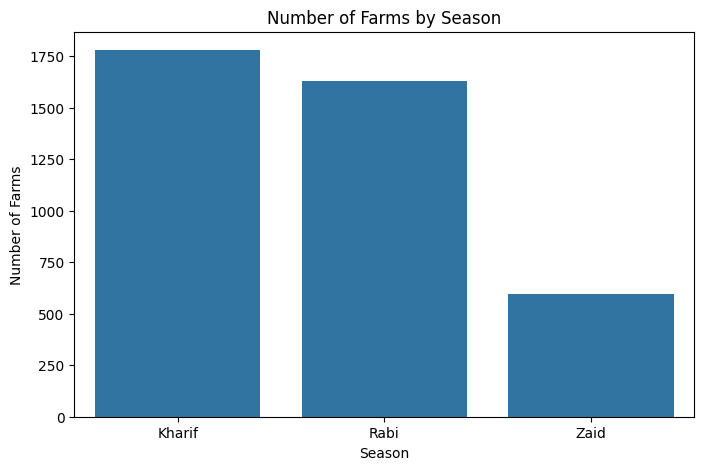

In [15]:
# Distribution of farms across seasons

season_counts = df['Season'].value_counts()

print(season_counts)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=season_counts.index,
    y=season_counts.values
)

plt.title('Number of Farms by Season')
plt.xlabel('Season')
plt.ylabel('Number of Farms')
plt.show()

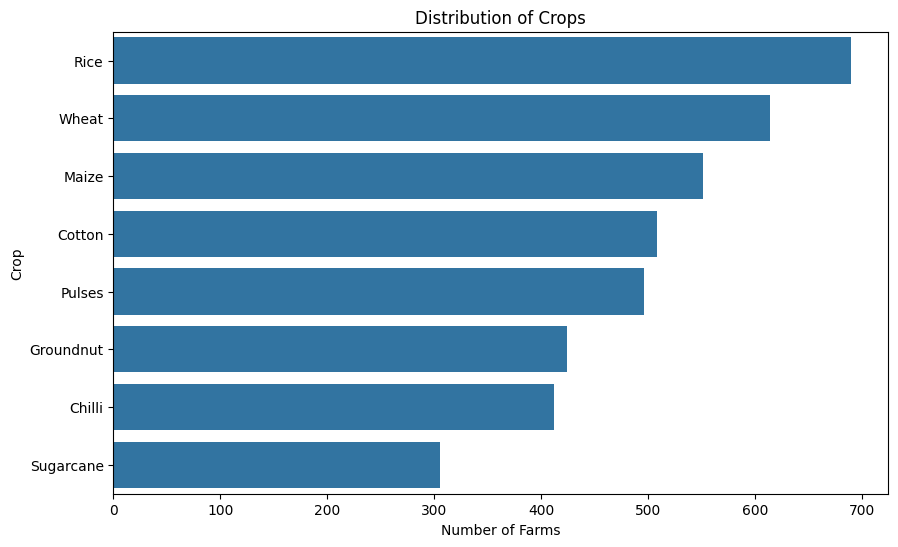

In [16]:
# Crop distribution

crop_counts = df['Crop'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(
    x=crop_counts.values,
    y=crop_counts.index
)

plt.title('Distribution of Crops')
plt.xlabel('Number of Farms')
plt.ylabel('Crop')
plt.show()

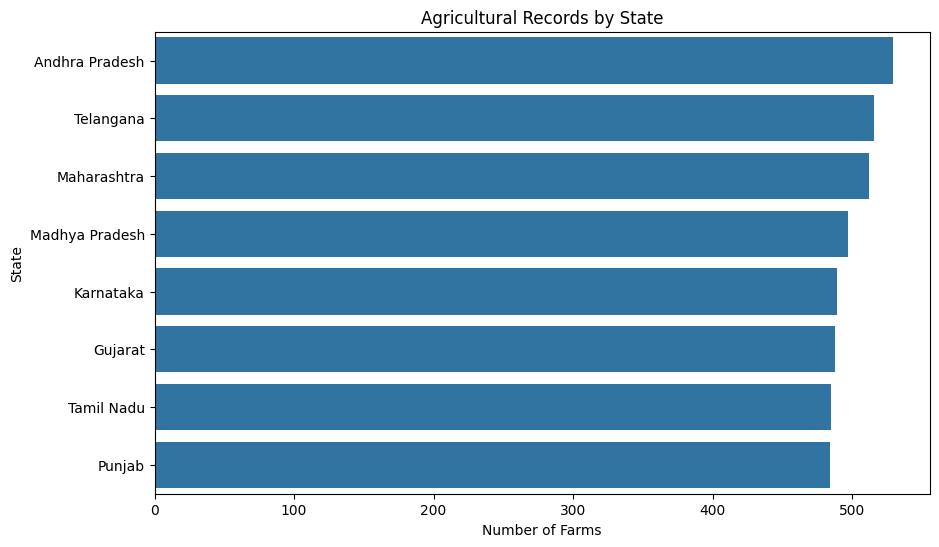

In [17]:
# State-wise distribution

state_counts = df['State'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(
    x=state_counts.values,
    y=state_counts.index
)

plt.title('Agricultural Records by State')
plt.xlabel('Number of Farms')
plt.ylabel('State')
plt.show()

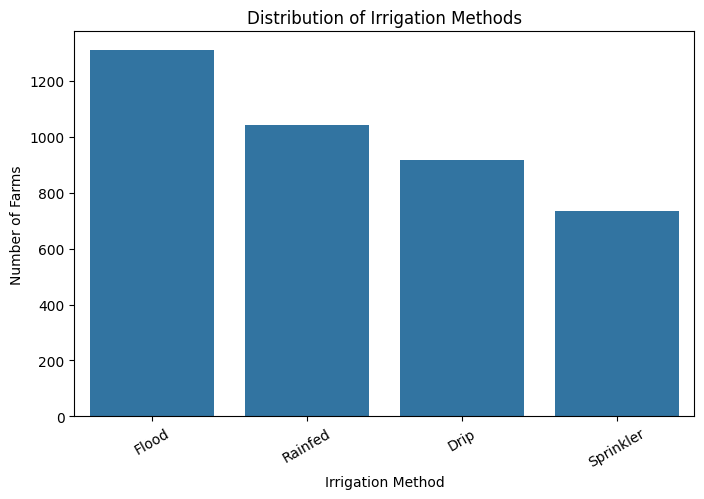

In [18]:
# Irrigation method distribution

irrigation_counts = df['Irrigation_Method'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(
    x=irrigation_counts.index,
    y=irrigation_counts.values
)

plt.title('Distribution of Irrigation Methods')
plt.xlabel('Irrigation Method')
plt.ylabel('Number of Farms')
plt.xticks(rotation=30)
plt.show()

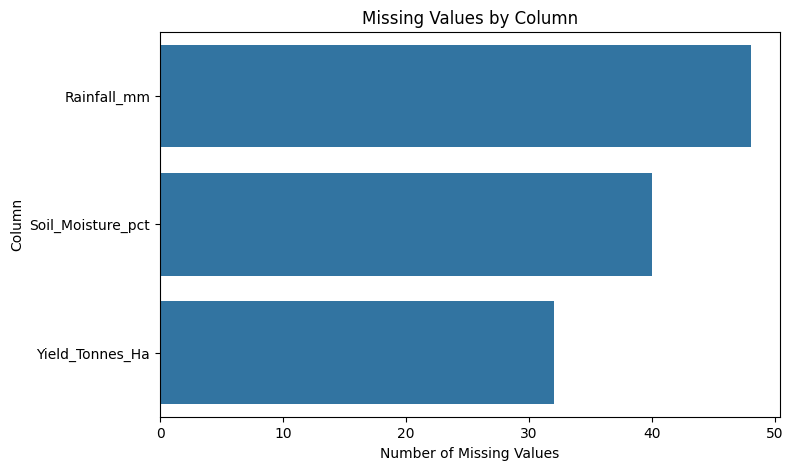

In [19]:
# Missing value analysis

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(
    x=missing.values,
    y=missing.index
)

plt.title('Missing Values by Column')
plt.xlabel('Number of Missing Values')
plt.ylabel('Column')
plt.show()

## 8. Data Cleaning and Preprocessing

The dataset contains missing observations in Rainfall, Soil Moisture and
Yield.

The following strategy is adopted:

1. Rainfall missing values are replaced using the median rainfall.
2. Soil moisture missing values are replaced using the median soil moisture.
3. Missing yield observations are retained in the main dataset but excluded
   from analyses where yield is the target variable.
4. Duplicate records are checked and removed if present.
5. Data types are verified before analysis.

In [20]:
# Create a working copy

df_clean = df.copy()

# Check duplicate records
print("Duplicates before cleaning:", df_clean.duplicated().sum())

# Remove duplicates
df_clean = df_clean.drop_duplicates()

# Median imputation for environmental variables
df_clean['Rainfall_mm'] = df_clean['Rainfall_mm'].fillna(
    df_clean['Rainfall_mm'].median()
)

df_clean['Soil_Moisture_pct'] = df_clean['Soil_Moisture_pct'].fillna(
    df_clean['Soil_Moisture_pct'].median()
)

print("Missing values after environmental cleaning:")
print(df_clean[['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']].isnull().sum())

Duplicates before cleaning: 0
Missing values after environmental cleaning:
Rainfall_mm           0
Soil_Moisture_pct     0
Yield_Tonnes_Ha      32
dtype: int64


# 9. Seasonal Performance Analysis

The primary objective of this project is to investigate how agricultural
performance differs across Kharif, Rabi and Zaid seasons.

The following performance indicators are compared:

- Yield
- Production
- Revenue
- Profit
- Farming Cost
- Water Usage
- Water Efficiency
- Environmental conditions
- Disease and Pest Risk

In [21]:
# Seasonal performance summary

season_summary = df_clean.groupby('Season').agg(
    Number_of_Farms=('Farm_ID', 'count'),
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Total_Production=('Production_Tonnes', 'sum'),
    Average_Revenue=('Revenue_INR', 'mean'),
    Average_Cost=('Total_Cost_INR', 'mean'),
    Average_Profit=('Profit_INR', 'mean'),
    Average_Water_Used=('Water_Used_m3', 'mean'),
    Average_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Average_Disease_Pest_Risk=('Disease_Pest_Risk_pct', 'mean')
).round(2)

season_summary

,Number_of_Farms,Average_Yield,Total_Production,Average_Revenue,Average_Cost,Average_Profit,Average_Water_Used,Average_Water_Efficiency,Average_Disease_Pest_Risk
Season,,,,,,,,,
Kharif,1779,5.64,82387.61,710719.06,531804.41,178914.65,6102.20,5.89,54.47
Rabi,1627,5.08,67498.88,601526.05,513836.58,87689.47,5846.99,5.19,40.48
Zaid,594,4.67,23098.35,519171.90,543976.73,-24804.82,6419.89,4.41,38.22


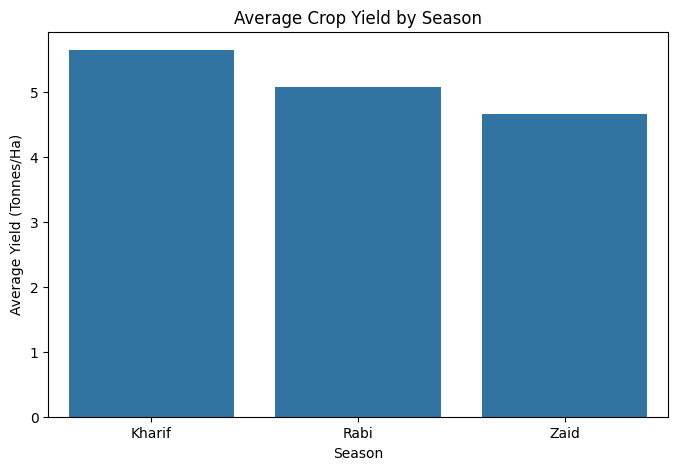

In [22]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x='Season',
    y='Yield_Tonnes_Ha',
    estimator='mean',
    errorbar=None
)

plt.title('Average Crop Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.show()

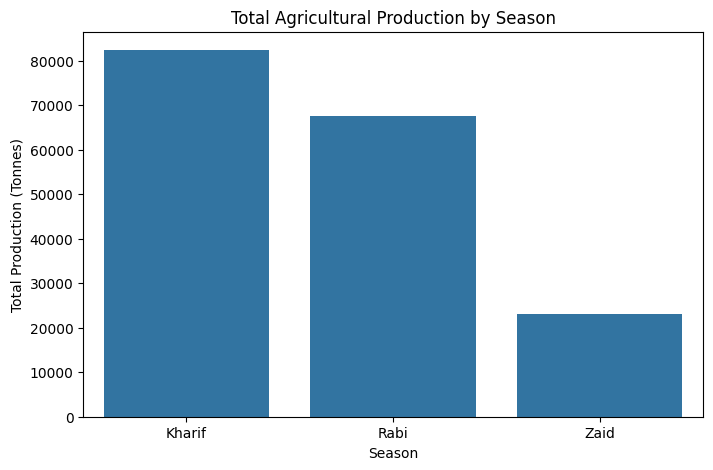

In [23]:
production_by_season = (
    df_clean.groupby('Season')['Production_Tonnes']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=production_by_season.index,
    y=production_by_season.values
)

plt.title('Total Agricultural Production by Season')
plt.xlabel('Season')
plt.ylabel('Total Production (Tonnes)')
plt.show()

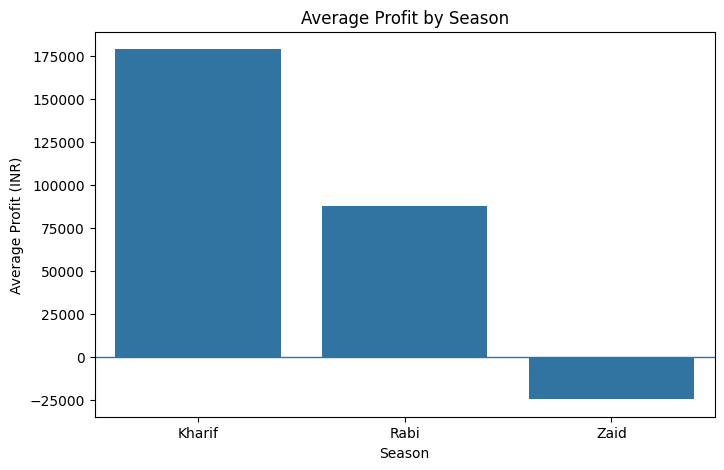

In [24]:
profit_by_season = (
    df_clean.groupby('Season')['Profit_INR']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=profit_by_season.index,
    y=profit_by_season.values
)

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.axhline(0, linewidth=1)

plt.show()

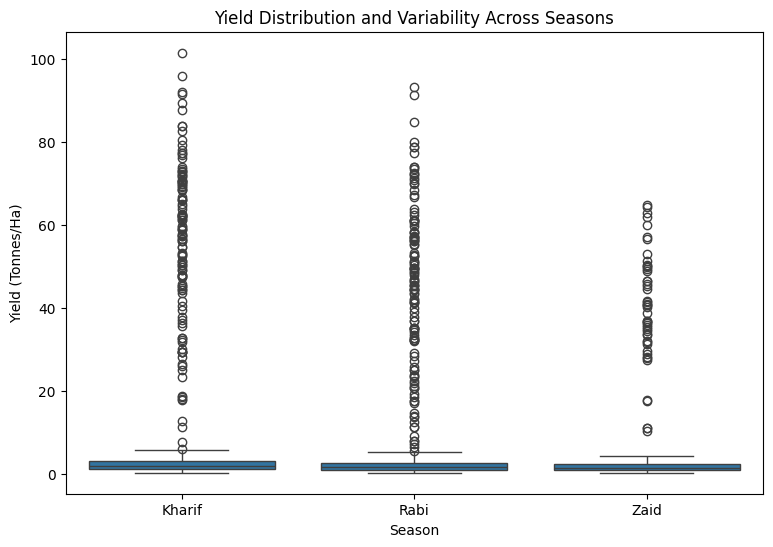

In [25]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_clean,
    x='Season',
    y='Yield_Tonnes_Ha'
)

plt.title('Yield Distribution and Variability Across Seasons')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')
plt.show()

## 10. Environmental Conditions Across Seasons

Environmental conditions play an important role in agricultural performance.
Rainfall, temperature, humidity, sunlight, soil moisture and soil pH can
influence crop growth, water availability, resource requirements and yield.

In this section, environmental variables are compared across Kharif, Rabi
and Zaid seasons to identify seasonal differences and understand the
environmental characteristics associated with each season.

The following variables are analyzed:

- Rainfall
- Average Temperature
- Humidity
- Sunlight Hours
- Soil Moisture
- Soil pH

In [26]:
# Calculate average environmental conditions for each season

environmental_summary = df_clean.groupby('Season').agg(
    Average_Rainfall=('Rainfall_mm', 'mean'),
    Average_Temperature=('Avg_Temperature_C', 'mean'),
    Average_Humidity=('Humidity_pct', 'mean'),
    Average_Sunlight=('Sunlight_Hours_Day', 'mean'),
    Average_Soil_Moisture=('Soil_Moisture_pct', 'mean'),
    Average_Soil_pH=('Soil_pH', 'mean')
).round(2)

environmental_summary

,Average_Rainfall,Average_Temperature,Average_Humidity,Average_Sunlight,Average_Soil_Moisture,Average_Soil_pH
Season,,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15,6.73
Rabi,437.62,23.49,57.89,7.59,24.07,6.67
Zaid,304.65,31.04,52.01,8.18,19.28,6.69


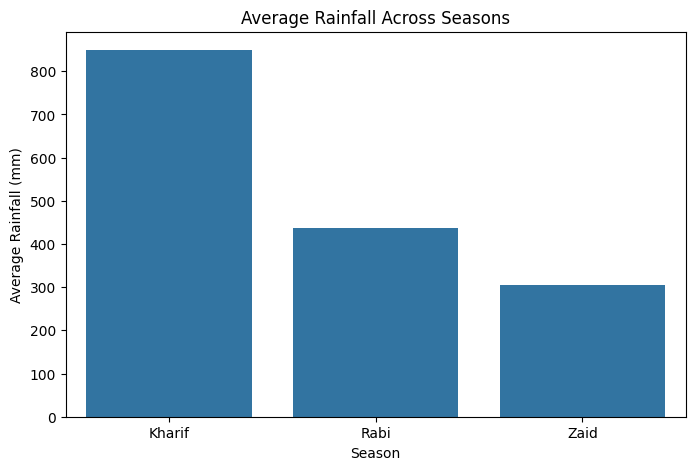

In [27]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x='Season',
    y='Rainfall_mm',
    estimator='mean',
    errorbar=None
)

plt.title('Average Rainfall Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Rainfall (mm)')
plt.show()

### Interpretation

Kharif records the highest average rainfall at approximately 852 mm,
which is substantially higher than Rabi and Zaid.

Rabi receives approximately 436 mm of rainfall, while Zaid receives
approximately 299 mm.

This indicates that rainfall availability differs considerably across
seasons and may influence irrigation requirements, soil moisture and
overall crop performance.

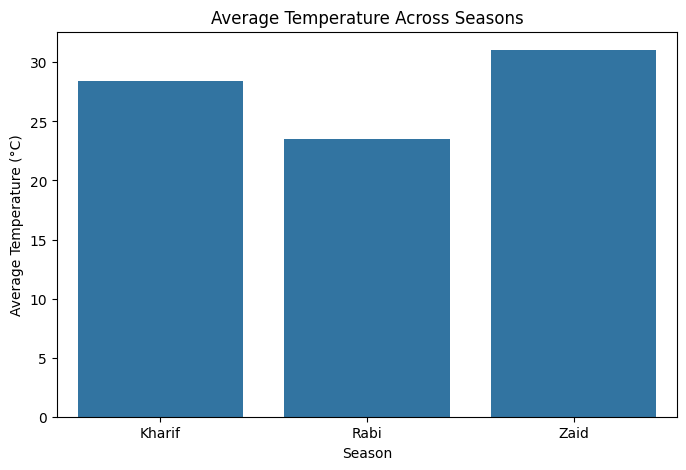

In [28]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x='Season',
    y='Avg_Temperature_C',
    estimator='mean',
    errorbar=None
)

plt.title('Average Temperature Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Temperature (°C)')
plt.show()

### Interpretation

Zaid has the highest average temperature at approximately 31.04°C,
followed by Kharif at 28.45°C.

Rabi has the lowest average temperature at approximately 23.49°C.

Therefore, the three seasons show clearly different temperature
conditions, with Zaid representing the warmest period and Rabi
representing the coolest period in the dataset.

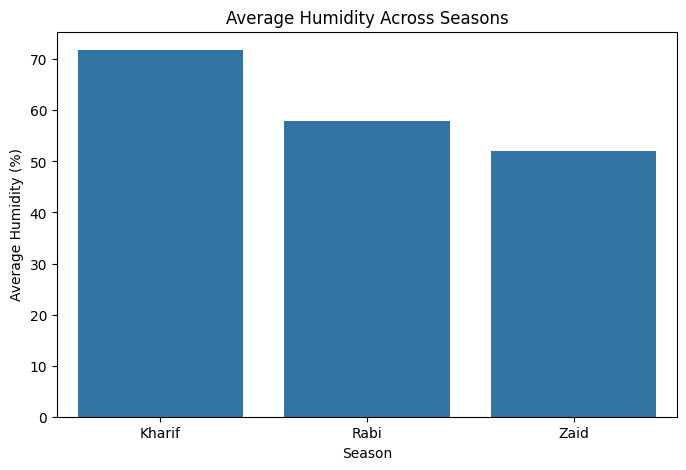

In [29]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x='Season',
    y='Humidity_pct',
    estimator='mean',
    errorbar=None
)

plt.title('Average Humidity Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Humidity (%)')
plt.show()

### Interpretation

Kharif has the highest average humidity at approximately 71.81%.

Rabi has moderate humidity of approximately 57.89%, while Zaid has
the lowest humidity at approximately 52.01%.

The higher humidity observed during Kharif is consistent with its
higher rainfall and soil moisture levels.

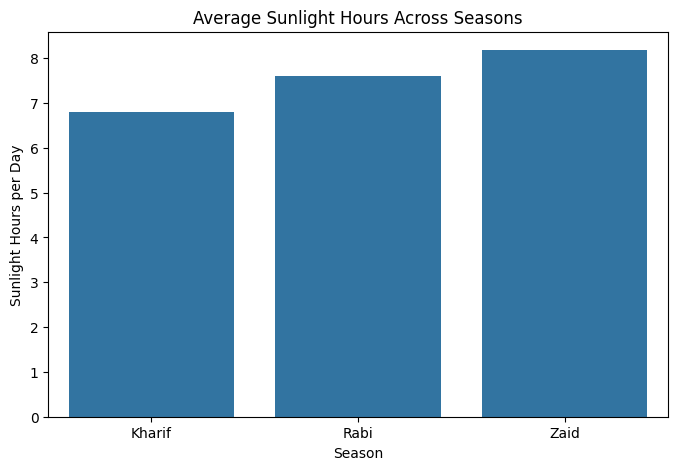

In [30]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x='Season',
    y='Sunlight_Hours_Day',
    estimator='mean',
    errorbar=None
)

plt.title('Average Sunlight Hours Across Seasons')
plt.xlabel('Season')
plt.ylabel('Sunlight Hours per Day')
plt.show()

### Interpretation

Zaid has the highest average sunlight exposure at approximately
8.18 hours per day.

Rabi receives approximately 7.59 hours per day, while Kharif
has the lowest average sunlight exposure at approximately
6.79 hours per day.

This indicates an inverse seasonal pattern between rainfall and
sunlight exposure in the dataset.

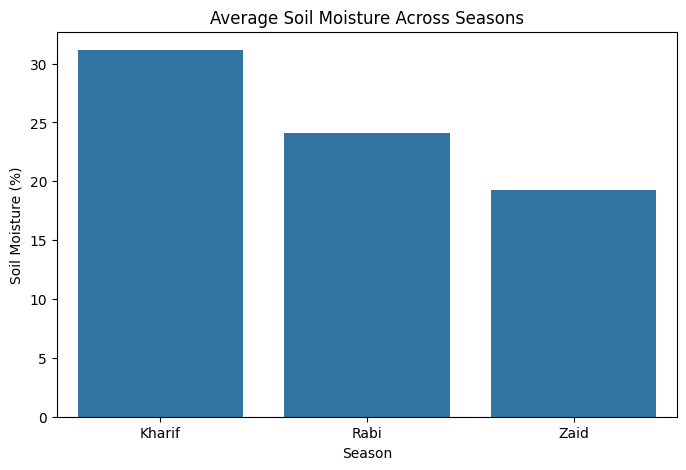

In [31]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x='Season',
    y='Soil_Moisture_pct',
    estimator='mean',
    errorbar=None
)

plt.title('Average Soil Moisture Across Seasons')
plt.xlabel('Season')
plt.ylabel('Soil Moisture (%)')
plt.show()

### Interpretation

Kharif has the highest average soil moisture at approximately 31.20%.

Rabi has an average soil moisture of approximately 24.05%, while
Zaid has the lowest value at approximately 19.17%.

The pattern broadly follows rainfall availability, with Kharif
having both the highest rainfall and soil moisture and Zaid having
the lowest levels of both.

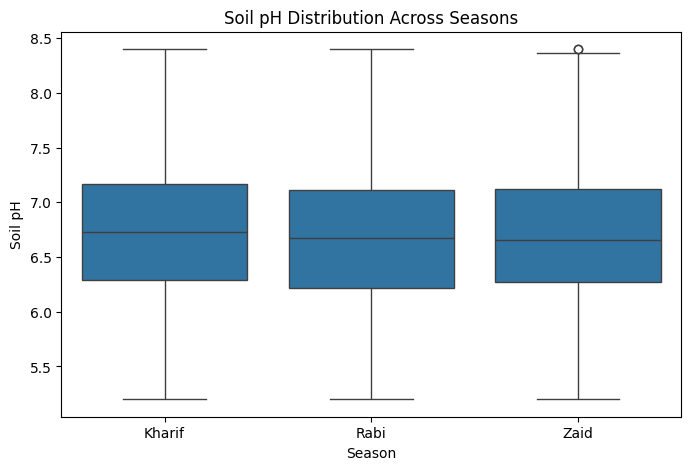

In [32]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x='Season',
    y='Soil_pH'
)

plt.title('Soil pH Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Soil pH')
plt.show()

### Interpretation

Average soil pH is relatively similar across all three seasons.

The average values are approximately:

- Kharif: 6.73
- Rabi: 6.67
- Zaid: 6.69

Therefore, unlike rainfall, temperature and soil moisture, soil pH
does not show a major seasonal difference in this dataset.

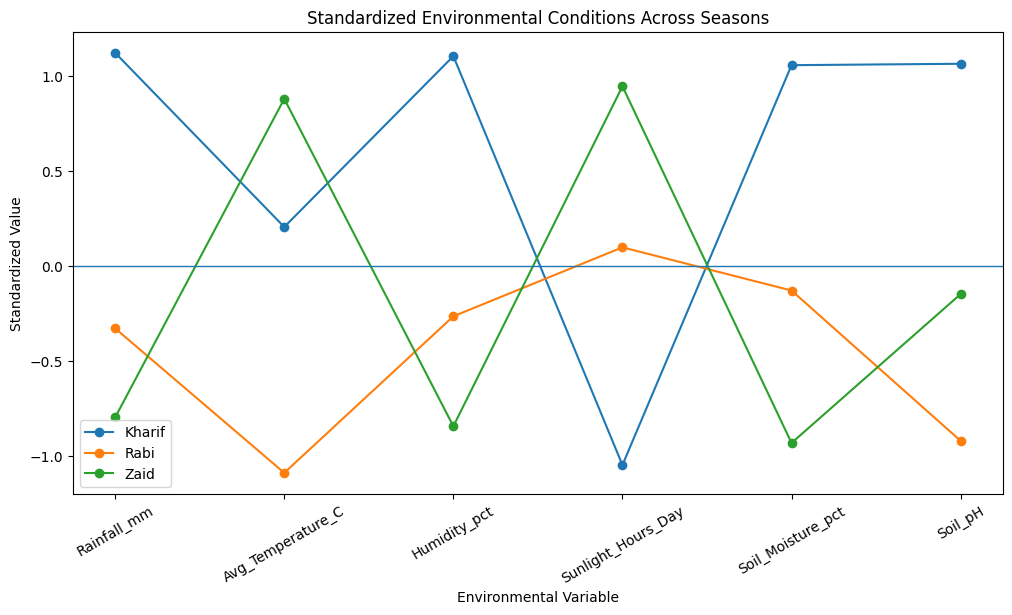

In [33]:
# Select environmental variables

environmental_columns = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_Moisture_pct',
    'Soil_pH'
]

# Calculate seasonal means

seasonal_environment = df_clean.groupby('Season')[environmental_columns].mean()

# Standardize each variable

standardized_environment = (
    seasonal_environment - seasonal_environment.mean()
) / seasonal_environment.std()

plt.figure(figsize=(12, 6))

for season in standardized_environment.index:
    plt.plot(
        standardized_environment.columns,
        standardized_environment.loc[season],
        marker='o',
        label=season
    )

plt.axhline(0, linewidth=1)

plt.title('Standardized Environmental Conditions Across Seasons')
plt.xlabel('Environmental Variable')
plt.ylabel('Standardized Value')
plt.xticks(rotation=30)
plt.legend()
plt.show()

In [34]:
# Correlation between environmental variables and yield

environment_yield_corr = df_clean[
    environmental_columns + ['Yield_Tonnes_Ha']
].corr()['Yield_Tonnes_Ha'].sort_values(ascending=False)

environment_yield_corr

Yield_Tonnes_Ha       1.00
Rainfall_mm           0.03
Humidity_pct          0.01
Soil_Moisture_pct     0.01
Avg_Temperature_C     0.01
Sunlight_Hours_Day   -0.02
Soil_pH              -0.02
Name: Yield_Tonnes_Ha, dtype: float64

In [35]:
# Correlation between environmental variables and yield for each season

season_environment_yield_corr = {}

for season in df_clean['Season'].dropna().unique():

    season_data = df_clean[df_clean['Season'] == season]

    season_corr = season_data[
        environmental_columns + ['Yield_Tonnes_Ha']
    ].corr()['Yield_Tonnes_Ha'].drop('Yield_Tonnes_Ha')

    season_environment_yield_corr[season] = season_corr

season_corr_df = pd.DataFrame(season_environment_yield_corr)

season_corr_df.round(3)

,Kharif,Rabi,Zaid
Rainfall_mm,-0.01,0.04,0.05
Avg_Temperature_C,-0.01,0.05,-0.04
Humidity_pct,-0.02,0.02,-0.06
Sunlight_Hours_Day,-0.02,0.01,0.02
Soil_Moisture_pct,0.00,-0.02,-0.03
Soil_pH,-0.03,-0.02,-0.02


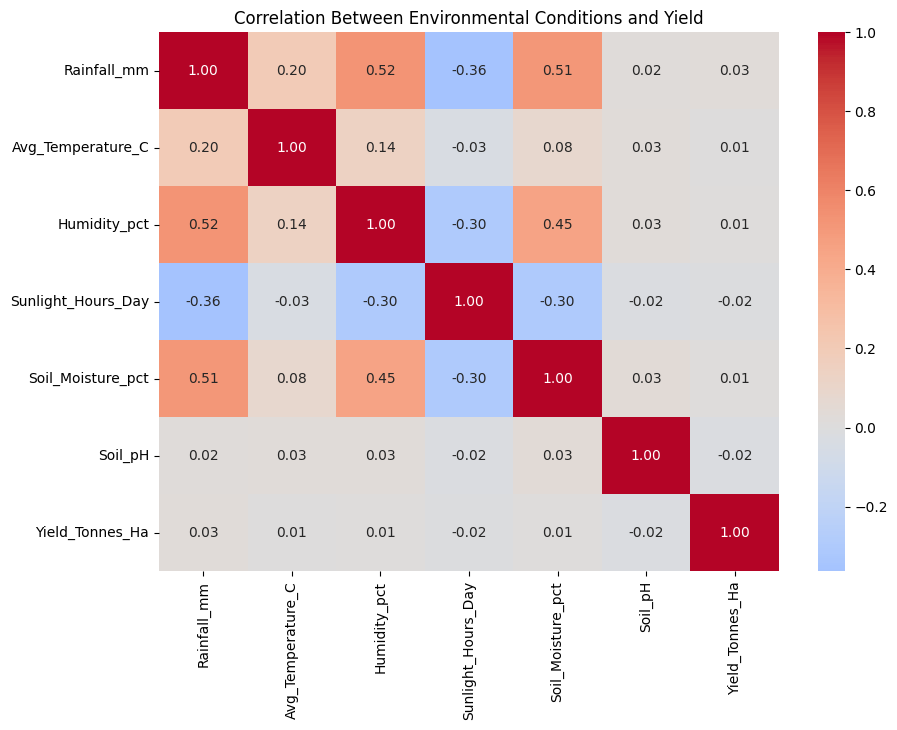

In [36]:
# Correlation matrix for environmental variables and yield

correlation_matrix = df_clean[
    environmental_columns + ['Yield_Tonnes_Ha']
].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Between Environmental Conditions and Yield')
plt.show()

## 10.12 Key Findings from Environmental Analysis

The environmental analysis reveals clear differences between the three
agricultural seasons.

### Kharif

Kharif has the highest rainfall, humidity and soil moisture levels.
It also has the lowest average sunlight exposure among the three seasons.

### Rabi

Rabi has the lowest average temperature and moderate rainfall,
humidity and soil moisture conditions.

### Zaid

Zaid is characterized by the highest average temperature and sunlight
exposure. It also has the lowest rainfall, humidity and soil moisture.

### Soil pH

Soil pH remains relatively stable across the seasons, indicating that
seasonal differences in soil pH are limited in this dataset.

### Relationship with Yield

The overall correlations between individual environmental variables
and yield are weak. Therefore, agricultural performance cannot be
explained by environmental conditions alone.

This suggests that crop type, irrigation, fertilizer, soil nutrients,
seed quality and other farming practices should also be investigated.

These findings motivate the next stage of the analysis, which focuses on
resource utilization and farming practices across seasons.

## 11. Resource Usage Analysis

Agricultural performance depends not only on environmental conditions but
also on the efficient utilization of agricultural resources.

Excessive or inefficient use of water, fertilizer and pesticides can
increase production costs and may not necessarily result in higher yield.

In this section, resource utilization is analyzed across different
seasons to identify:

- Seasonal differences in water consumption
- Distribution of irrigation methods
- Fertilizer usage patterns
- Pesticide usage patterns
- Water-use efficiency
- Relationships between resource usage and agricultural yield
- Potential differences in resource efficiency across seasons

The analysis will help determine whether differences in resource
utilization may contribute to the observed differences in agricultural
performance.

In [37]:
resource_summary = df_clean.groupby('Season').agg(
    Average_Fertilizer=('Fertilizer_kg_ha', 'mean'),
    Average_Pesticide=('Pesticide_Litre_ha', 'mean'),
    Average_Water_Used=('Water_Used_m3', 'mean'),
    Average_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Average_Farm_Area=('Farm_Area_Hectares', 'mean')
).round(2)

resource_summary

,Average_Fertilizer,Average_Pesticide,Average_Water_Used,Average_Water_Efficiency,Average_Farm_Area
Season,,,,,
Kharif,187.08,5.08,6102.20,5.89,7.94
Rabi,185.41,5.02,5846.99,5.19,7.75
Zaid,184.64,5.17,6419.89,4.41,8.09


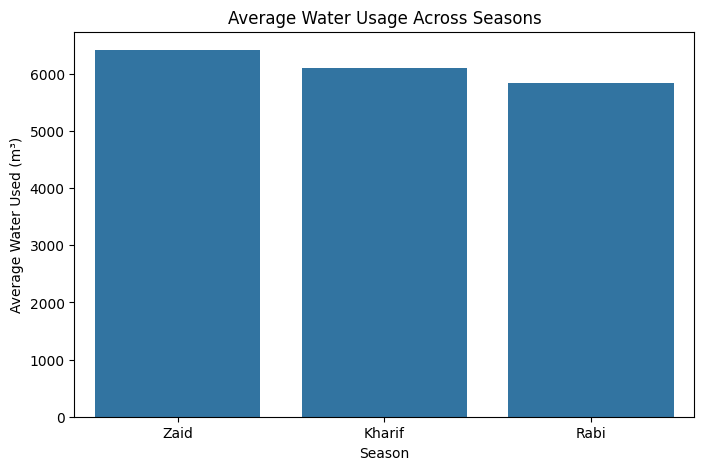

In [38]:
# Average water usage by season

water_usage = (
    df_clean.groupby('Season')['Water_Used_m3']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=water_usage.index,
    y=water_usage.values
)

plt.title('Average Water Usage Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Water Used (m³)')

plt.show()

### Interpretation

Water consumption is compared across Kharif, Rabi and Zaid to understand
whether seasonal environmental conditions are associated with differences
in irrigation and water requirements.

Because Kharif receives substantially more rainfall than Rabi and Zaid,
it is important to determine whether this translates into lower or higher
water usage.

The result should be interpreted together with rainfall and irrigation
method rather than considering water consumption independently.

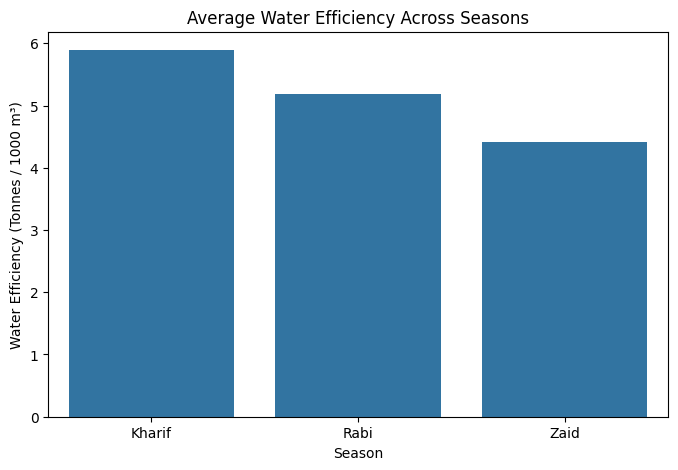

In [39]:
# Water efficiency by season

water_efficiency = (
    df_clean.groupby('Season')['Water_Efficiency_t_per_1000m3']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=water_efficiency.index,
    y=water_efficiency.values
)

plt.title('Average Water Efficiency Across Seasons')
plt.xlabel('Season')
plt.ylabel('Water Efficiency (Tonnes / 1000 m³)')

plt.show()

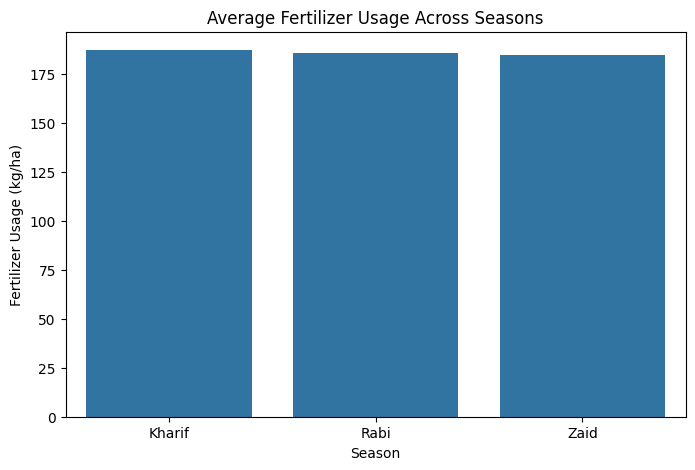

In [40]:
# Average fertilizer usage

fertilizer_usage = (
    df_clean.groupby('Season')['Fertilizer_kg_ha']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=fertilizer_usage.index,
    y=fertilizer_usage.values
)

plt.title('Average Fertilizer Usage Across Seasons')
plt.xlabel('Season')
plt.ylabel('Fertilizer Usage (kg/ha)')

plt.show()

### Interpretation

Fertilizer usage is compared across seasons to determine whether
agricultural input intensity differs between Kharif, Rabi and Zaid.

Higher fertilizer usage should not automatically be interpreted as
better agricultural performance.

Its relationship with yield must be examined using correlation,
seasonal comparisons and crop-level analysis.

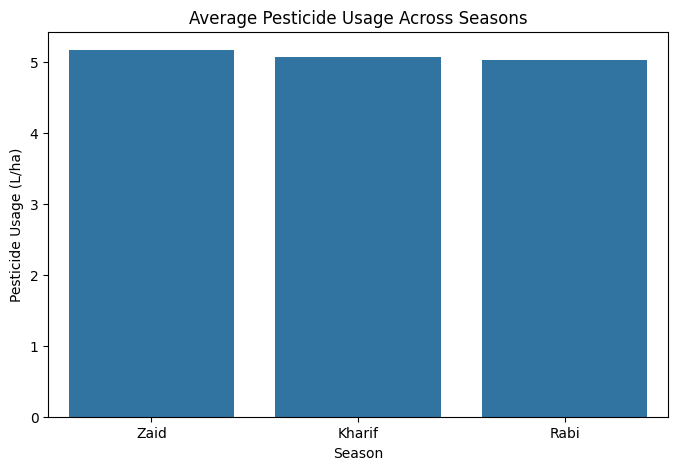

In [41]:
# Average pesticide usage

pesticide_usage = (
    df_clean.groupby('Season')['Pesticide_Litre_ha']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=pesticide_usage.index,
    y=pesticide_usage.values
)

plt.title('Average Pesticide Usage Across Seasons')
plt.xlabel('Season')
plt.ylabel('Pesticide Usage (L/ha)')

plt.show()

### Interpretation

Pesticide usage is analyzed to determine whether agricultural input
requirements vary across seasons.

This analysis is particularly relevant because the dataset also contains
a Disease_Pest_Risk variable.

Comparing pesticide usage with disease and pest risk can help determine
whether seasons with greater agricultural risk also show greater
pesticide application.

In [42]:
# Cross-tabulation of irrigation method and season

irrigation_season = pd.crosstab(
    df_clean['Season'],
    df_clean['Irrigation_Method']
)

irrigation_season

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,405,590,463,321
Rabi,370,526,438,293
Zaid,140,194,140,120


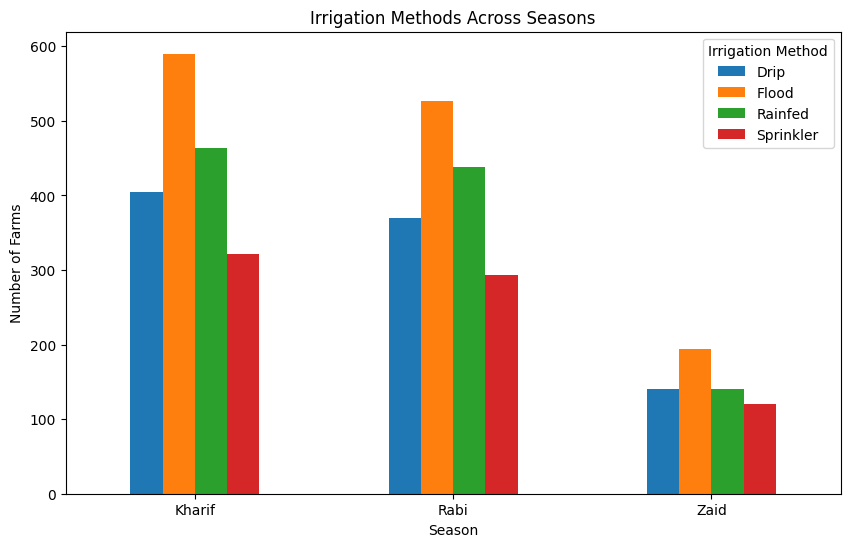

In [43]:
# Stacked bar chart for irrigation methods across seasons

irrigation_season.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Irrigation Methods Across Seasons')
plt.xlabel('Season')
plt.ylabel('Number of Farms')
plt.xticks(rotation=0)
plt.legend(title='Irrigation Method')

plt.show()

In [44]:
# Percentage distribution of irrigation methods within each season

irrigation_percentage = pd.crosstab(
    df_clean['Season'],
    df_clean['Irrigation_Method'],
    normalize='index'
) * 100

irrigation_percentage.round(2)

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.77,33.16,26.03,18.04
Rabi,22.74,32.33,26.92,18.01
Zaid,23.57,32.66,23.57,20.20


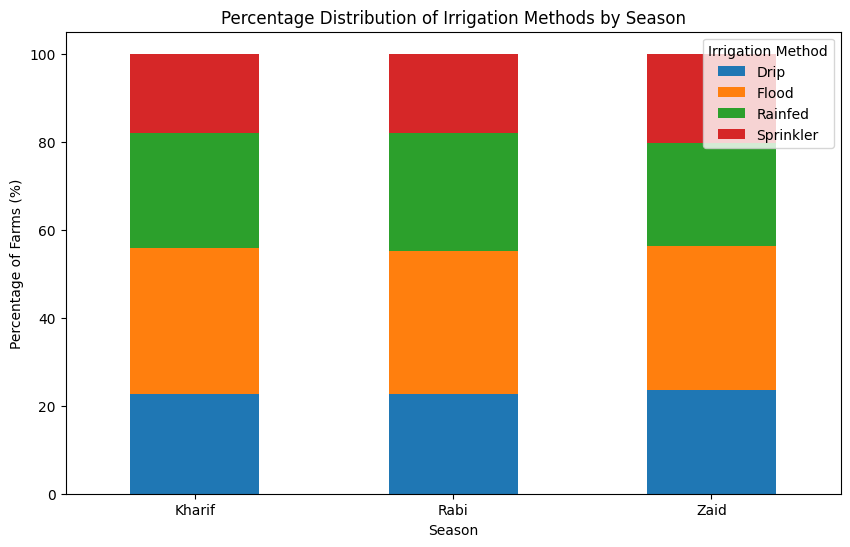

In [45]:
irrigation_percentage.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6)
)

plt.title('Percentage Distribution of Irrigation Methods by Season')
plt.xlabel('Season')
plt.ylabel('Percentage of Farms (%)')
plt.xticks(rotation=0)
plt.legend(title='Irrigation Method')

plt.show()

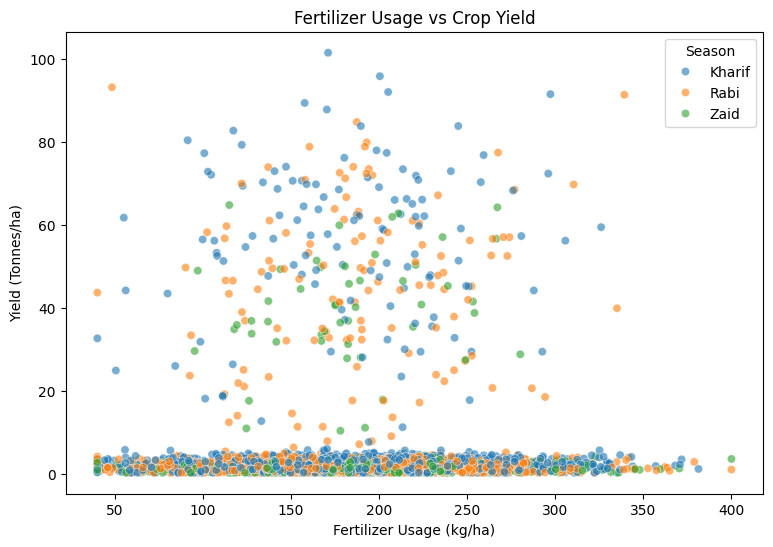

In [46]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_clean,
    x='Fertilizer_kg_ha',
    y='Yield_Tonnes_Ha',
    hue='Season',
    alpha=0.6
)

plt.title('Fertilizer Usage vs Crop Yield')
plt.xlabel('Fertilizer Usage (kg/ha)')
plt.ylabel('Yield (Tonnes/ha)')

plt.show()

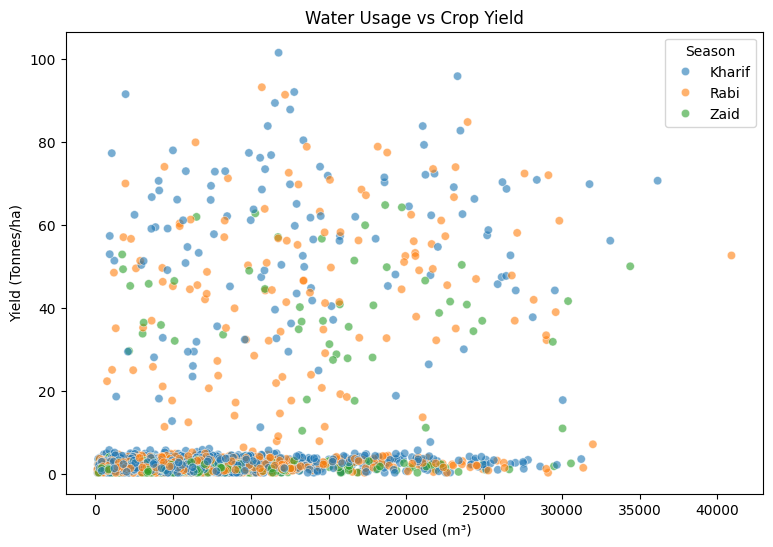

In [47]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_clean,
    x='Water_Used_m3',
    y='Yield_Tonnes_Ha',
    hue='Season',
    alpha=0.6
)

plt.title('Water Usage vs Crop Yield')
plt.xlabel('Water Used (m³)')
plt.ylabel('Yield (Tonnes/ha)')

plt.show()

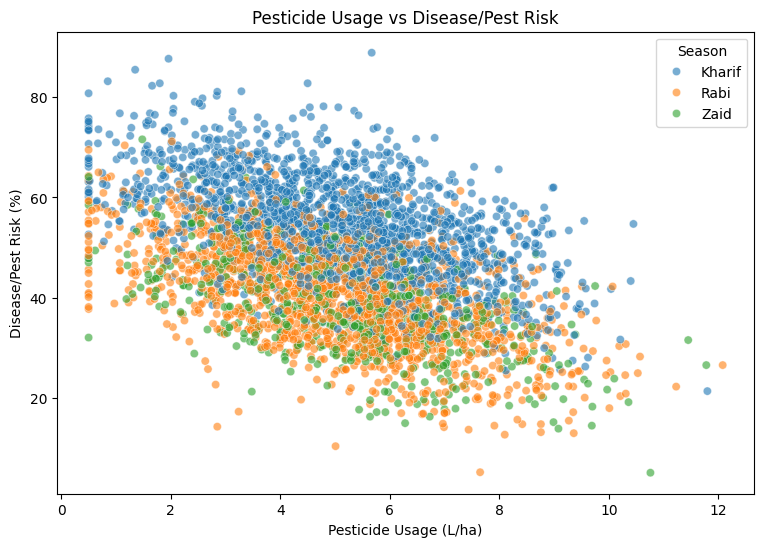

In [48]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_clean,
    x='Pesticide_Litre_ha',
    y='Disease_Pest_Risk_pct',
    hue='Season',
    alpha=0.6
)

plt.title('Pesticide Usage vs Disease/Pest Risk')
plt.xlabel('Pesticide Usage (L/ha)')
plt.ylabel('Disease/Pest Risk (%)')

plt.show()

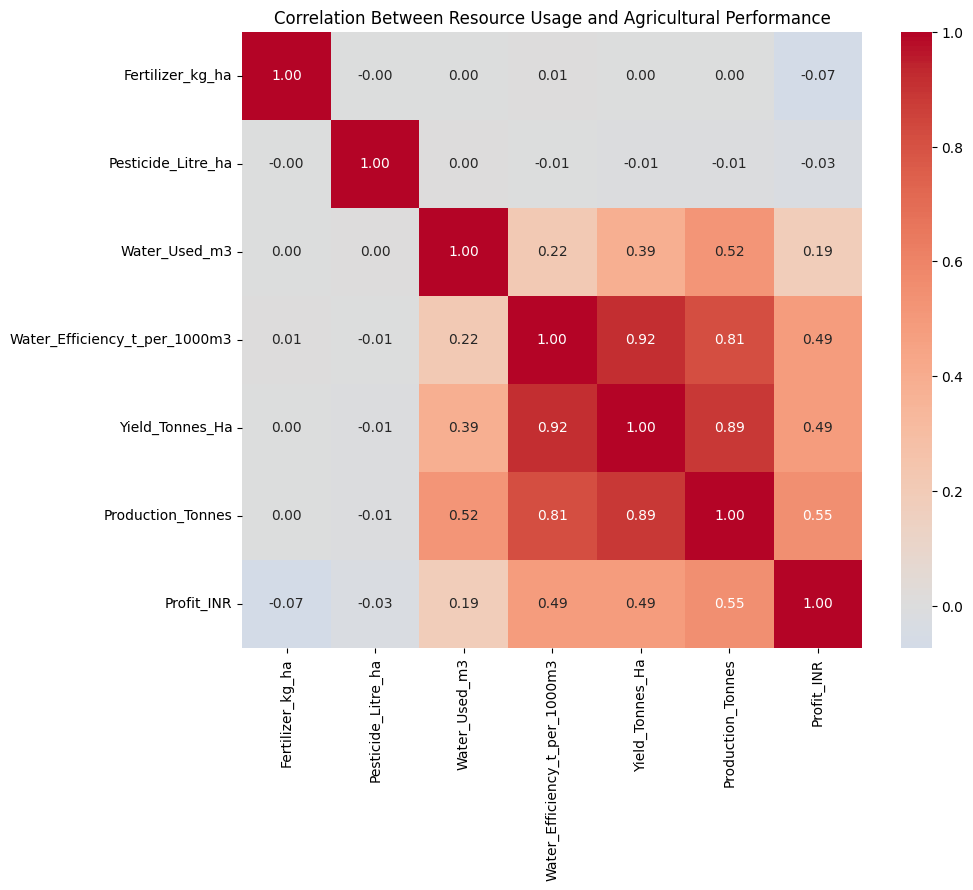

In [49]:
# Resource and yield correlation matrix

resource_columns = [
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Profit_INR'
]

resource_corr = df_clean[resource_columns].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    resource_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Between Resource Usage and Agricultural Performance')

plt.show()

In [50]:
# Correlation of resource variables with yield

yield_resource_corr = (
    df_clean[resource_columns]
    .corr()['Yield_Tonnes_Ha']
    .drop('Yield_Tonnes_Ha')
    .sort_values(ascending=False)
)

yield_resource_corr.round(3)

Water_Efficiency_t_per_1000m3    0.92
Production_Tonnes                0.89
Profit_INR                       0.49
Water_Used_m3                    0.39
Fertilizer_kg_ha                 0.00
Pesticide_Litre_ha              -0.01
Name: Yield_Tonnes_Ha, dtype: float64

In [51]:
# Seasonal resource efficiency overview

seasonal_resource_efficiency = df_clean.groupby('Season').agg(
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Water=('Water_Used_m3', 'mean'),
    Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Avg_Fertilizer=('Fertilizer_kg_ha', 'mean'),
    Avg_Pesticide=('Pesticide_Litre_ha', 'mean'),
    Avg_Profit=('Profit_INR', 'mean')
).round(2)

seasonal_resource_efficiency

,Avg_Yield,Avg_Water,Avg_Water_Efficiency,Avg_Fertilizer,Avg_Pesticide,Avg_Profit
Season,,,,,,
Kharif,5.64,6102.20,5.89,187.08,5.08,178914.65
Rabi,5.08,5846.99,5.19,185.41,5.02,87689.47
Zaid,4.67,6419.89,4.41,184.64,5.17,-24804.82


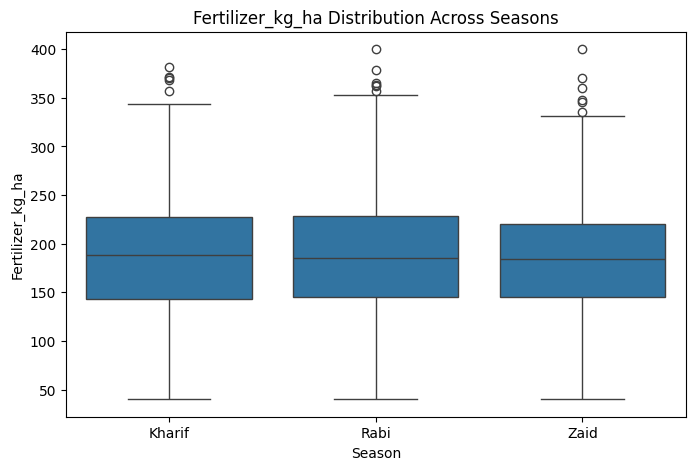

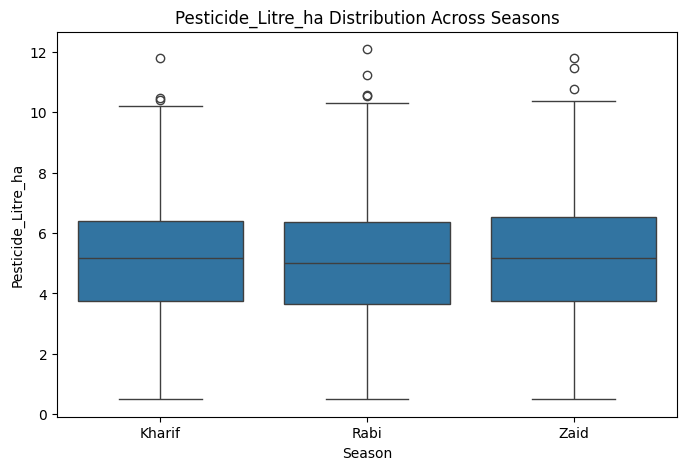

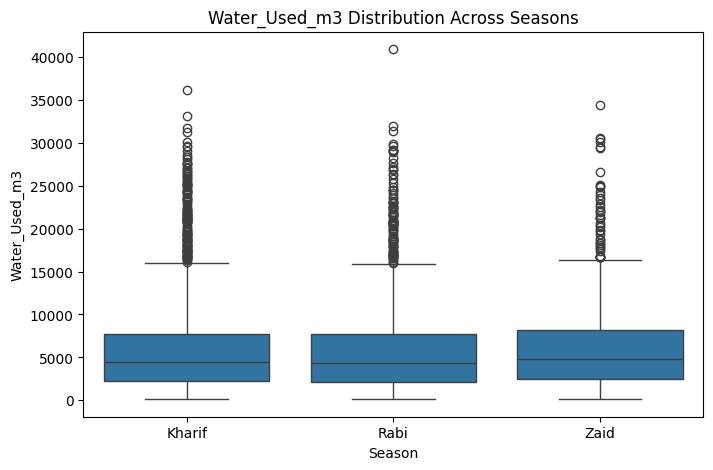

In [52]:
resource_metrics = [
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Water_Used_m3'
]

for metric in resource_metrics:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df_clean,
        x='Season',
        y=metric
    )

    plt.title(f'{metric} Distribution Across Seasons')
    plt.xlabel('Season')
    plt.ylabel(metric)

    plt.show()

In [53]:
# Average resource usage by crop

crop_resource_summary = df_clean.groupby('Crop').agg(
    Average_Water=('Water_Used_m3', 'mean'),
    Average_Fertilizer=('Fertilizer_kg_ha', 'mean'),
    Average_Pesticide=('Pesticide_Litre_ha', 'mean'),
    Average_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
    Average_Yield=('Yield_Tonnes_Ha', 'mean')
).round(2)

crop_resource_summary.sort_values(
    'Average_Yield',
    ascending=False
)

,Average_Water,Average_Fertilizer,Average_Pesticide,Average_Water_Efficiency,Average_Yield
Crop,,,,,
Sugarcane,13897.70,184.29,5.04,30.48,46.94
Maize,4377.78,191.32,5.11,5.60,2.72
Rice,10920.22,185.51,5.06,1.95,2.44
Wheat,4054.40,183.21,5.01,4.63,2.11
Chilli,4577.47,188.73,5.13,2.95,1.54
Groundnut,3459.54,186.64,5.14,3.15,1.32
Cotton,5410.86,185.42,5.11,1.94,1.23
Pulses,2833.67,183.34,4.99,2.90,0.92


In [54]:
# Resource usage by irrigation method

irrigation_resource_summary = df_clean.groupby(
    'Irrigation_Method'
).agg(
    Average_Water=('Water_Used_m3', 'mean'),
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Average_Water_Efficiency=(
        'Water_Efficiency_t_per_1000m3',
        'mean'
    ),
    Average_Profit=('Profit_INR', 'mean')
).round(2)

irrigation_resource_summary.sort_values(
    'Average_Water_Efficiency',
    ascending=False
)

,Average_Water,Average_Yield,Average_Water_Efficiency,Average_Profit
Irrigation_Method,,,,
Rainfed,3549.55,4.61,7.56,79050.37
Drip,5918.75,6.62,6.27,219626.00
Sprinkler,6208.26,5.19,4.67,91121.08
Flood,8026.47,4.90,3.44,73354.02


## 11.17 Key Findings from Resource Usage Analysis

The resource analysis demonstrates that agricultural resource utilization
varies across seasons.

### Water Usage

Water consumption differs across seasons and should be interpreted
alongside rainfall, soil moisture and irrigation practices.

### Water Efficiency

Kharif shows the highest average water efficiency among the three seasons,
while Zaid shows the lowest average water efficiency.

This suggests that water availability and seasonal conditions may be
important when evaluating resource efficiency.

### Fertilizer and Pesticide

Fertilizer and pesticide usage vary across agricultural activities.
However, higher input usage should not automatically be interpreted as
better agricultural performance.

### Irrigation

Irrigation methods show different distributions across seasons. Examining
these differences provides additional insight into how farms manage water
resources under different seasonal conditions.

### Resource–Yield Relationships

Correlation and scatter-plot analysis is used to investigate relationships
between fertilizer, pesticide, water usage and agricultural yield.

These relationships should be interpreted carefully because agricultural
yield depends on multiple factors, including crop type, soil conditions,
environmental conditions, irrigation, seed quality and farming practices.

### Overall Observation

Resource utilization provides an important additional dimension for
understanding seasonal agricultural performance. The next analysis will
therefore examine crop production and yield in greater detail, including
differences between crops and seasons.

## 12. Production and Yield Analysis

Agricultural performance can be evaluated using crop yield and total
production.

Yield represents the quantity of agricultural output obtained per hectare,
while production represents the total quantity produced by a farm.

In this section, yield and production are analyzed across seasons, crops
and geographical regions.

The analysis aims to determine:

- How yield varies across seasons
- How total production varies across seasons
- Which crops have higher productivity
- Which crops contribute more to total production
- How crop performance changes between seasons
- Which states demonstrate stronger agricultural output
- How farm area is related to production
- Whether unusual yield or production observations exist

In [55]:
# Basic statistics for yield

yield_stats = df_clean['Yield_Tonnes_Ha'].describe()

yield_stats

count   3968.00
mean       5.27
std       13.36
min        0.30
25%        1.05
50%        1.74
75%        2.84
max      101.44
Name: Yield_Tonnes_Ha, dtype: float64

In [56]:
# Missing yield observations

print(
    "Missing Yield Values:",
    df_clean['Yield_Tonnes_Ha'].isna().sum()
)

print(
    "Available Yield Observations:",
    df_clean['Yield_Tonnes_Ha'].notna().sum()
)

Missing Yield Values: 32
Available Yield Observations: 3968


In [57]:
# Dataset containing valid yield observations

yield_df = df_clean.dropna(
    subset=['Yield_Tonnes_Ha']
).copy()

print("Rows available for yield analysis:", len(yield_df))

Rows available for yield analysis: 3968


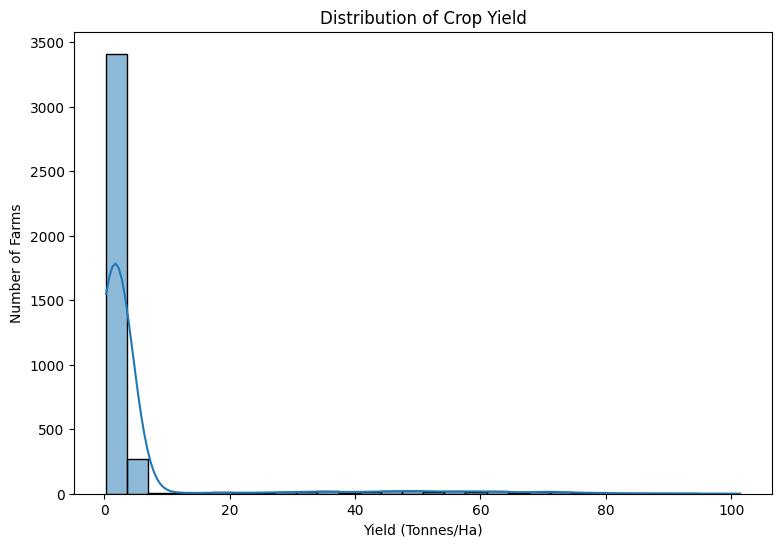

In [58]:
plt.figure(figsize=(9, 6))

sns.histplot(
    data=yield_df,
    x='Yield_Tonnes_Ha',
    bins=30,
    kde=True
)

plt.title('Distribution of Crop Yield')
plt.xlabel('Yield (Tonnes/Ha)')
plt.ylabel('Number of Farms')

plt.show()

### Interpretation

The yield distribution shows how crop productivity varies across the
farms in the dataset.

The histogram helps identify the central range of yield values and whether
the distribution contains extreme observations.

The presence of high or low yield observations will be investigated further
using box plots and outlier analysis.

In [59]:
season_yield = yield_df.groupby('Season').agg(
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Median_Yield=('Yield_Tonnes_Ha', 'median'),
    Minimum_Yield=('Yield_Tonnes_Ha', 'min'),
    Maximum_Yield=('Yield_Tonnes_Ha', 'max'),
    Standard_Deviation=('Yield_Tonnes_Ha', 'std')
).round(2)

season_yield

,Average_Yield,Median_Yield,Minimum_Yield,Maximum_Yield,Standard_Deviation
Season,,,,,
Kharif,5.64,1.95,0.30,101.44,14.42
Rabi,5.08,1.66,0.30,93.13,12.83
Zaid,4.67,1.45,0.30,64.76,11.32


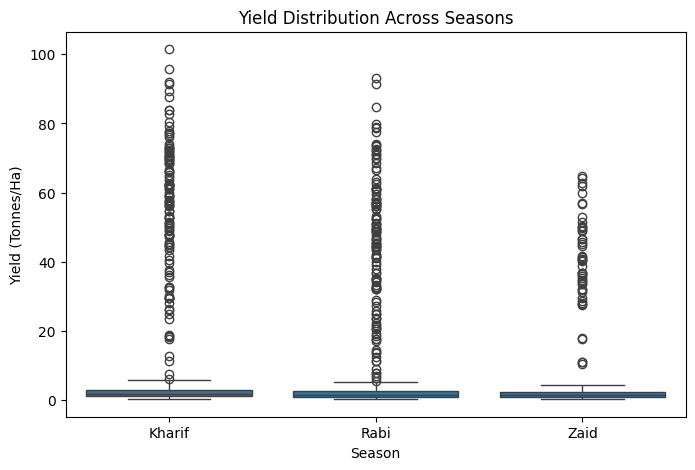

In [60]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=yield_df,
    x='Season',
    y='Yield_Tonnes_Ha'
)

plt.title('Yield Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

In [61]:
season_production = df_clean.groupby('Season').agg(
    Total_Production=('Production_Tonnes', 'sum'),
    Average_Production=('Production_Tonnes', 'mean'),
    Median_Production=('Production_Tonnes', 'median')
).round(2)

season_production

,Total_Production,Average_Production,Median_Production
Season,,,
Kharif,82387.61,46.31,13.24
Rabi,67498.88,41.49,11.08
Zaid,23098.35,38.89,9.97


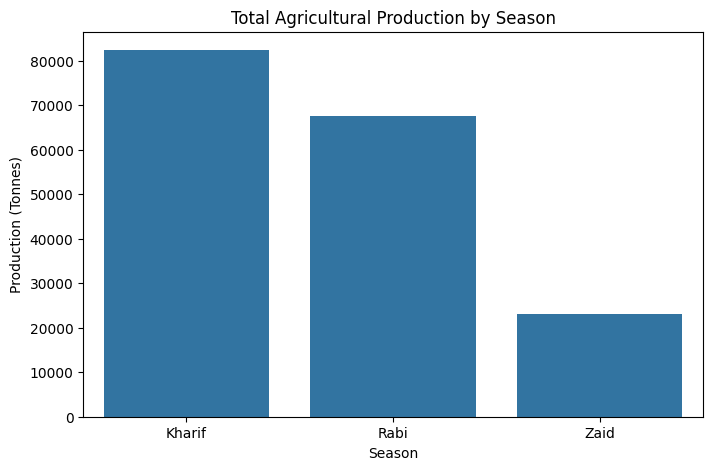

In [62]:
production = (
    df_clean.groupby('Season')['Production_Tonnes']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=production.index,
    y=production.values
)

plt.title('Total Agricultural Production by Season')
plt.xlabel('Season')
plt.ylabel('Production (Tonnes)')

plt.show()

In [63]:
crop_yield = yield_df.groupby('Crop').agg(
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Median_Yield=('Yield_Tonnes_Ha', 'median'),
    Minimum_Yield=('Yield_Tonnes_Ha', 'min'),
    Maximum_Yield=('Yield_Tonnes_Ha', 'max'),
    Number_of_Farms=('Farm_ID', 'count')
).sort_values(
    'Average_Yield',
    ascending=False
).round(2)

crop_yield

,Average_Yield,Median_Yield,Minimum_Yield,Maximum_Yield,Number_of_Farms
Crop,,,,,
Sugarcane,46.94,48.03,1.39,101.44,303
Maize,2.72,2.85,0.30,6.08,547
Rice,2.44,2.46,0.30,5.70,682
Wheat,2.11,2.22,0.30,4.56,612
Chilli,1.54,1.56,0.30,3.90,407
Groundnut,1.32,1.40,0.30,3.02,419
Cotton,1.23,1.24,0.30,2.90,504
Pulses,0.92,0.94,0.30,2.09,494


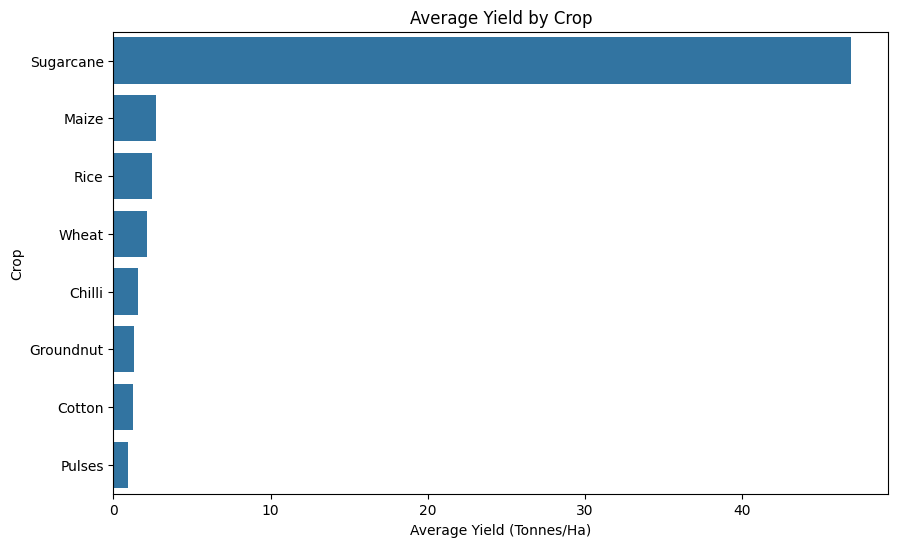

In [64]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=crop_yield.reset_index(),
    x='Average_Yield',
    y='Crop'
)

plt.title('Average Yield by Crop')
plt.xlabel('Average Yield (Tonnes/Ha)')
plt.ylabel('Crop')

plt.show()

In [65]:
crop_production = df_clean.groupby('Crop').agg(
    Total_Production=('Production_Tonnes', 'sum'),
    Average_Production=('Production_Tonnes', 'mean'),
    Number_of_Farms=('Farm_ID', 'count')
).sort_values(
    'Total_Production',
    ascending=False
).round(2)

crop_production

,Total_Production,Average_Production,Number_of_Farms
Crop,,,
Sugarcane,119685.97,392.41,305
Rice,13309.15,19.29,690
Maize,12001.40,21.78,551
Wheat,10348.30,16.85,614
Chilli,5101.75,12.38,412
Cotton,4773.10,9.40,508
Groundnut,4094.07,9.66,424
Pulses,3671.10,7.40,496


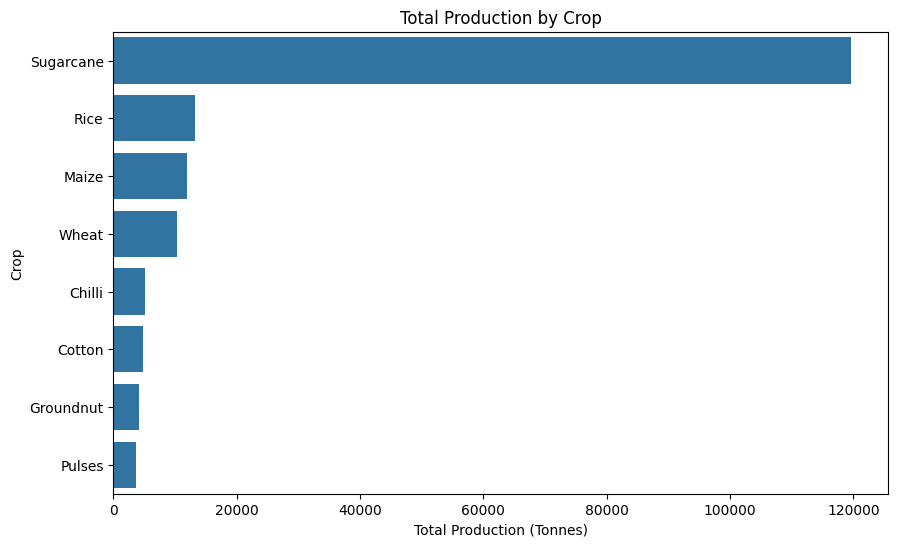

In [66]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=crop_production.reset_index(),
    x='Total_Production',
    y='Crop'
)

plt.title('Total Production by Crop')
plt.xlabel('Total Production (Tonnes)')
plt.ylabel('Crop')

plt.show()

In [67]:
crop_season_yield = yield_df.pivot_table(
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

crop_season_yield.round(2)

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.18
Cotton,1.37,1.19,0.95
Groundnut,1.48,1.22,1.04
Maize,2.97,2.61,2.30
Pulses,1.04,0.87,0.65
Rice,2.71,2.33,1.90
Sugarcane,53.46,43.94,38.42
Wheat,2.26,2.06,1.75


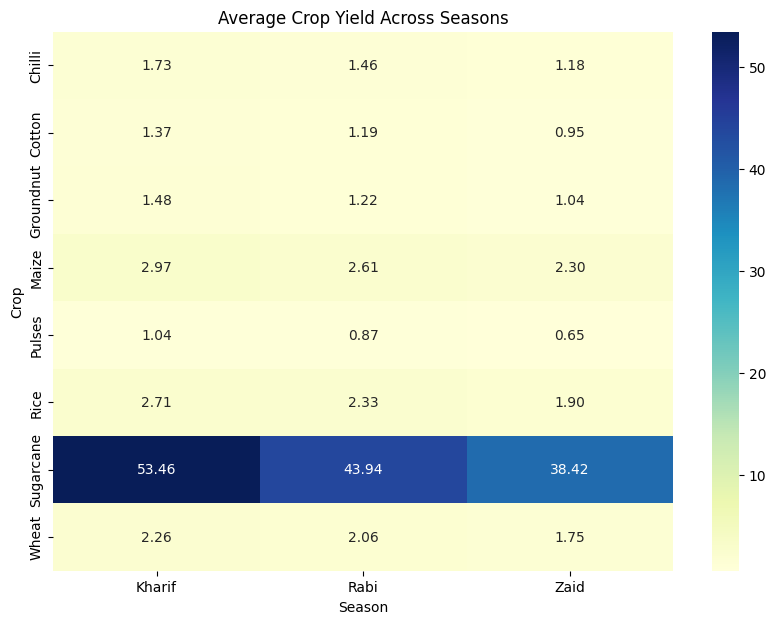

In [68]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Average Crop Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('Crop')

plt.show()

In [69]:
best_crop_each_season = (
    crop_season_yield
    .idxmax(axis=0)
)

best_yield_each_season = (
    crop_season_yield
    .max(axis=0)
)

best_crop_summary = pd.DataFrame({
    'Best_Crop': best_crop_each_season,
    'Average_Yield': best_yield_each_season
}).round(2)

best_crop_summary

,Best_Crop,Average_Yield
Season,,
Kharif,Sugarcane,53.46
Rabi,Sugarcane,43.94
Zaid,Sugarcane,38.42


In [70]:
lowest_crop_each_season = (
    crop_season_yield
    .idxmin(axis=0)
)

lowest_yield_each_season = (
    crop_season_yield
    .min(axis=0)
)

lowest_crop_summary = pd.DataFrame({
    'Lowest_Performing_Crop': lowest_crop_each_season,
    'Average_Yield': lowest_yield_each_season
}).round(2)

lowest_crop_summary

,Lowest_Performing_Crop,Average_Yield
Season,,
Kharif,Pulses,1.04
Rabi,Pulses,0.87
Zaid,Pulses,0.65


In [71]:
crop_season_production = df_clean.pivot_table(
    values='Production_Tonnes',
    index='Crop',
    columns='Season',
    aggfunc='sum'
)

crop_season_production.round(2)

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,2675.74,1787.45,638.56
Cotton,2237.84,1897.64,637.62
Groundnut,2024.62,1603.90,465.55
Maize,5463.54,5030.78,1507.08
Pulses,1831.36,1533.28,306.46
Rice,7049.19,4719.24,1540.72
Sugarcane,55759.37,47118.96,16807.64
Wheat,5345.95,3807.63,1194.72


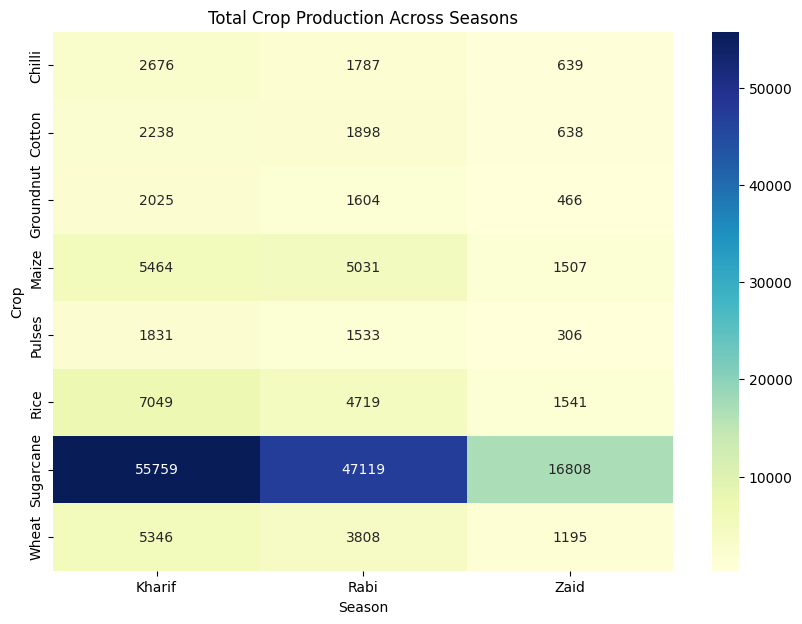

In [72]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    crop_season_production,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu'
)

plt.title('Total Crop Production Across Seasons')
plt.xlabel('Season')
plt.ylabel('Crop')

plt.show()

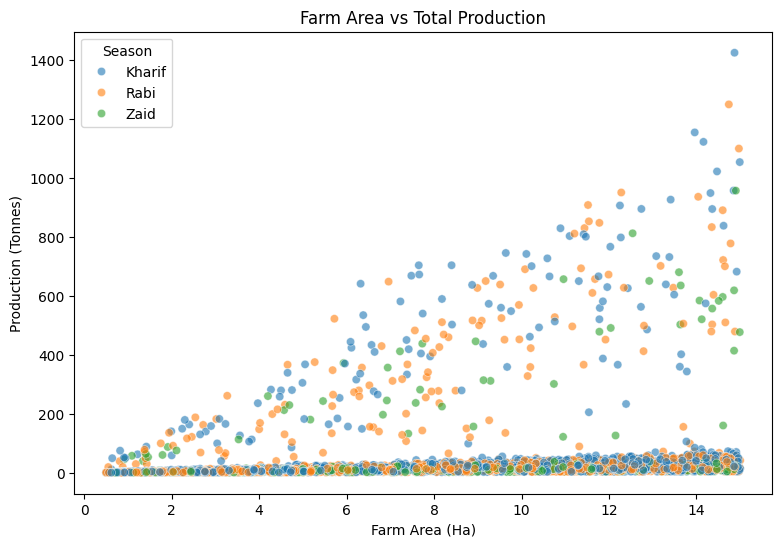

In [73]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_clean,
    x='Farm_Area_Hectares',
    y='Production_Tonnes',
    hue='Season',
    alpha=0.6
)

plt.title('Farm Area vs Total Production')
plt.xlabel('Farm Area (Ha)')
plt.ylabel('Production (Tonnes)')

plt.show()

In [74]:
area_production_corr = df_clean[
    ['Farm_Area_Hectares', 'Production_Tonnes']
].corr()

area_production_corr

,Farm_Area_Hectares,Production_Tonnes
Farm_Area_Hectares,1.00,0.20
Production_Tonnes,0.20,1.00


### Interpretation

Farm area is expected to have an important relationship with total
production because larger cultivated areas can produce greater total
output.

However, production should not be interpreted as productivity.

Yield is a more appropriate measure for comparing agricultural
productivity between farms of different sizes.

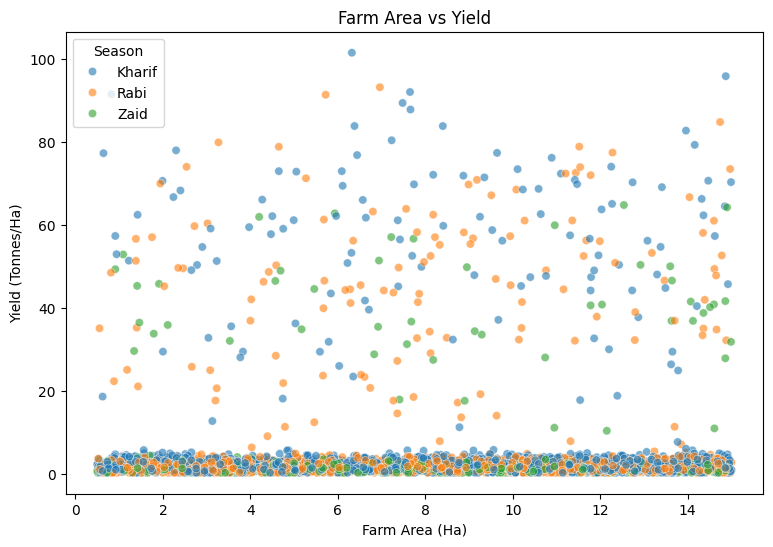

In [75]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=yield_df,
    x='Farm_Area_Hectares',
    y='Yield_Tonnes_Ha',
    hue='Season',
    alpha=0.6
)

plt.title('Farm Area vs Yield')
plt.xlabel('Farm Area (Ha)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

In [76]:
yield_df = df_clean.dropna(
    subset=['Yield_Tonnes_Ha']
).copy()

area_yield_corr = yield_df[
    ['Farm_Area_Hectares', 'Yield_Tonnes_Ha']
].corr()

area_yield_corr

,Farm_Area_Hectares,Yield_Tonnes_Ha
Farm_Area_Hectares,1.00,0.03
Yield_Tonnes_Ha,0.03,1.00


In [77]:
state_production = df_clean.groupby('State').agg(
    Total_Production=('Production_Tonnes', 'sum'),
    Average_Production=('Production_Tonnes', 'mean'),
    Average_Farm_Area=('Farm_Area_Hectares', 'mean')
).sort_values(
    'Total_Production',
    ascending=False
).round(2)

state_production

,Total_Production,Average_Production,Average_Farm_Area
State,,,
Punjab,25280.82,52.23,8.23
Gujarat,23586.01,48.33,7.99
Karnataka,23341.30,47.73,8.00
Maharashtra,22519.83,43.98,7.71
Telangana,20255.16,39.25,7.81
Tamil Nadu,19807.58,40.84,7.66
Andhra Pradesh,19527.06,36.91,8.00
Madhya Pradesh,18667.08,37.56,7.71


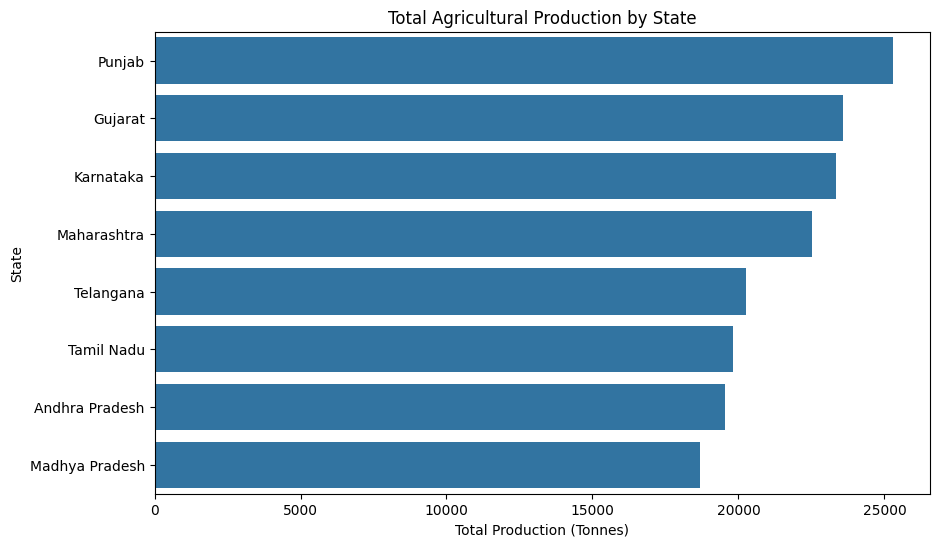

In [78]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=state_production.reset_index(),
    x='Total_Production',
    y='State'
)

plt.title('Total Agricultural Production by State')
plt.xlabel('Total Production (Tonnes)')
plt.ylabel('State')

plt.show()

In [79]:
# Calculate IQR for yield

Q1 = yield_df['Yield_Tonnes_Ha'].quantile(0.25)
Q3 = yield_df['Yield_Tonnes_Ha'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 1.05
Q3: 2.84
IQR: 1.7899999999999998
Lower Bound: -1.6349999999999996
Upper Bound: 5.5249999999999995


In [80]:
yield_outliers = yield_df[
    (yield_df['Yield_Tonnes_Ha'] < lower_bound) |
    (yield_df['Yield_Tonnes_Ha'] > upper_bound)
]

print("Number of yield outliers:", len(yield_outliers))

yield_outliers[
    [
        'Farm_ID',
        'State',
        'Crop',
        'Season',
        'Farm_Area_Hectares',
        'Yield_Tonnes_Ha',
        'Production_Tonnes'
    ]
].head(20)

Number of yield outliers: 302


,Farm_ID,State,Crop,Season,Farm_Area_Hectares,Yield_Tonnes_Ha,Production_Tonnes
47,SF10048,Punjab,Sugarcane,Zaid,7.68,36.69,281.78
75,SF10076,Maharashtra,Sugarcane,Kharif,10.64,62.58,665.85
79,SF10080,Karnataka,Sugarcane,Zaid,9.29,33.55,311.68
82,SF10083,Andhra Pradesh,Sugarcane,Rabi,2.46,49.52,121.82
92,SF10093,Gujarat,Sugarcane,Kharif,12.74,70.23,894.73
113,SF10114,Tamil Nadu,Sugarcane,Rabi,14.35,58.06,833.16
132,SF10133,Telangana,Sugarcane,Kharif,3.83,29.47,112.87
154,SF10155,Telangana,Sugarcane,Kharif,9.12,47.88,436.67
155,SF10156,Madhya Pradesh,Sugarcane,Kharif,4.50,62.09,279.41
164,SF10165,Telangana,Sugarcane,Rabi,4.00,36.91,147.64


In [81]:
crop_yield_variability = yield_df.groupby('Crop').agg(
    Mean_Yield=('Yield_Tonnes_Ha', 'mean'),
    Median_Yield=('Yield_Tonnes_Ha', 'median'),
    Std_Deviation=('Yield_Tonnes_Ha', 'std'),
    Min_Yield=('Yield_Tonnes_Ha', 'min'),
    Max_Yield=('Yield_Tonnes_Ha', 'max')
).sort_values(
    'Std_Deviation',
    ascending=False
).round(2)

crop_yield_variability

,Mean_Yield,Median_Yield,Std_Deviation,Min_Yield,Max_Yield
Crop,,,,,
Sugarcane,46.94,48.03,21.09,1.39,101.44
Maize,2.72,2.85,1.24,0.30,6.08
Rice,2.44,2.46,1.15,0.30,5.70
Wheat,2.11,2.22,0.91,0.30,4.56
Chilli,1.54,1.56,0.79,0.30,3.90
Groundnut,1.32,1.40,0.61,0.30,3.02
Cotton,1.23,1.24,0.53,0.30,2.90
Pulses,0.92,0.94,0.42,0.30,2.09


In [82]:
season_yield_variability = yield_df.groupby('Season').agg(
    Mean_Yield=('Yield_Tonnes_Ha', 'mean'),
    Median_Yield=('Yield_Tonnes_Ha', 'median'),
    Std_Deviation=('Yield_Tonnes_Ha', 'std'),
    Min_Yield=('Yield_Tonnes_Ha', 'min'),
    Max_Yield=('Yield_Tonnes_Ha', 'max')
).round(2)

season_yield_variability

,Mean_Yield,Median_Yield,Std_Deviation,Min_Yield,Max_Yield
Season,,,,,
Kharif,5.64,1.95,14.42,0.30,101.44
Rabi,5.08,1.66,12.83,0.30,93.13
Zaid,4.67,1.45,11.32,0.30,64.76


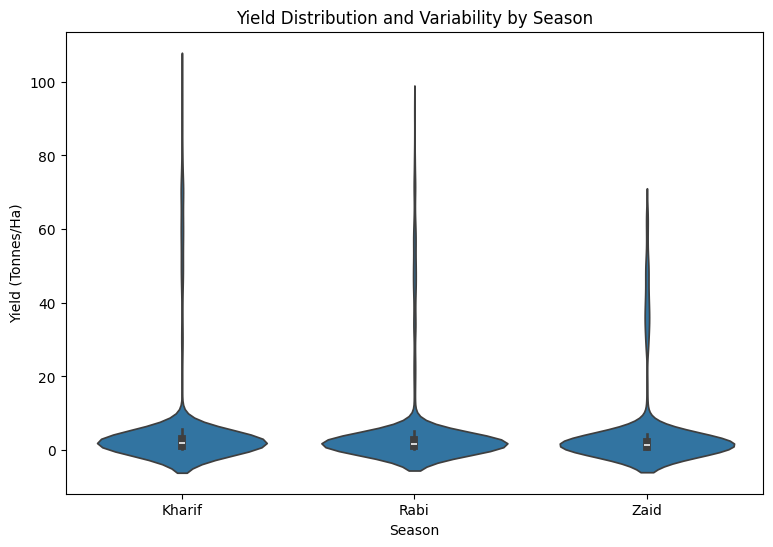

In [83]:
plt.figure(figsize=(9, 6))

sns.violinplot(
    data=yield_df,
    x='Season',
    y='Yield_Tonnes_Ha'
)

plt.title('Yield Distribution and Variability by Season')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

In [84]:
# Calculate production per hectare

df_clean['Calculated_Production_per_Ha'] = (
    df_clean['Production_Tonnes'] /
    df_clean['Farm_Area_Hectares']
)

df_clean[
    [
        'Yield_Tonnes_Ha',
        'Calculated_Production_per_Ha'
    ]
].describe()

,Yield_Tonnes_Ha,Calculated_Production_per_Ha
count,3968.00,4000.00
mean,5.27,5.26
std,13.36,13.34
min,0.30,0.29
25%,1.05,1.05
50%,1.74,1.73
75%,2.84,2.84
max,101.44,101.44


In [85]:
production_yield_comparison = df_clean[
    ['Yield_Tonnes_Ha', 'Calculated_Production_per_Ha']
].corr()

production_yield_comparison

,Yield_Tonnes_Ha,Calculated_Production_per_Ha
Yield_Tonnes_Ha,1.00,1.00
Calculated_Production_per_Ha,1.00,1.00


In [86]:
top_farms = yield_df.sort_values(
    'Yield_Tonnes_Ha',
    ascending=False
).head(10)

top_farms[
    [
        'Farm_ID',
        'State',
        'District',
        'Crop',
        'Season',
        'Farm_Area_Hectares',
        'Yield_Tonnes_Ha',
        'Production_Tonnes',
        'Profit_INR'
    ]
]

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR
1715,SF11716,Gujarat,Indore,Sugarcane,Kharif,6.32,101.44,641.10,1608291
3423,SF13424,Andhra Pradesh,Indore,Sugarcane,Kharif,14.87,95.79,1424.40,3330582
3525,SF13526,Andhra Pradesh,Erode,Sugarcane,Rabi,6.96,93.13,648.18,1471529
1464,SF11465,Gujarat,Nashik,Sugarcane,Kharif,7.65,91.98,703.65,2216708
3523,SF13524,Karnataka,Nashik,Sugarcane,Kharif,0.82,91.46,75.00,234320
2782,SF12783,Gujarat,Nalgonda,Sugarcane,Rabi,5.72,91.32,522.35,1236801
644,SF10645,Andhra Pradesh,Ludhiana,Sugarcane,Kharif,7.48,89.34,668.26,1984818
2847,SF12848,Telangana,Warangal,Sugarcane,Kharif,7.66,87.76,672.24,2041678
357,SF10358,Punjab,Warangal,Sugarcane,Rabi,14.74,84.75,1249.21,3378879
1178,SF11179,Karnataka,Nalgonda,Sugarcane,Kharif,6.38,83.79,534.58,1200815


## 12.22 Key Findings from Production and Yield Analysis

The production and yield analysis provides a detailed view of agricultural
output across seasons, crops and geographical regions.

### Seasonal Performance

Yield and production vary across Kharif, Rabi and Zaid. Kharif showed the
highest average yield and total production in the initial seasonal analysis,
while Zaid showed comparatively lower performance.

### Crop Performance

Crop-level analysis reveals that agricultural productivity is not uniform
across crops. Some crops demonstrate higher average yield, while others
contribute greater total production.

### Crop–Season Interaction

The Crop × Season analysis provides more detailed insights than overall
seasonal averages. Different crops can perform differently depending on the
season, making crop-specific seasonal analysis important for agricultural
planning.

### Farm Area and Production

Farm area is expected to have a stronger relationship with total production
than with yield. Production measures total output, whereas yield measures
productivity per unit area.

### Geographical Differences

State-level analysis shows differences in agricultural production and
average yield. These differences may be influenced by crop composition,
environmental conditions, resource availability and farming practices.

### Yield Variability

Yield distributions contain variation and potential outliers. These
observations should be investigated rather than automatically removed,
because extreme values may represent genuine high-performing or
low-performing agricultural conditions.

### Overall Observation

Agricultural performance is influenced by multiple interacting factors.
Season alone cannot fully explain differences in yield and production.
Crop type, farm size, environmental conditions, resource usage and
geographical characteristics must therefore be considered together.

## 13. Economic Performance Analysis

Agricultural performance cannot be evaluated only through crop yield and
production. Economic outcomes are equally important because farmers need
to consider production costs, market prices, revenue and profitability.

This section analyzes the economic performance of agricultural activities
across seasons, crops and geographical regions.

The main financial indicators considered are:

- Total Cost
- Revenue
- Profit
- Profit Margin
- Market Price
- Yield
- Production

The objective is to identify which seasons, crops and regions demonstrate
better economic performance and to investigate whether higher agricultural
productivity is associated with higher profitability.

In [87]:
# Summary statistics for economic variables

economic_columns = [
    'Market_Price_INR_Tonne',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR'
]

df_clean[economic_columns].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Market_Price_INR_Tonne,4000.00,44714.17,30266.16,2594.00,21429.25,25913.00,68279.00,131240.00
Total_Cost_INR,4000.00,526303.58,294419.14,26826.00,274577.50,519082.50,761996.50,1349990.00
Revenue_INR,4000.00,637860.05,636974.71,6107.00,207517.25,456830.50,836874.75,5080900.00
Profit_INR,4000.00,111556.46,545081.89,-1019223.00,-148731.75,3673.00,216187.75,4345421.00


In [88]:
# Calculate profit margin

df_clean['Profit_Margin_pct'] = (
    df_clean['Profit_INR'] /
    df_clean['Revenue_INR']
) * 100

df_clean['Profit_Margin_pct'].describe().round(2)

count    4000.00
mean      -45.49
std       158.09
min     -1461.85
25%       -60.19
50%         1.15
75%        32.89
max        85.92
Name: Profit_Margin_pct, dtype: float64

In [89]:
# Check zero or negative revenue values

print(
    "Zero revenue records:",
    (df_clean['Revenue_INR'] == 0).sum()
)

print(
    "Negative revenue records:",
    (df_clean['Revenue_INR'] < 0).sum()
)

Zero revenue records: 0
Negative revenue records: 0


In [90]:
seasonal_economic = df_clean.groupby('Season').agg(
    Average_Market_Price=('Market_Price_INR_Tonne', 'mean'),
    Average_Cost=('Total_Cost_INR', 'mean'),
    Average_Revenue=('Revenue_INR', 'mean'),
    Average_Profit=('Profit_INR', 'mean'),
    Average_Profit_Margin=('Profit_Margin_pct', 'mean'),
    Total_Revenue=('Revenue_INR', 'sum'),
    Total_Profit=('Profit_INR', 'sum')
).round(2)

seasonal_economic

,Average_Market_Price,Average_Cost,Average_Revenue,Average_Profit,Average_Profit_Margin,Total_Revenue,Total_Profit
Season,,,,,,,
Kharif,44850.91,531804.41,710719.06,178914.65,-38.64,1264369200,318289158
Rabi,44747.97,513836.58,601526.05,87689.47,-44.27,978682881,142670768
Zaid,44212.03,543976.73,519171.90,-24804.82,-69.35,308388111,-14734066


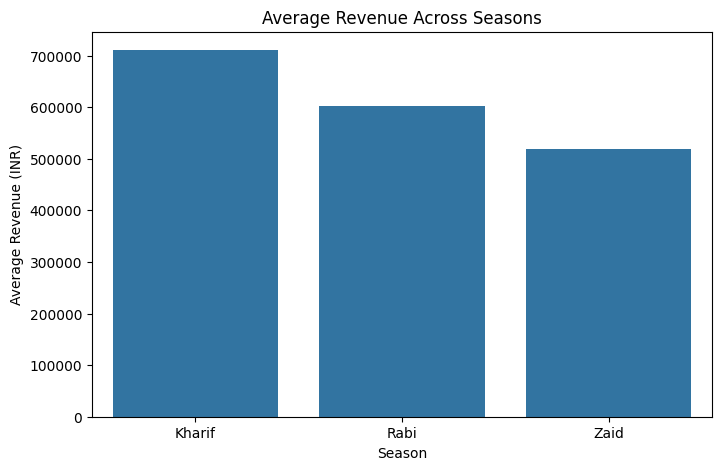

In [91]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x='Season',
    y='Revenue_INR',
    estimator='mean',
    errorbar=None
)

plt.title('Average Revenue Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Revenue (INR)')

plt.show()

### Interpretation

Average revenue is compared across seasons to determine whether the
economic value generated by agricultural activities differs between
Kharif, Rabi and Zaid.

Revenue depends on both production and market price. Therefore, a season
with higher production does not necessarily have the highest revenue if
its market prices are lower.

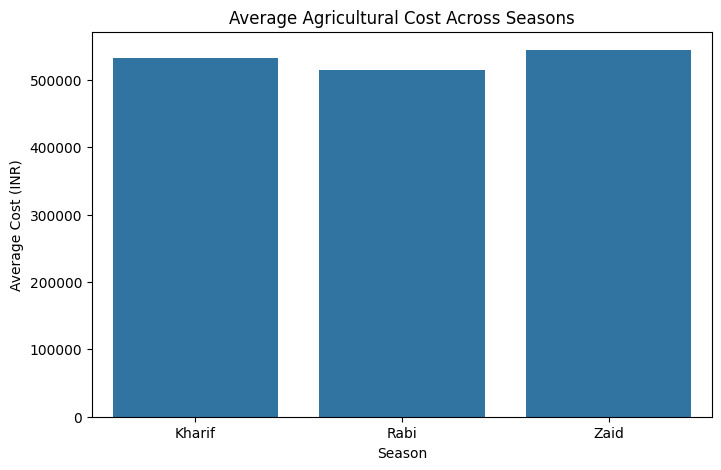

In [92]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x='Season',
    y='Total_Cost_INR',
    estimator='mean',
    errorbar=None
)

plt.title('Average Agricultural Cost Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Cost (INR)')

plt.show()

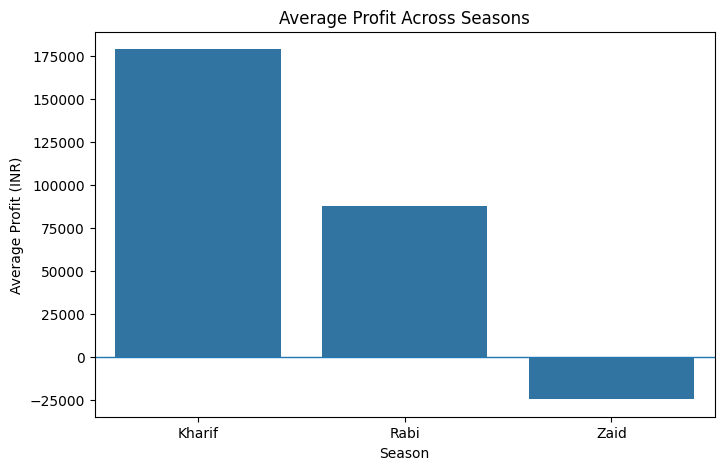

In [93]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x='Season',
    y='Profit_INR',
    estimator='mean',
    errorbar=None
)

plt.axhline(0, linewidth=1)

plt.title('Average Profit Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')

plt.show()

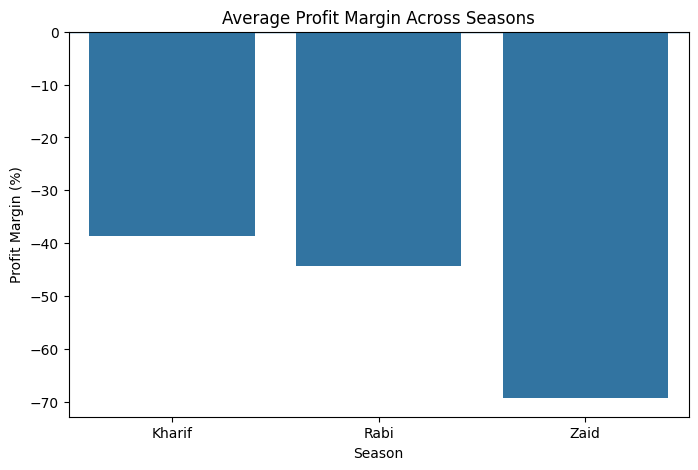

In [94]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x='Season',
    y='Profit_Margin_pct',
    estimator='mean',
    errorbar=None
)

plt.axhline(0, linewidth=1)

plt.title('Average Profit Margin Across Seasons')
plt.xlabel('Season')
plt.ylabel('Profit Margin (%)')

plt.show()

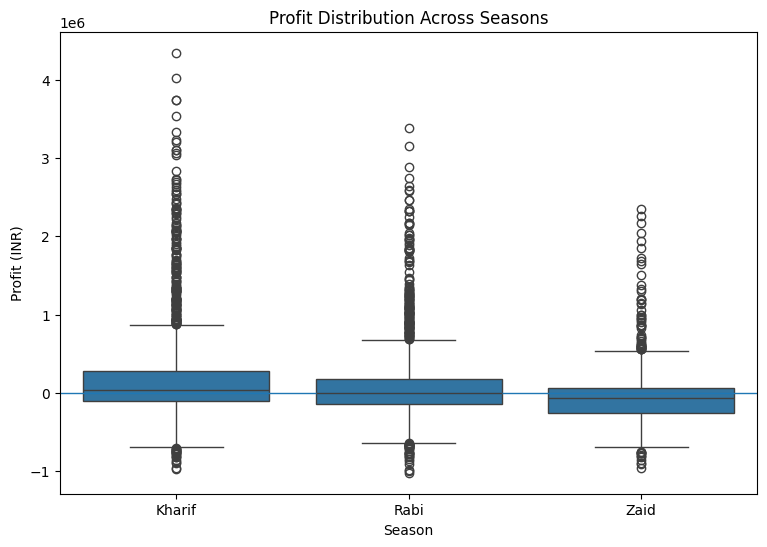

In [95]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_clean,
    x='Season',
    y='Profit_INR'
)

plt.axhline(0, linewidth=1)

plt.title('Profit Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Profit (INR)')

plt.show()

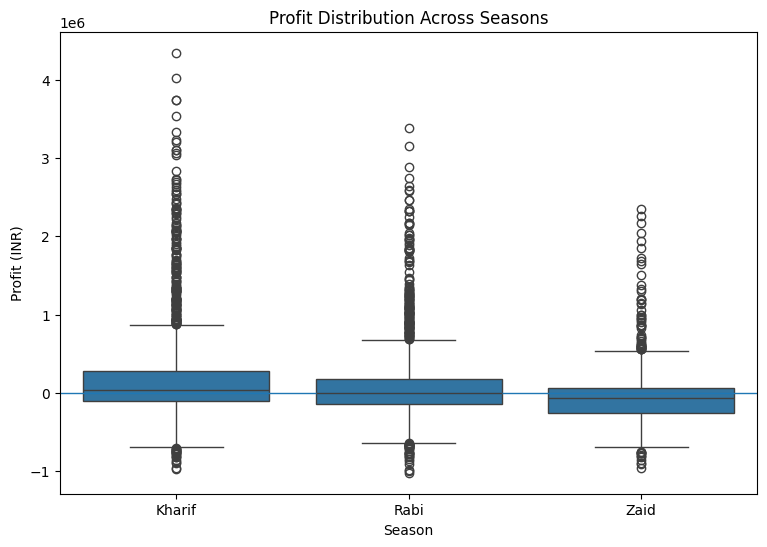

In [96]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_clean,
    x='Season',
    y='Profit_INR'
)

plt.axhline(0, linewidth=1)

plt.title('Profit Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Profit (INR)')

plt.show()

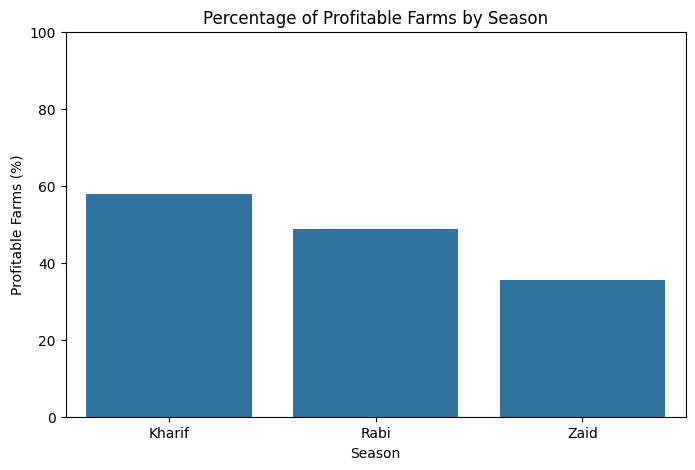

In [97]:
total_farms_per_season = df_clean.groupby('Season').size()
profitable_farms_count = df_clean[df_clean['Profit_INR'] > 0].groupby('Season').size()

profitable_farms = (profitable_farms_count / total_farms_per_season * 100).fillna(0)
profitable_farms = profitable_farms.reindex(df_clean['Season'].unique(), fill_value=0).sort_values(ascending=False)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=profitable_farms.index,
    y=profitable_farms.values
)

plt.title('Percentage of Profitable Farms by Season')
plt.xlabel('Season')
plt.ylabel('Profitable Farms (%)')

plt.ylim(0, 100)

plt.show()

In [98]:
crop_economic = df_clean.groupby('Crop').agg(
    Average_Cost=('Total_Cost_INR', 'mean'),
    Average_Revenue=('Revenue_INR', 'mean'),
    Average_Profit=('Profit_INR', 'mean'),
    Average_Profit_Margin=('Profit_Margin_pct', 'mean'),
    Average_Yield=('Yield_Tonnes_Ha', 'mean')
).sort_values(
    'Average_Profit',
    ascending=False
).round(2)

crop_economic

,Average_Cost,Average_Revenue,Average_Profit,Average_Profit_Margin,Average_Yield
Crop,,,,,
Sugarcane,554792.13,1371980.11,817187.99,27.35,46.94
Chilli,525898.89,1276777.23,750878.34,33.78,1.54
Cotton,514876.17,639423.08,124546.92,-8.23,1.23
Groundnut,498077.38,542935.50,44858.12,-28.66,1.32
Pulses,532703.92,528465.87,-4238.05,-36.48,0.92
Maize,541046.32,457067.99,-83978.33,-81.54,2.72
Rice,525828.76,423615.26,-102213.50,-99.37,2.44
Wheat,523503.22,400104.89,-123398.34,-91.70,2.11


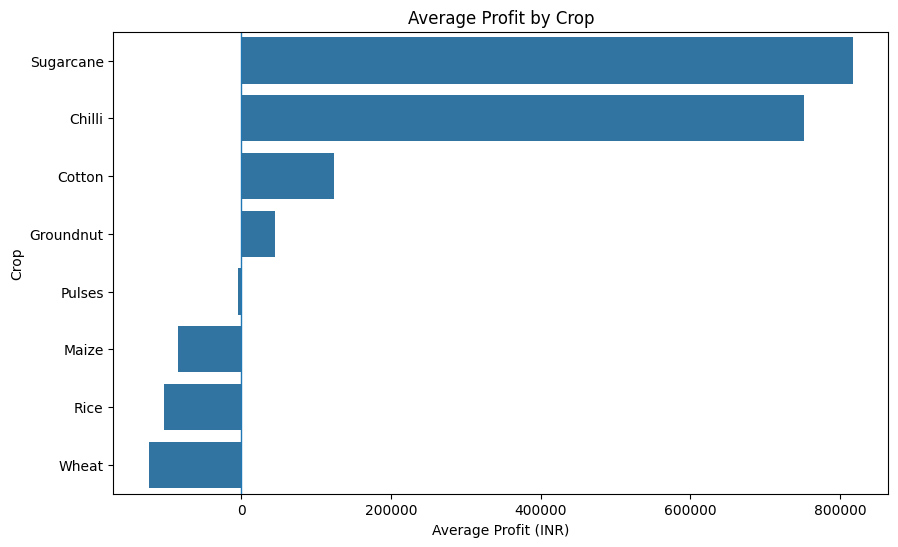

In [99]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=crop_economic.reset_index(),
    x='Average_Profit',
    y='Crop'
)

plt.axvline(0, linewidth=1)

plt.title('Average Profit by Crop')
plt.xlabel('Average Profit (INR)')
plt.ylabel('Crop')

plt.show()

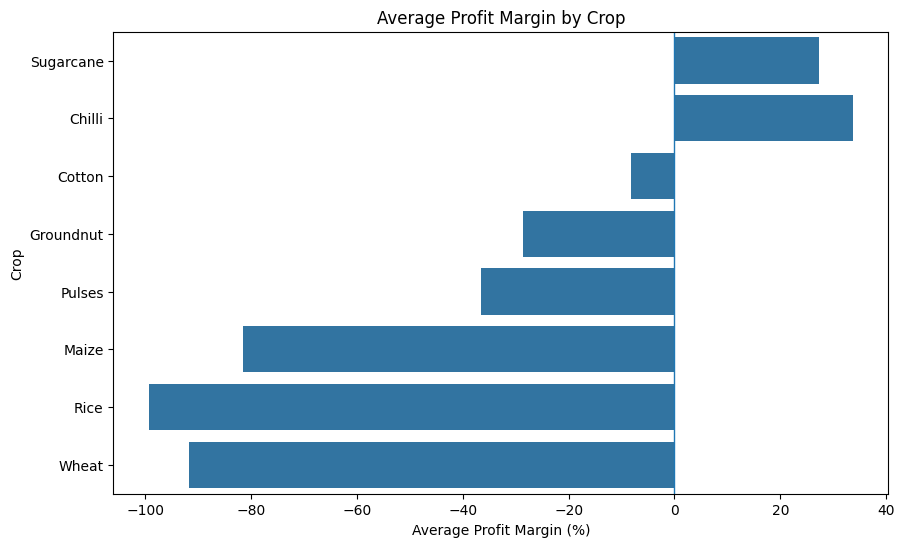

In [100]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=crop_economic.reset_index(),
    x='Average_Profit_Margin',
    y='Crop'
)

plt.axvline(0, linewidth=1)

plt.title('Average Profit Margin by Crop')
plt.xlabel('Average Profit Margin (%)')
plt.ylabel('Crop')

plt.show()

In [101]:
crop_season_profit = df_clean.pivot_table(
    values='Profit_INR',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

crop_season_profit.round(2)

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,954380.42,638572.50,448659.09
Cotton,216999.55,107343.59,-53925.34
Groundnut,108265.44,10416.54,-68872.50
Maize,-39332.67,-89133.40,-194049.17
Pulses,43338.90,-14309.14,-139227.81
Rice,-64903.40,-98427.87,-227239.34
Sugarcane,1000790.81,731612.86,583635.80
Wheat,-105871.87,-119954.57,-193208.95


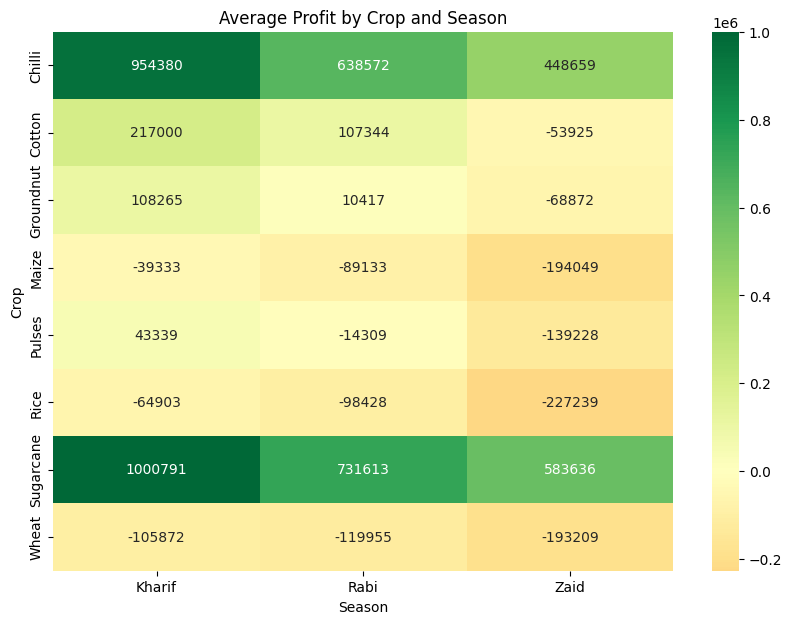

In [102]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    crop_season_profit,
    annot=True,
    fmt='.0f',
    cmap='RdYlGn',
    center=0
)

plt.title('Average Profit by Crop and Season')
plt.xlabel('Season')
plt.ylabel('Crop')

plt.show()

In [103]:
best_crop_profit = crop_season_profit.idxmax(axis=0)

best_profit_value = crop_season_profit.max(axis=0)

best_profit_summary = pd.DataFrame({
    'Most_Profitable_Crop': best_crop_profit,
    'Average_Profit_INR': best_profit_value
}).round(2)

best_profit_summary

,Most_Profitable_Crop,Average_Profit_INR
Season,,
Kharif,Sugarcane,1000790.81
Rabi,Sugarcane,731612.86
Zaid,Sugarcane,583635.80


In [104]:
worst_crop_profit = crop_season_profit.idxmin(axis=0)

worst_profit_value = crop_season_profit.min(axis=0)

worst_profit_summary = pd.DataFrame({
    'Least_Profitable_Crop': worst_crop_profit,
    'Average_Profit_INR': worst_profit_value
}).round(2)

worst_profit_summary

,Least_Profitable_Crop,Average_Profit_INR
Season,,
Kharif,Wheat,-105871.87
Rabi,Wheat,-119954.57
Zaid,Rice,-227239.34


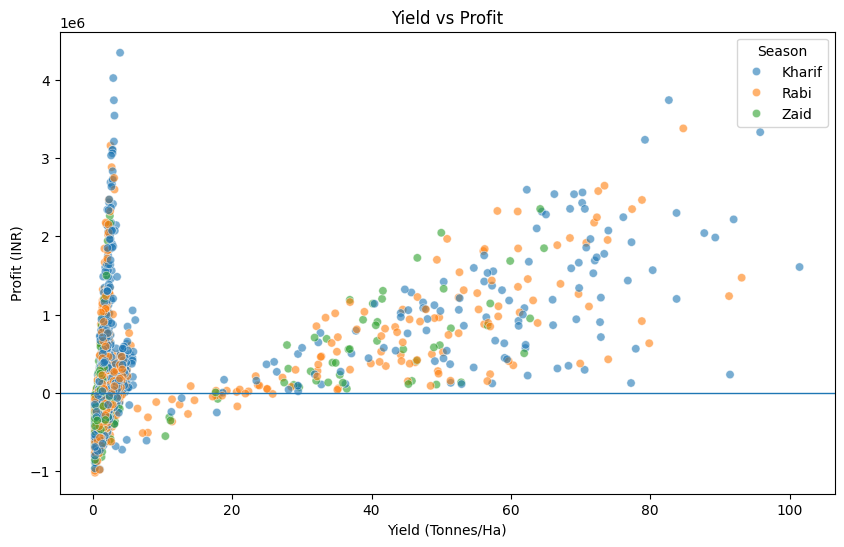

In [105]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x='Yield_Tonnes_Ha',
    y='Profit_INR',
    hue='Season',
    alpha=0.6
)

plt.axhline(0, linewidth=1)

plt.title('Yield vs Profit')
plt.xlabel('Yield (Tonnes/Ha)')
plt.ylabel('Profit (INR)')

plt.show()

In [106]:
yield_profit_corr = df_clean[
    ['Yield_Tonnes_Ha', 'Profit_INR']
].corr()

yield_profit_corr.round(3)

,Yield_Tonnes_Ha,Profit_INR
Yield_Tonnes_Ha,1.00,0.49
Profit_INR,0.49,1.00


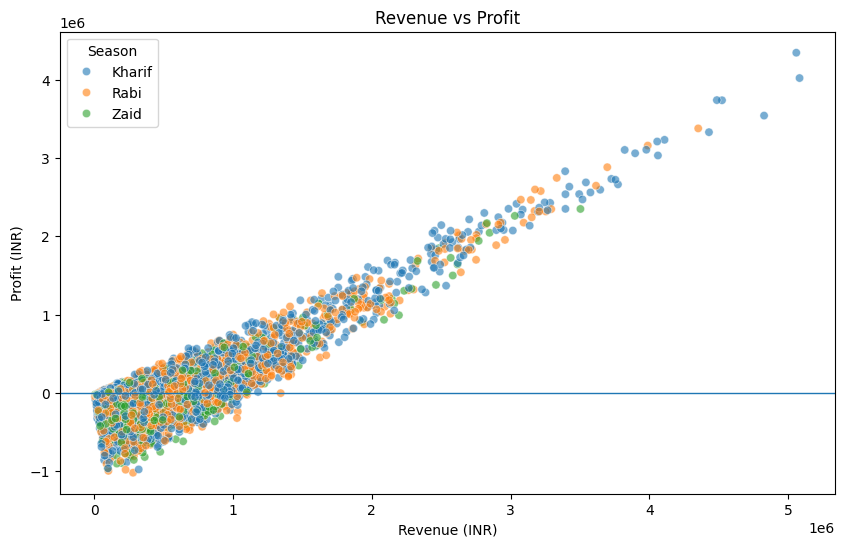

In [107]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x='Revenue_INR',
    y='Profit_INR',
    hue='Season',
    alpha=0.6
)

plt.axhline(0, linewidth=1)

plt.title('Revenue vs Profit')
plt.xlabel('Revenue (INR)')
plt.ylabel('Profit (INR)')

plt.show()

In [108]:
df_clean[
    ['Revenue_INR', 'Total_Cost_INR', 'Profit_INR']
].corr().round(3)

,Revenue_INR,Total_Cost_INR,Profit_INR
Revenue_INR,1.00,0.52,0.89
Total_Cost_INR,0.52,1.00,0.07
Profit_INR,0.89,0.07,1.00


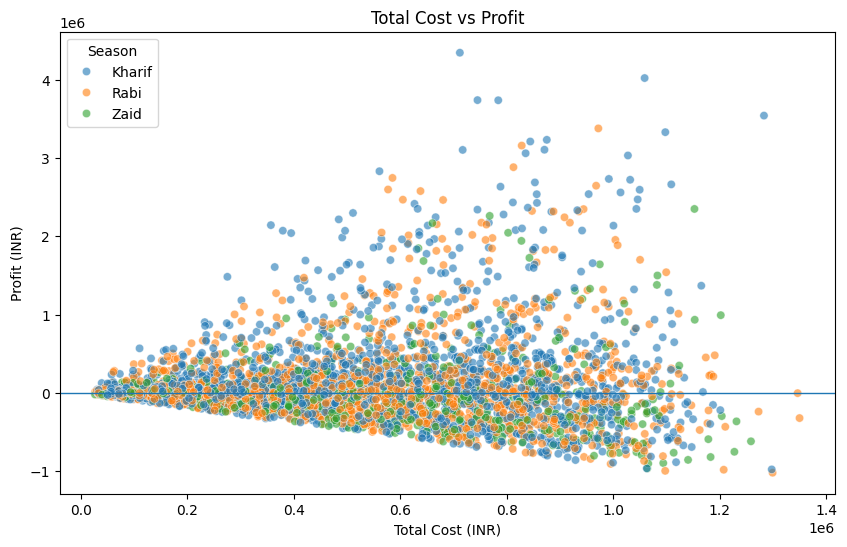

In [109]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x='Total_Cost_INR',
    y='Profit_INR',
    hue='Season',
    alpha=0.6
)

plt.axhline(0, linewidth=1)

plt.title('Total Cost vs Profit')
plt.xlabel('Total Cost (INR)')
plt.ylabel('Profit (INR)')

plt.show()

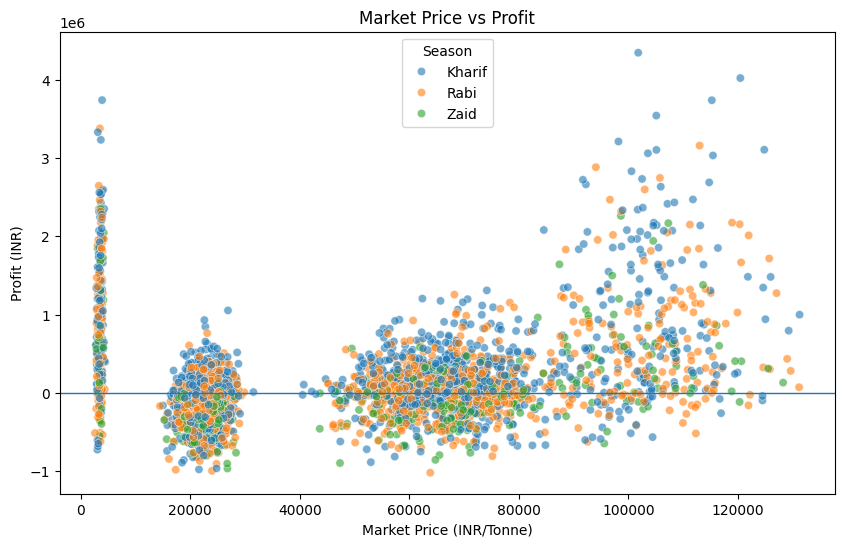

In [110]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_clean,
    x='Market_Price_INR_Tonne',
    y='Profit_INR',
    hue='Season',
    alpha=0.6
)

plt.axhline(0, linewidth=1)

plt.title('Market Price vs Profit')
plt.xlabel('Market Price (INR/Tonne)')
plt.ylabel('Profit (INR)')

plt.show()

In [111]:
state_economic = df_clean.groupby('State').agg(
    Average_Cost=('Total_Cost_INR', 'mean'),
    Average_Revenue=('Revenue_INR', 'mean'),
    Average_Profit=('Profit_INR', 'mean'),
    Average_Profit_Margin=('Profit_Margin_pct', 'mean'),
    Total_Profit=('Profit_INR', 'sum')
).sort_values(
    'Average_Profit',
    ascending=False
).round(2)

state_economic

,Average_Cost,Average_Revenue,Average_Profit,Average_Profit_Margin,Total_Profit
State,,,,,
Punjab,550200.07,686225.70,136025.64,-45.12,65836408
Maharashtra,514603.81,650032.67,135428.86,-44.49,69339574
Karnataka,534003.85,653426.18,119422.34,-46.31,58397522
Tamil Nadu,511348.67,629093.42,117744.75,-45.49,57106203
Gujarat,537124.62,654692.86,117568.24,-54.00,57373299
Telangana,519954.92,628784.53,108829.62,-29.13,56156082
Madhya Pradesh,510717.60,597558.36,86840.76,-44.93,43159856
Andhra Pradesh,533210.13,606663.66,73453.53,-54.69,38856916


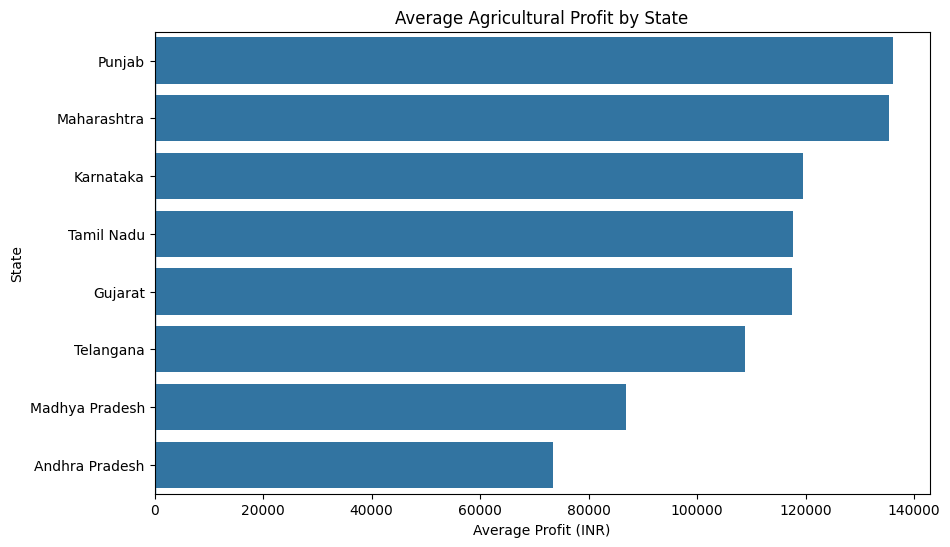

In [112]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=state_economic.reset_index(),
    x='Average_Profit',
    y='State'
)

plt.axvline(0, linewidth=1)

plt.title('Average Agricultural Profit by State')
plt.xlabel('Average Profit (INR)')
plt.ylabel('State')

plt.show()

In [113]:
# Calculate profit margin and seasonal_economic if not already defined (to handle potential kernel state issues)
df_clean['Profit_Margin_pct'] = (df_clean['Profit_INR'] / df_clean['Revenue_INR']) * 100
seasonal_economic = df_clean.groupby('Season').agg(
    Average_Market_Price=('Market_Price_INR_Tonne', 'mean'),
    Average_Cost=('Total_Cost_INR', 'mean'),
    Average_Revenue=('Revenue_INR', 'mean'),
    Average_Profit=('Profit_INR', 'mean'),
    Average_Profit_Margin=('Profit_Margin_pct', 'mean'),
    Total_Revenue=('Revenue_INR', 'sum'),
    Total_Profit=('Profit_INR', 'sum')
).round(2)

# Compare key economic indicators across seasons
zaid_comparison = seasonal_economic.loc[
    ['Kharif', 'Rabi', 'Zaid'],
    [
        'Average_Market_Price',
        'Average_Cost',
        'Average_Revenue',
        'Average_Profit',
        'Average_Profit_Margin'
    ]
]

zaid_comparison

,Average_Market_Price,Average_Cost,Average_Revenue,Average_Profit,Average_Profit_Margin
Season,,,,,
Kharif,44850.91,531804.41,710719.06,178914.65,-38.64
Rabi,44747.97,513836.58,601526.05,87689.47,-44.27
Zaid,44212.03,543976.73,519171.90,-24804.82,-69.35


In [114]:
# Combined seasonal performance indicators

zaid_diagnosis = df_clean.groupby('Season').agg(
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Average_Production=('Production_Tonnes', 'mean'),
    Average_Water=('Water_Used_m3', 'mean'),
    Average_Water_Efficiency=(
        'Water_Efficiency_t_per_1000m3',
        'mean'
    ),
    Average_Cost=('Total_Cost_INR', 'mean'),
    Average_Revenue=('Revenue_INR', 'mean'),
    Average_Profit=('Profit_INR', 'mean')
).round(2)

zaid_diagnosis

,Average_Yield,Average_Production,Average_Water,Average_Water_Efficiency,Average_Cost,Average_Revenue,Average_Profit
Season,,,,,,,
Kharif,5.64,46.31,6102.20,5.89,531804.41,710719.06,178914.65
Rabi,5.08,41.49,5846.99,5.19,513836.58,601526.05,87689.47
Zaid,4.67,38.89,6419.89,4.41,543976.73,519171.90,-24804.82


In [115]:
# Calculate profit margin to ensure it's available
df_clean['Profit_Margin_pct'] = (df_clean['Profit_INR'] / df_clean['Revenue_INR']) * 100

# Overall seasonal economic performance
economic_performance_summary = df_clean.groupby('Season').agg(
    Farms=('Farm_ID', 'count'),
    Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
    Avg_Production=('Production_Tonnes', 'mean'),
    Avg_Cost=('Total_Cost_INR', 'mean'),
    Avg_Revenue=('Revenue_INR', 'mean'),
    Avg_Profit=('Profit_INR', 'mean'),
    Avg_Profit_Margin=('Profit_Margin_pct', 'mean'),
    Avg_Market_Price=('Market_Price_INR_Tonne', 'mean')
).round(2)

economic_performance_summary

,Farms,Avg_Yield,Avg_Production,Avg_Cost,Avg_Revenue,Avg_Profit,Avg_Profit_Margin,Avg_Market_Price
Season,,,,,,,,
Kharif,1779,5.64,46.31,531804.41,710719.06,178914.65,-38.64,44850.91
Rabi,1627,5.08,41.49,513836.58,601526.05,87689.47,-44.27,44747.97
Zaid,594,4.67,38.89,543976.73,519171.90,-24804.82,-69.35,44212.03


## 13.24 Key Findings from Economic Performance Analysis

The economic analysis demonstrates that agricultural performance differs
substantially across seasons.

### Seasonal Profitability

Kharif shows the strongest average profitability among the three seasons,
while Rabi demonstrates moderate profitability.

Zaid shows negative average profit in the dataset, indicating that the
average revenue generated during this season does not sufficiently cover
the associated average costs.

### Revenue and Cost

Differences in profitability should be interpreted by considering both
revenue and production costs. Higher production does not automatically
guarantee higher profit.

### Profit Margin

Profit margin provides an additional measure of economic efficiency by
showing how much of the generated revenue remains as profit after costs.

### Crop-level Differences

Economic performance varies substantially across crops. A crop with high
yield is not necessarily the most profitable because profitability also
depends on market price, production volume and costs.

### Crop–Season Interaction

The Crop × Season analysis identifies combinations where agricultural
activities achieve relatively high or low profitability.

This demonstrates the importance of considering crop selection together
with seasonal conditions.

### Yield and Profit

The relationship between yield and profit is examined using scatter plots
and correlation analysis. The analysis helps determine whether higher
agricultural productivity is associated with better economic outcomes.

### Geographical Differences

State-level analysis reveals variations in agricultural profitability.
These differences may be associated with crop composition, resource usage,
environmental conditions, market prices and farming costs.

### Overall Observation

Economic performance is influenced by multiple interacting factors rather
than a single agricultural variable. Therefore, seasonal planning should
consider productivity, market conditions, resource efficiency and
production costs together.

### 14.2 Correlation Matrix

A correlation matrix is created to measure the linear relationship between numerical variables.

The Pearson correlation coefficient ranges from -1 to +1:

- +1 → Strong positive relationship
- 0 → No linear relationship
- -1 → Strong negative relationship

The correlation matrix helps identify variables that may have an important relationship with agricultural performance.

In [116]:
# Select numerical columns
numeric_cols = df_clean.select_dtypes(include=np.number).columns

# Calculate correlation matrix
corr_matrix = df_clean[numeric_cols].corr()

# Display correlation matrix
corr_matrix.round(2)

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct,Calculated_Production_per_Ha,Profit_Margin_pct
Farm_Area_Hectares,1.00,0.01,0.04,0.00,0.00,0.01,0.00,0.01,-0.01,0.00,0.01,-0.01,0.02,0.03,0.20,-0.02,0.96,0.54,0.12,0.58,0.03,0.03,0.03,-0.00
Rainfall_mm,0.01,1.00,0.20,0.52,-0.36,0.02,0.51,0.01,0.02,0.03,0.02,0.00,-0.02,0.03,0.02,0.00,0.01,0.10,0.11,0.00,0.06,0.62,0.03,0.06
Avg_Temperature_C,0.04,0.20,1.00,0.14,-0.03,0.03,0.08,0.02,0.01,0.02,0.02,0.01,-0.03,0.01,0.01,0.00,0.04,0.03,0.01,0.02,0.01,0.25,0.01,-0.01
Humidity_pct,0.00,0.52,0.14,1.00,-0.30,0.03,0.45,0.00,-0.01,-0.00,0.02,-0.00,-0.05,0.01,0.00,0.00,0.01,0.06,0.06,-0.00,0.03,0.55,0.01,0.03
Sunlight_Hours_Day,0.00,-0.36,-0.03,-0.30,1.00,-0.02,-0.30,0.01,0.00,-0.01,-0.01,-0.02,0.02,-0.02,-0.02,-0.00,-0.00,-0.05,-0.05,-0.01,-0.02,-0.25,-0.02,-0.04
Soil_pH,0.01,0.02,0.03,0.03,-0.02,1.00,0.03,0.01,0.02,-0.02,-0.01,-0.01,-0.00,-0.02,-0.01,0.02,0.01,-0.01,-0.01,-0.02,-0.01,0.03,-0.02,-0.01
Soil_Moisture_pct,0.00,0.51,0.08,0.45,-0.30,0.03,1.00,0.01,0.01,0.01,0.01,-0.02,-0.02,0.01,0.00,0.02,0.00,0.08,0.09,0.00,0.03,0.38,0.01,0.05
Nitrogen_kg_ha,0.01,0.01,0.02,0.00,0.01,0.01,0.01,1.00,0.01,0.01,-0.03,0.01,0.01,0.05,0.05,-0.02,0.01,0.08,0.09,0.02,0.05,-0.01,0.05,0.04
Phosphorus_kg_ha,-0.01,0.02,0.01,-0.01,0.00,0.02,0.01,0.01,1.00,0.00,0.01,-0.03,-0.01,0.05,0.03,-0.01,-0.02,0.03,0.05,-0.00,0.06,0.03,0.05,0.05
Potassium_kg_ha,0.00,0.03,0.02,-0.00,-0.01,-0.02,0.01,0.01,0.00,1.00,0.02,-0.00,0.01,0.00,0.00,0.01,0.00,0.03,0.03,0.00,0.01,0.01,0.01,0.01


### 14.3 Correlation Heatmap

The heatmap provides a visual representation of correlations among numerical variables.

Darker positive values indicate stronger positive relationships, while negative values indicate inverse relationships.

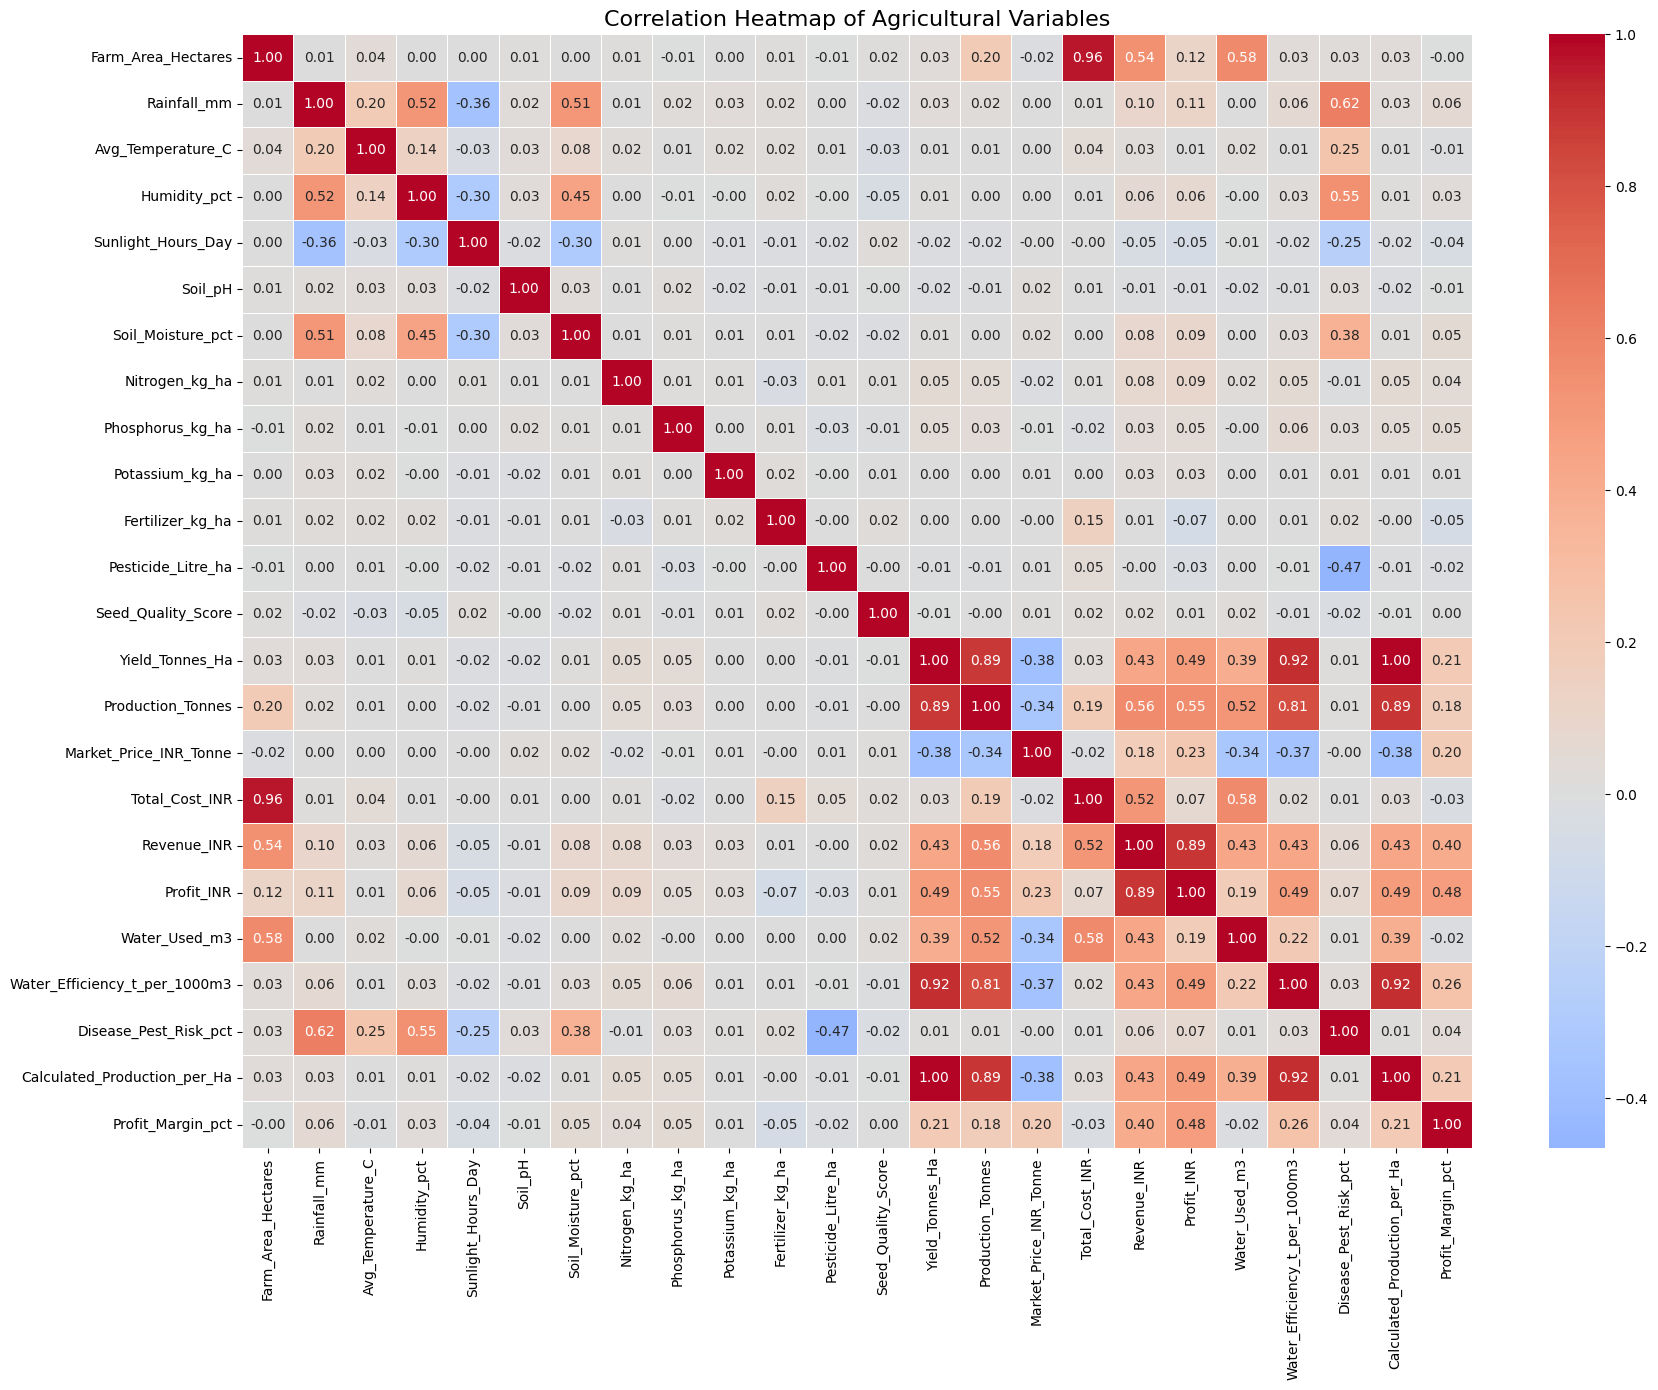

In [117]:
plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Correlation Heatmap of Agricultural Variables', fontsize=16)
plt.tight_layout()
plt.show()

### 14.4 Variables Related to Yield

Yield is one of the most important indicators of agricultural performance.

The following analysis ranks numerical variables according to their correlation with Yield_Tonnes_Ha.

In [118]:
yield_corr = (
    corr_matrix['Yield_Tonnes_Ha']
    .drop('Yield_Tonnes_Ha')
    .sort_values(ascending=False)
)

yield_corr

Calculated_Production_per_Ha     1.00
Water_Efficiency_t_per_1000m3    0.92
Production_Tonnes                0.89
Profit_INR                       0.49
Revenue_INR                      0.43
Water_Used_m3                    0.39
Profit_Margin_pct                0.21
Nitrogen_kg_ha                   0.05
Phosphorus_kg_ha                 0.05
Total_Cost_INR                   0.03
Rainfall_mm                      0.03
Farm_Area_Hectares               0.03
Disease_Pest_Risk_pct            0.01
Humidity_pct                     0.01
Soil_Moisture_pct                0.01
Avg_Temperature_C                0.01
Potassium_kg_ha                  0.00
Fertilizer_kg_ha                 0.00
Seed_Quality_Score              -0.01
Pesticide_Litre_ha              -0.01
Sunlight_Hours_Day              -0.02
Soil_pH                         -0.02
Market_Price_INR_Tonne          -0.38
Name: Yield_Tonnes_Ha, dtype: float64

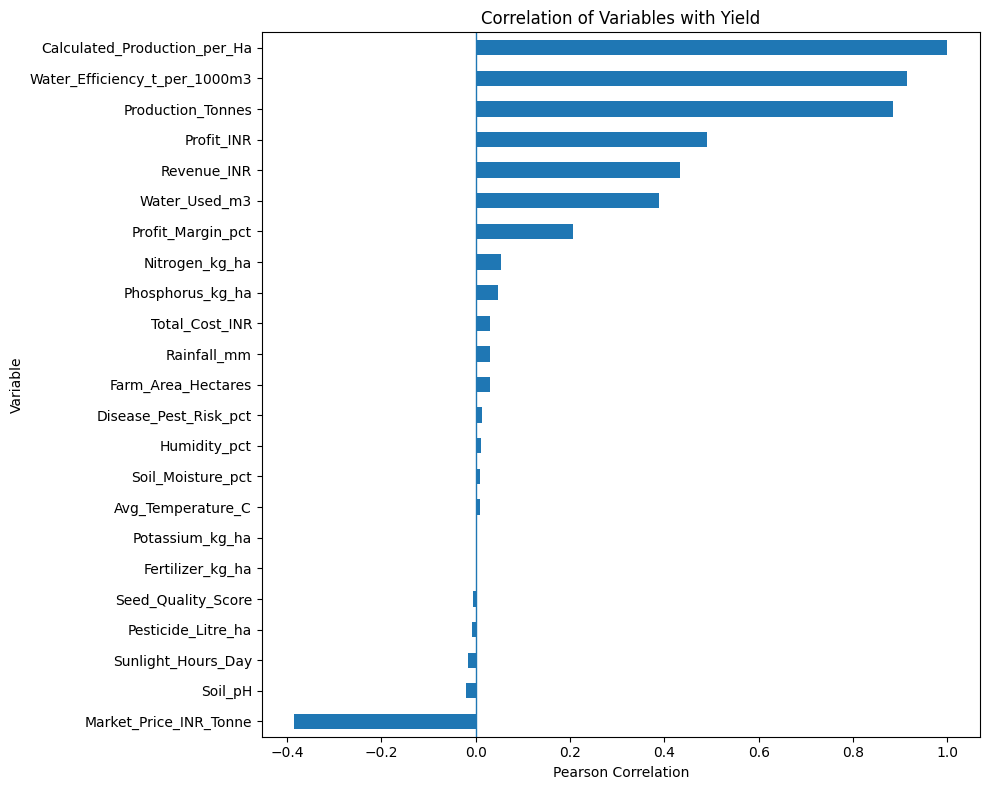

In [119]:
plt.figure(figsize=(10, 8))

yield_corr.sort_values().plot(kind='barh')

plt.title('Correlation of Variables with Yield')
plt.xlabel('Pearson Correlation')
plt.ylabel('Variable')
plt.axvline(0, linewidth=1)

plt.tight_layout()
plt.show()

### 14.5 Strongest Correlations

To identify the most important relationships, we extract the strongest positive and negative correlations from the correlation matrix.

In [120]:
# Remove self-correlations
corr_pairs = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

corr_pairs = corr_pairs.stack().reset_index()
corr_pairs.columns = ['Variable_1', 'Variable_2', 'Correlation']

# Strongest positive correlations
strongest_positive = corr_pairs.sort_values(
    'Correlation', ascending=False
).head(10)

print("Top Positive Correlations:")
display(strongest_positive)

Top Positive Correlations:


,Variable_1,Variable_2,Correlation
229,Yield_Tonnes_Ha,Calculated_Production_per_Ha,1.00
15,Farm_Area_Hectares,Total_Cost_INR,0.96
271,Water_Efficiency_t_per_1000m3,Calculated_Production_per_Ha,0.92
227,Yield_Tonnes_Ha,Water_Efficiency_t_per_1000m3,0.92
255,Revenue_INR,Profit_INR,0.89
238,Production_Tonnes,Calculated_Production_per_Ha,0.89
221,Yield_Tonnes_Ha,Production_Tonnes,0.89
236,Production_Tonnes,Water_Efficiency_t_per_1000m3,0.81
42,Rainfall_mm,Disease_Pest_Risk_pct,0.62
18,Farm_Area_Hectares,Water_Used_m3,0.58


In [121]:
# Strongest negative correlations
strongest_negative = corr_pairs.sort_values(
    'Correlation', ascending=True
).head(10)

print("Top Negative Correlations:")
display(strongest_negative)

Top Negative Correlations:


,Variable_1,Variable_2,Correlation
207,Pesticide_Litre_ha,Disease_Pest_Risk_pct,-0.47
222,Yield_Tonnes_Ha,Market_Price_INR_Tonne,-0.38
246,Market_Price_INR_Tonne,Calculated_Production_per_Ha,-0.38
244,Market_Price_INR_Tonne,Water_Efficiency_t_per_1000m3,-0.37
25,Rainfall_mm,Sunlight_Hours_Day,-0.36
231,Production_Tonnes,Market_Price_INR_Tonne,-0.34
243,Market_Price_INR_Tonne,Water_Used_m3,-0.34
87,Sunlight_Hours_Day,Soil_Moisture_pct,-0.30
66,Humidity_pct,Sunlight_Hours_Day,-0.30
102,Sunlight_Hours_Day,Disease_Pest_Risk_pct,-0.25


### 14.6 Rainfall vs Yield

Rainfall is an important environmental factor in agriculture. However, its effect on yield may vary depending on crop type, season, irrigation availability and other farming conditions.

A scatter plot is used to examine the relationship between rainfall and yield.

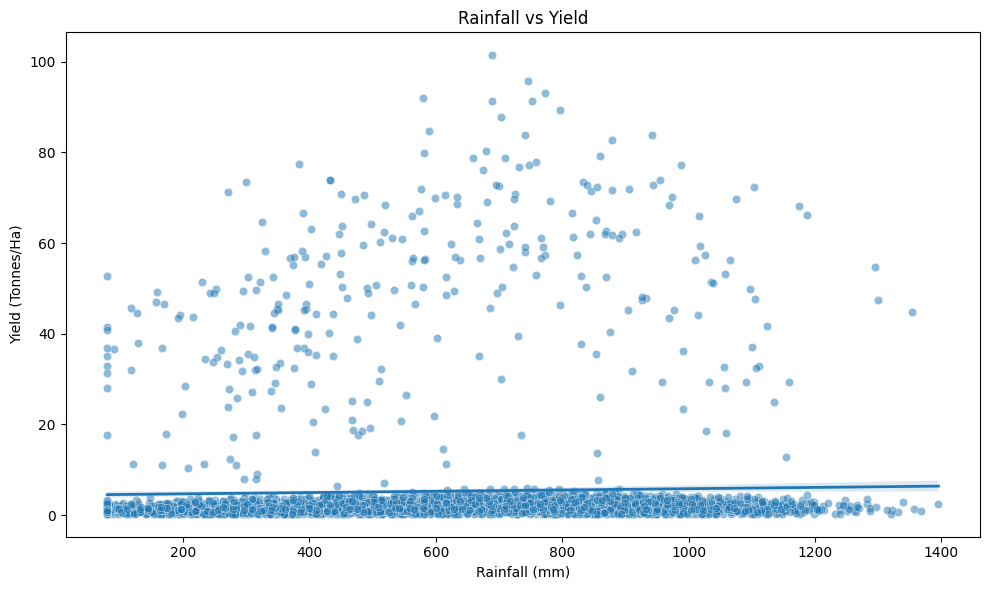

In [122]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=yield_df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    alpha=0.5
)

sns.regplot(
    data=yield_df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    scatter=False,
    line_kws={'linewidth': 2}
)

plt.title('Rainfall vs Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

In [123]:
rainfall_yield_corr = yield_df[
    ['Rainfall_mm', 'Yield_Tonnes_Ha']
].corr().iloc[0, 1]

print(f"Rainfall-Yield Correlation: {rainfall_yield_corr:.3f}")

Rainfall-Yield Correlation: 0.031


### 14.7 Temperature vs Yield

Temperature can influence crop growth and productivity. This relationship is examined using a scatter plot and Pearson correlation.

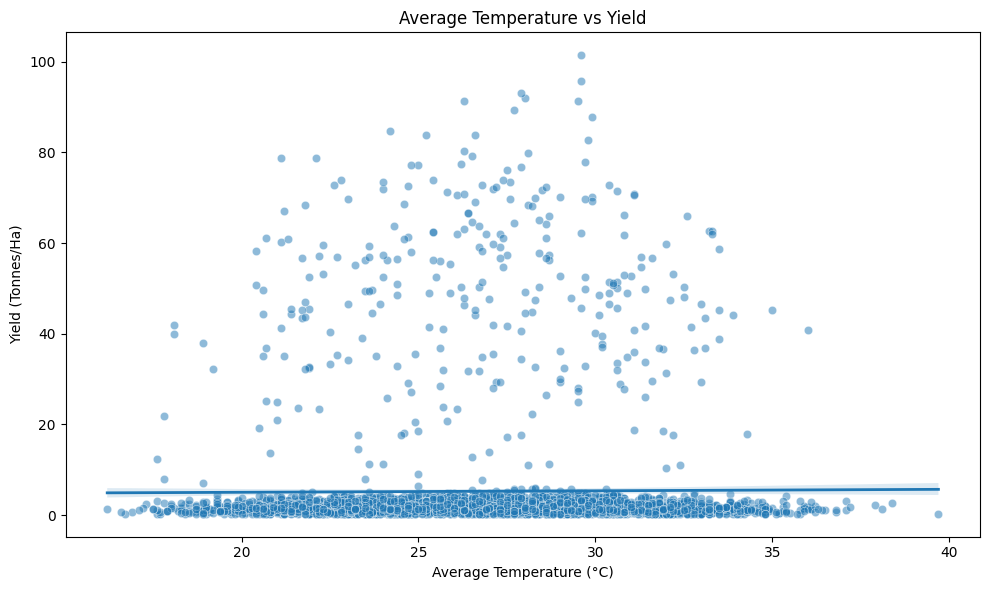

In [124]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=yield_df,
    x='Avg_Temperature_C',
    y='Yield_Tonnes_Ha',
    alpha=0.5
)

sns.regplot(
    data=yield_df,
    x='Avg_Temperature_C',
    y='Yield_Tonnes_Ha',
    scatter=False,
    line_kws={'linewidth': 2}
)

plt.title('Average Temperature vs Yield')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

In [125]:
temperature_yield_corr = yield_df[
    ['Avg_Temperature_C', 'Yield_Tonnes_Ha']
].corr().iloc[0, 1]

print(f"Temperature-Yield Correlation: {temperature_yield_corr:.3f}")

Temperature-Yield Correlation: 0.009


### 14.8 Water Usage vs Yield

Water availability and irrigation are important agricultural resources.

This analysis examines whether higher water usage is associated with higher crop yield.

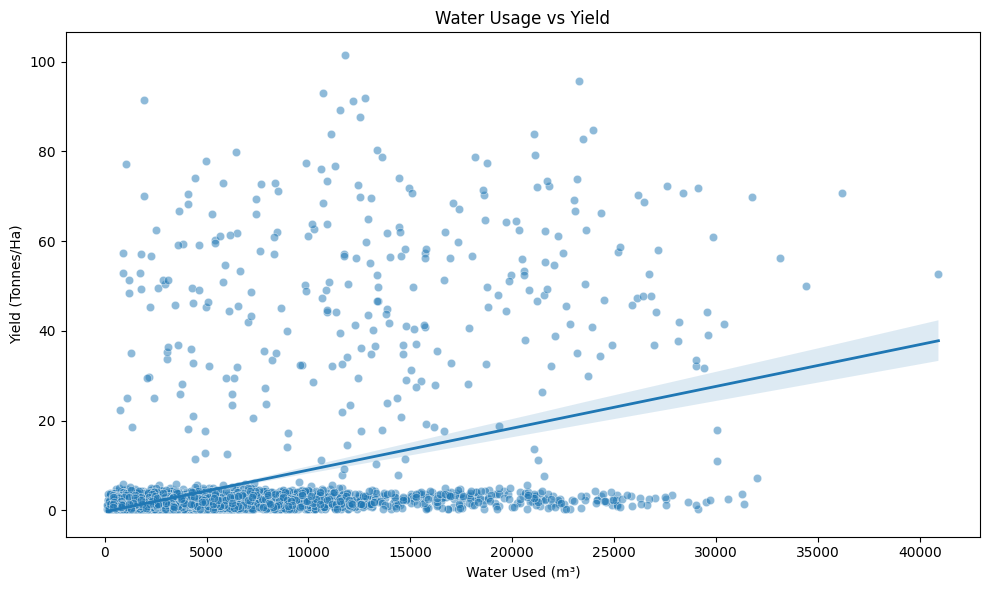

In [126]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=yield_df,
    x='Water_Used_m3',
    y='Yield_Tonnes_Ha',
    alpha=0.5
)

sns.regplot(
    data=yield_df,
    x='Water_Used_m3',
    y='Yield_Tonnes_Ha',
    scatter=False,
    line_kws={'linewidth': 2}
)

plt.title('Water Usage vs Yield')
plt.xlabel('Water Used (m³)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

In [127]:
water_yield_corr = yield_df[
    ['Water_Used_m3', 'Yield_Tonnes_Ha']
].corr().iloc[0, 1]

print(f"Water Usage-Yield Correlation: {water_yield_corr:.3f}")

Water Usage-Yield Correlation: 0.389


### 14.9 Fertilizer Usage vs Yield

Fertilizer provides essential nutrients to crops. This analysis investigates whether fertilizer application is associated with crop yield.

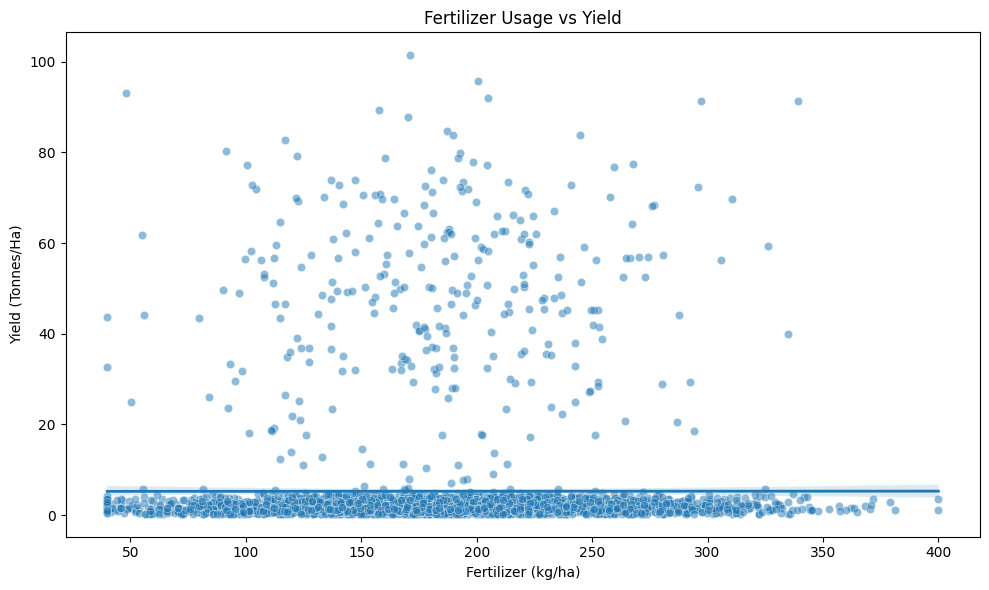

In [128]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=yield_df,
    x='Fertilizer_kg_ha',
    y='Yield_Tonnes_Ha',
    alpha=0.5
)

sns.regplot(
    data=yield_df,
    x='Fertilizer_kg_ha',
    y='Yield_Tonnes_Ha',
    scatter=False,
    line_kws={'linewidth': 2}
)

plt.title('Fertilizer Usage vs Yield')
plt.xlabel('Fertilizer (kg/ha)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

In [129]:
fertilizer_yield_corr = yield_df[
    ['Fertilizer_kg_ha', 'Yield_Tonnes_Ha']
].corr().iloc[0, 1]

print(f"Fertilizer-Yield Correlation: {fertilizer_yield_corr:.3f}")

Fertilizer-Yield Correlation: 0.001


### 14.10 Profit vs Yield

Higher productivity may contribute to higher economic returns. Therefore, the relationship between yield and profit is examined.

This helps connect agricultural productivity with economic performance.

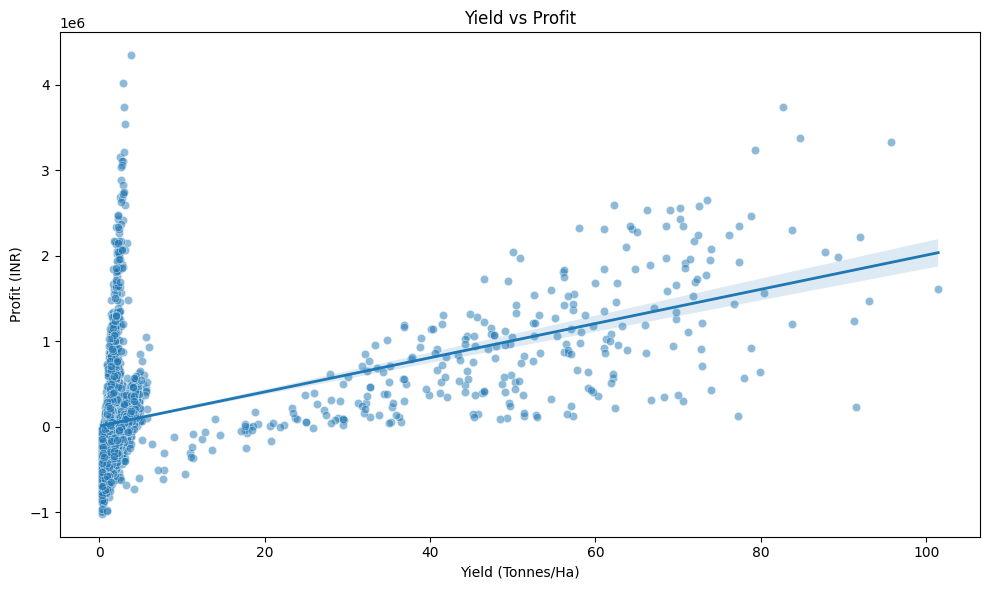

In [130]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=yield_df,
    x='Yield_Tonnes_Ha',
    y='Profit_INR',
    alpha=0.5
)

sns.regplot(
    data=yield_df,
    x='Yield_Tonnes_Ha',
    y='Profit_INR',
    scatter=False,
    line_kws={'linewidth': 2}
)

plt.title('Yield vs Profit')
plt.xlabel('Yield (Tonnes/Ha)')
plt.ylabel('Profit (INR)')

plt.tight_layout()
plt.show()

In [131]:
profit_yield_corr = yield_df[
    ['Yield_Tonnes_Ha', 'Profit_INR']
].corr().iloc[0, 1]

print(f"Yield-Profit Correlation: {profit_yield_corr:.3f}")

Yield-Profit Correlation: 0.490


### 14.11 Season-wise Correlation Analysis

Overall correlations may hide differences between seasons.

Therefore, correlations between major agricultural variables and yield are calculated separately for Kharif, Rabi and Zaid seasons.

In [132]:
season_correlations = {}

variables = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_Moisture_pct',
    'Soil_pH',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Water_Used_m3',
    'Disease_Pest_Risk_pct',
    'Profit_INR'
]

for season in df_clean['Season'].unique():
    season_data = df_clean[df_clean['Season'] == season]

    season_correlations[season] = (
        season_data[variables + ['Yield_Tonnes_Ha']]
        .corr()['Yield_Tonnes_Ha']
        .drop('Yield_Tonnes_Ha')
    )

season_corr_df = pd.DataFrame(season_correlations)

display(season_corr_df.round(3))

,Kharif,Rabi,Zaid
Rainfall_mm,-0.01,0.04,0.05
Avg_Temperature_C,-0.01,0.05,-0.04
Humidity_pct,-0.02,0.02,-0.06
Sunlight_Hours_Day,-0.02,0.01,0.02
Soil_Moisture_pct,0.00,-0.02,-0.03
Soil_pH,-0.03,-0.02,-0.02
Fertilizer_kg_ha,-0.01,0.01,0.01
Pesticide_Litre_ha,0.00,-0.01,-0.03
Water_Used_m3,0.36,0.43,0.41
Disease_Pest_Risk_pct,-0.03,0.01,0.04


## 14.12 Interpretation

The correlation analysis provides several important insights into agricultural performance.

1. Environmental variables such as rainfall, temperature, humidity and soil moisture do not necessarily show strong overall linear relationships with yield.

2. The dataset shows that agricultural productivity depends on multiple interacting factors rather than a single environmental variable.

3. Resource variables such as fertilizer and water usage should be interpreted carefully because higher usage does not automatically mean higher productivity.

4. Economic variables such as revenue, cost and profit are expected to have stronger relationships with production and yield because these variables are directly connected through agricultural output and market price.

5. Season-wise correlation analysis is useful because the relationship between an environmental or resource variable and yield can change from one season to another.

6. Correlation should not be interpreted as causation. A strong correlation indicates association but does not prove that one variable directly causes another.

Overall, the correlation analysis suggests that seasonal agricultural performance is influenced by a combination of environmental conditions, crop characteristics, resource management and economic factors.

## 15. Statistical Analysis & Hypothesis Testing

The objective of statistical analysis is to determine whether the differences
observed between agricultural seasons are statistically significant.

The following performance indicators will be tested:

- Yield
- Profit
- Water Usage
- Production
- Water Efficiency
- Disease/Pest Risk

Since there are three independent seasons (Kharif, Rabi and Zaid),
one-way ANOVA will be used to compare the mean values across seasons.

A significance level of α = 0.05 is used.

Interpretation:

- p-value < 0.05 → statistically significant difference
- p-value ≥ 0.05 → no statistically significant difference

### 15.2 Hypothesis Formulation

For each performance indicator, the hypotheses are:

**Null Hypothesis (H₀):**
The mean performance is the same across Kharif, Rabi and Zaid seasons.

**Alternative Hypothesis (H₁):**
At least one season has a significantly different mean performance.

The hypothesis will be evaluated using one-way ANOVA.

In [133]:
# Create seasonal groups for major performance indicators

season_groups = {
    'Yield': [
        df_clean[df_clean['Season'] == season]['Yield_Tonnes_Ha'].dropna()
        for season in ['Kharif', 'Rabi', 'Zaid']
    ],

    'Profit': [
        df_clean[df_clean['Season'] == season]['Profit_INR'].dropna()
        for season in ['Kharif', 'Rabi', 'Zaid']
    ],

    'Water Usage': [
        df_clean[df_clean['Season'] == season]['Water_Used_m3'].dropna()
        for season in ['Kharif', 'Rabi', 'Zaid']
    ],

    'Production': [
        df_clean[df_clean['Season'] == season]['Production_Tonnes'].dropna()
        for season in ['Kharif', 'Rabi', 'Zaid']
    ],

    'Water Efficiency': [
        df_clean[df_clean['Season'] == season]['Water_Efficiency_t_per_1000m3'].dropna()
        for season in ['Kharif', 'Rabi', 'Zaid']
    ],

    'Disease/Pest Risk': [
        df_clean[df_clean['Season'] == season]['Disease_Pest_Risk_pct'].dropna()
        for season in ['Kharif', 'Rabi', 'Zaid']
    ]
}

### 15.4 One-Way ANOVA

One-way ANOVA is used to compare the means of three or more independent groups.

In this project, the three groups are:

1. Kharif
2. Rabi
3. Zaid

The test determines whether the observed differences in agricultural
performance between seasons are larger than would be expected from
random variation alone.

In [134]:
anova_results = []

for metric, groups in season_groups.items():
    f_stat, p_value = stats.f_oneway(*groups)

    anova_results.append({
        'Metric': metric,
        'F-Statistic': f_stat,
        'P-Value': p_value,
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

anova_df = pd.DataFrame(anova_results)

display(anova_df.round(4))

,Metric,F-Statistic,P-Value,Significant
0,Yield,1.46,0.23,No
1,Profit,34.29,0.00,Yes
2,Water Usage,2.47,0.09,No
3,Production,1.03,0.36,No
4,Water Efficiency,6.95,0.00,Yes
5,Disease/Pest Risk,1049.47,0.00,Yes


In [135]:
print("ANOVA Interpretation")
print("=" * 60)

for _, row in anova_df.iterrows():
    if row['P-Value'] < 0.05:
        print(
            f"{row['Metric']}: Significant difference "
            f"(p = {row['P-Value']:.4f})"
        )
    else:
        print(
            f"{row['Metric']}: No significant difference "
            f"(p = {row['P-Value']:.4f})"
        )

ANOVA Interpretation
Yield: No significant difference (p = 0.2328)
Profit: Significant difference (p = 0.0000)
Water Usage: No significant difference (p = 0.0850)
Production: No significant difference (p = 0.3585)
Water Efficiency: Significant difference (p = 0.0010)
Disease/Pest Risk: Significant difference (p = 0.0000)


### Interpretation Rule

If the ANOVA p-value is below 0.05, we reject the null hypothesis.

This means that there is statistical evidence that at least one season
has a different mean value for that performance indicator.

If the p-value is greater than or equal to 0.05, we do not reject the
null hypothesis.

However, ANOVA does not tell us **which specific seasons differ**.
Therefore, when ANOVA is significant, a post-hoc Tukey HSD test is performed.

### 15.6 Tukey HSD Post-Hoc Analysis

When ANOVA indicates a statistically significant difference,
Tukey's Honestly Significant Difference (HSD) test is used to determine
which pairs of seasons are significantly different.

The three possible comparisons are:

- Kharif vs Rabi
- Kharif vs Zaid
- Rabi vs Zaid

In [206]:
# Create seasonal groups for major performance indicators

season_groups = {
    'Yield': [
        df_clean[df_clean['Season'] == season]['Yield_Tonnes_Ha'].dropna()
        for season in ['Kharif', 'Rabi', 'Zaid']
    ],

    'Profit': [
        df_clean[df_clean['Season'] == season]['Profit_INR'].dropna()
        for season in ['Kharif', 'Rabi', 'Zaid']
    ],

    'Water Usage': [
        df_clean[df_clean['Season'] == season]['Water_Used_m3'].dropna()
        for season in ['Kharif', 'Rabi', 'Zaid']
    ],

    'Production': [
        df_clean[df_clean['Season'] == season]['Production_Tonnes'].dropna()
        for season in ['Kharif', 'Rabi', 'Zaid']
    ],

    'Water Efficiency': [
        df_clean[
            df_clean['Season'] == season
        ]['Water_Efficiency_t_per_1000m3'].dropna()
        for season in ['Kharif', 'Rabi', 'Zaid']
    ],

    'Disease/Pest Risk': [
        df_clean[
            df_clean['Season'] == season
        ]['Disease_Pest_Risk_pct'].dropna()
        for season in ['Kharif', 'Rabi', 'Zaid']
    ]
}

anova_results = []

for metric, groups in season_groups.items():
    f_stat, p_value = stats.f_oneway(*groups)

    anova_results.append({
        'Metric': metric,
        'F-Statistic': f_stat,
        'P-Value': p_value,
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

anova_df = pd.DataFrame(anova_results)

display(anova_df.round(4))

,Metric,F-Statistic,P-Value,Significant
0,Yield,1.46,0.23,No
1,Profit,34.29,0.00,Yes
2,Water Usage,2.47,0.09,No
3,Production,1.03,0.36,No
4,Water Efficiency,6.95,0.00,Yes
5,Disease/Pest Risk,1049.47,0.00,Yes


In [202]:
import sys
!{sys.executable} -m pip install statsmodels

from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Create seasonal groups for major performance indicators (moved from an earlier cell for consistency)
season_groups = {
    'Yield': [
        df_clean[df_clean['Season'] == season]['Yield_Tonnes_Ha'].dropna()
        for season in ['Kharif', 'Rabi', 'Zaid']
    ],

    'Profit': [
        df_clean[df_clean['Season'] == season]['Profit_INR'].dropna()
        for season in ['Kharif', 'Rabi', 'Zaid']
    ],

    'Water Usage': [
        df_clean[df_clean['Season'] == season]['Water_Used_m3'].dropna()
        for season in ['Kharif', 'Rabi', 'Zaid']
    ],

    'Production': [
        df_clean[df_clean['Season'] == season]['Production_Tonnes'].dropna()
        for season in ['Kharif', 'Rabi', 'Zaid']
    ],

    'Water Efficiency': [
        df_clean[df_clean['Season'] == season]['Water_Efficiency_t_per_1000m3'].dropna()
        for season in ['Kharif', 'Rabi', 'Zaid']
    ],

    'Disease/Pest Risk': [
        df_clean[df_clean['Season'] == season]['Disease_Pest_Risk_pct'].dropna()
        for season in ['Kharif', 'Rabi', 'Zaid']
    ]
}

# Calculate anova_df (moved from an earlier cell for consistency)
anova_results = []

for metric, groups in season_groups.items():
    f_stat, p_value = stats.f_oneway(*groups)

    anova_results.append({
        'Metric': metric,
        'F-Statistic': f_stat,
        'P-Value': p_value,
        'Significant': 'Yes' if p_value < 0.05 else 'No'
    })

anova_df = pd.DataFrame(anova_results)

tukey_results = {}

for metric in season_groups.keys():

    if anova_df.loc[
        anova_df['Metric'] == metric, 'P-Value'
    ].iloc[0] < 0.05:

        metric_data = df_clean[
            ['Season']
        ].copy()

        if metric == 'Yield':
            metric_data['Value'] = df_clean['Yield_Tonnes_Ha']
        elif metric == 'Profit':
            metric_data['Value'] = df_clean['Profit_INR']
        elif metric == 'Water Usage':
            metric_data['Value'] = df_clean['Water_Used_m3']
        elif metric == 'Production':
            metric_data['Value'] = df_clean['Production_Tonnes']
        elif metric == 'Water Efficiency':
            metric_data['Value'] = df_clean['Water_Efficiency_t_per_1000m3']
        elif metric == 'Disease/Pest Risk':
            metric_data['Value'] = df_clean['Disease_Pest_Risk_pct']

        metric_data = metric_data.dropna()

        tukey = pairwise_tukeyhsd(
            endog=metric_data['Value'],
            groups=metric_data['Season'],
            alpha=0.05
        )

        tukey_results[metric] = tukey

        print(f"\n{'='*70}")
        print(f"Tukey HSD Results: {metric}")
        print('='*70)
        print(tukey)


Tukey HSD Results: Profit
       Multiple Comparison of Means - Tukey HSD, FWER=0.05       
group1 group2   meandiff   p-adj    lower        upper     reject
-----------------------------------------------------------------
Kharif   Rabi  -91225.1774   0.0 -134704.3086  -47746.0461   True
Kharif   Zaid -203719.4725   0.0 -263782.6023 -143656.3426   True
  Rabi   Zaid -112494.2951   0.0 -173255.6664  -51732.9238   True
-----------------------------------------------------------------

Tukey HSD Results: Water Efficiency
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
Kharif   Rabi  -0.7057 0.0517 -1.4155  0.0041  False
Kharif   Zaid  -1.4786 0.0012 -2.4591 -0.4981   True
  Rabi   Zaid  -0.7729 0.1609 -1.7648   0.219  False
----------------------------------------------------

Tukey HSD Results: Disease/Pest Risk
 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 grou

### 15.7 Effect Size

Effect size measures how large the seasonal effect is.

Eta squared (η²) is calculated as:

η² = Between-Group Sum of Squares / Total Sum of Squares

A larger η² indicates that a larger proportion of the variation in the
performance indicator is associated with differences between seasons.

This provides additional information beyond statistical significance.

In [137]:
def eta_squared(groups):
    all_values = np.concatenate(groups)

    grand_mean = np.mean(all_values)

    ss_between = sum(
        len(group) * (np.mean(group) - grand_mean) ** 2
        for group in groups
    )

    ss_total = sum(
        (value - grand_mean) ** 2
        for value in all_values
    )

    return ss_between / ss_total


effect_results = []

for metric, groups in season_groups.items():
    eta_sq = eta_squared(groups)

    effect_results.append({
        'Metric': metric,
        'Eta Squared': eta_sq
    })

effect_df = pd.DataFrame(effect_results)

display(effect_df.round(4))

,Metric,Eta Squared
0,Yield,0.00
1,Profit,0.02
2,Water Usage,0.00
3,Production,0.00
4,Water Efficiency,0.00
5,Disease/Pest Risk,0.34


In [138]:
def interpret_eta_squared(value):
    if value < 0.01:
        return 'Very small'
    elif value < 0.06:
        return 'Small'
    elif value < 0.14:
        return 'Medium'
    else:
        return 'Large'


effect_df['Effect Interpretation'] = (
    effect_df['Eta Squared']
    .apply(interpret_eta_squared)
)

display(effect_df)

,Metric,Eta Squared,Effect Interpretation
0,Yield,0.00,Very small
1,Profit,0.02,Small
2,Water Usage,0.00,Very small
3,Production,0.00,Very small
4,Water Efficiency,0.00,Very small
5,Disease/Pest Risk,0.34,Large


### Effect Size Interpretation

For this project, eta squared can be interpreted approximately as:

- < 0.01 → Very small effect
- 0.01–0.06 → Small effect
- 0.06–0.14 → Medium effect
- ≥ 0.14 → Large effect

Effect size should be considered together with the p-value.

A statistically significant result with a very small effect size may have
limited practical importance.

In [139]:
yield_groups = [
    yield_df[yield_df['Season'] == season]['Yield_Tonnes_Ha']
    for season in ['Kharif', 'Rabi', 'Zaid']
]

yield_anova = stats.f_oneway(*yield_groups)

print("Yield ANOVA Results")
print("-" * 40)
print(f"F-statistic : {yield_anova.statistic:.4f}")
print(f"P-value     : {yield_anova.pvalue:.6f}")

if yield_anova.pvalue < 0.05:
    print("Conclusion  : Seasonal yield differences are statistically significant.")
else:
    print("Conclusion  : Seasonal yield differences are not statistically significant.")

Yield ANOVA Results
----------------------------------------
F-statistic : 1.4580
P-value     : 0.232835
Conclusion  : Seasonal yield differences are not statistically significant.


In [140]:
profit_groups = [
    df_clean[df_clean['Season'] == season]['Profit_INR'].dropna()
    for season in ['Kharif', 'Rabi', 'Zaid']
]

profit_anova = stats.f_oneway(*profit_groups)

print("Profit ANOVA Results")
print("-" * 40)
print(f"F-statistic : {profit_anova.statistic:.4f}")
print(f"P-value     : {profit_anova.pvalue:.6f}")

if profit_anova.pvalue < 0.05:
    print("Conclusion  : Seasonal profit differences are statistically significant.")
else:
    print("Conclusion  : Seasonal profit differences are not statistically significant.")

Profit ANOVA Results
----------------------------------------
F-statistic : 34.2918
P-value     : 0.000000
Conclusion  : Seasonal profit differences are statistically significant.


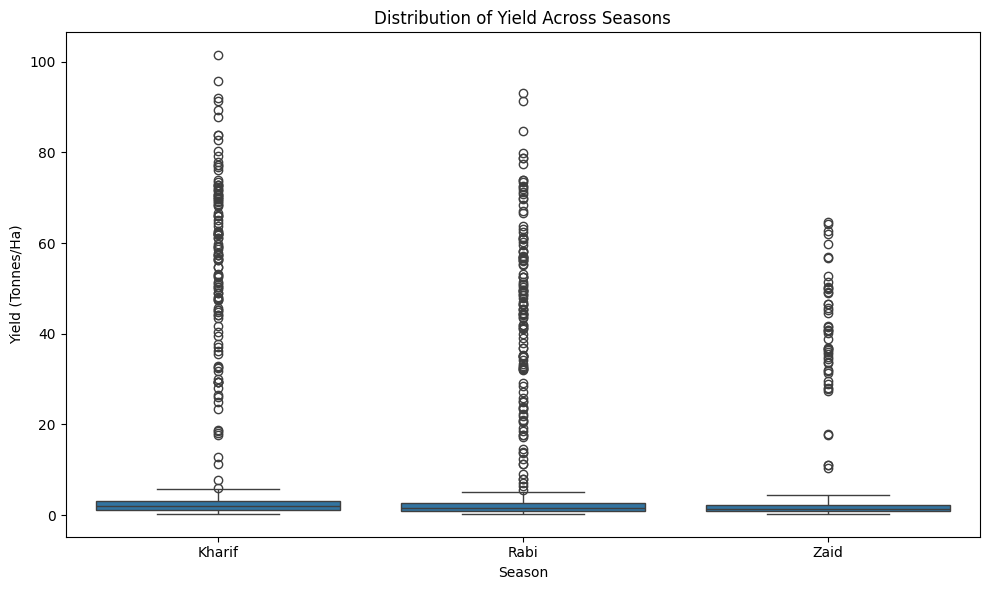

In [141]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=yield_df,
    x='Season',
    y='Yield_Tonnes_Ha'
)

plt.title('Distribution of Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

In [142]:
statistical_summary = (
    df_clean.groupby('Season')
    .agg(
        Mean_Yield=('Yield_Tonnes_Ha', 'mean'),
        Median_Yield=('Yield_Tonnes_Ha', 'median'),
        Std_Yield=('Yield_Tonnes_Ha', 'std'),
        Mean_Profit=('Profit_INR', 'mean'),
        Median_Profit=('Profit_INR', 'median'),
        Mean_Water_Use=('Water_Used_m3', 'mean'),
        Mean_Water_Efficiency=(
            'Water_Efficiency_t_per_1000m3',
            'mean'
        )
    )
    .round(2)
)

display(statistical_summary)

,Mean_Yield,Median_Yield,Std_Yield,Mean_Profit,Median_Profit,Mean_Water_Use,Mean_Water_Efficiency
Season,,,,,,,
Kharif,5.64,1.95,14.42,178914.65,38808.00,6102.20,5.89
Rabi,5.08,1.66,12.83,87689.47,-3187.00,5846.99,5.19
Zaid,4.67,1.45,11.32,-24804.82,-62144.00,6419.89,4.41


## 15.13 Statistical Analysis — Key Findings

The hypothesis testing stage provides statistical evidence for the seasonal
differences observed during exploratory analysis.

The main conclusions should be interpreted using the calculated ANOVA
p-values rather than assuming that visual differences are automatically
statistically significant.

### Hypothesis Decision

For each metric:

- If p-value < 0.05:
  Reject H₀ and conclude that seasonal differences are statistically significant.

- If p-value ≥ 0.05:
  Do not reject H₀ because sufficient statistical evidence of a seasonal
  difference was not found.

### Practical Interpretation

The analysis allows us to distinguish between:

1. Differences that are visible in charts.
2. Differences that are statistically significant.
3. Differences that are statistically significant and practically meaningful.

This is important because agricultural performance can vary naturally
between farms, crops, districts and environmental conditions.

Therefore, statistical testing provides stronger evidence for making
season-based agricultural recommendations.

### Overall Conclusion

One-way ANOVA was applied to compare agricultural performance across
Kharif, Rabi and Zaid seasons.

The analysis evaluates whether seasonal variation in yield, profit,
water usage, production, water efficiency and disease/pest risk is
statistically meaningful.

Where significant differences are identified, Tukey HSD is used to
identify the specific seasonal pairs responsible for the difference.

Effect size analysis using eta squared provides additional insight into
the practical importance of seasonal variation.

Thus, hypothesis testing strengthens the project by moving beyond
descriptive observations and providing statistical evidence for the
relationship between season and agricultural performance.

## 16. Outlier Detection & Anomaly Analysis

The objective of this section is to identify unusual observations
in the agricultural dataset.

Outlier detection can help identify:

- Extremely high or low crop yield
- Unusually high or low profit
- Excessive water usage
- Extreme rainfall or temperature
- Unusual fertilizer or pesticide usage
- Abnormally high disease/pest risk
- Other unusual agricultural conditions

The Interquartile Range (IQR) method is used to identify potential
outliers.

An observation is considered a potential outlier when it lies below:

Q1 - 1.5 × IQR

or above:

Q3 + 1.5 × IQR

Outliers are not automatically treated as errors. They may represent
genuine exceptional farming conditions or unusual observations.

In [143]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return outliers, lower_bound, upper_bound


print("IQR Outlier Detection Function Created Successfully.")

IQR Outlier Detection Function Created Successfully.


### 16.3 Outlier Detection for Important Agricultural Variables

The following variables are examined for potential outliers:

- Rainfall
- Temperature
- Soil Moisture
- Fertilizer Usage
- Pesticide Usage
- Water Usage
- Yield
- Production
- Profit
- Disease/Pest Risk

In [144]:
outlier_columns = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Soil_Moisture_pct',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Water_Used_m3',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Profit_INR',
    'Disease_Pest_Risk_pct'
]

outlier_summary = []

for column in outlier_columns:
    outliers, lower, upper = detect_outliers_iqr(df_clean, column)

    outlier_summary.append({
        'Variable': column,
        'Q1': df_clean[column].quantile(0.25),
        'Q3': df_clean[column].quantile(0.75) -
               df_clean[column].quantile(0.25),
        'Lower Bound': lower,
        'Upper Bound': upper,
        'Outlier Count': len(outliers),
        'Outlier Percentage': (len(outliers) / len(df_clean)) * 100
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

display(outlier_summary_df.round(2))

,Variable,Q1,Q3,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,Rainfall_mm,371.58,460.40,-319.02,1522.57,0,0.00
1,Avg_Temperature_C,23.90,5.70,15.35,38.15,2,0.05
2,Soil_Moisture_pct,21.80,9.40,7.70,45.30,5,0.12
3,Fertilizer_kg_ha,143.98,83.22,19.14,352.04,15,0.38
4,Pesticide_Litre_ha,3.69,2.71,-0.38,10.46,8,0.20
5,Water_Used_m3,2268.75,5561.00,-6072.75,16171.25,276,6.90
6,Yield_Tonnes_Ha,1.05,1.79,-1.63,5.52,302,7.55
7,Production_Tonnes,5.02,19.34,-23.98,53.36,333,8.33
8,Profit_INR,-148731.75,364919.50,-696111.00,763567.00,404,10.10
9,Disease_Pest_Risk_pct,37.30,17.60,10.90,81.30,10,0.25


### 16.4 Boxplot Analysis

Boxplots provide a visual way to identify potential outliers.

Observations appearing beyond the whiskers are potential outliers
according to the IQR method.

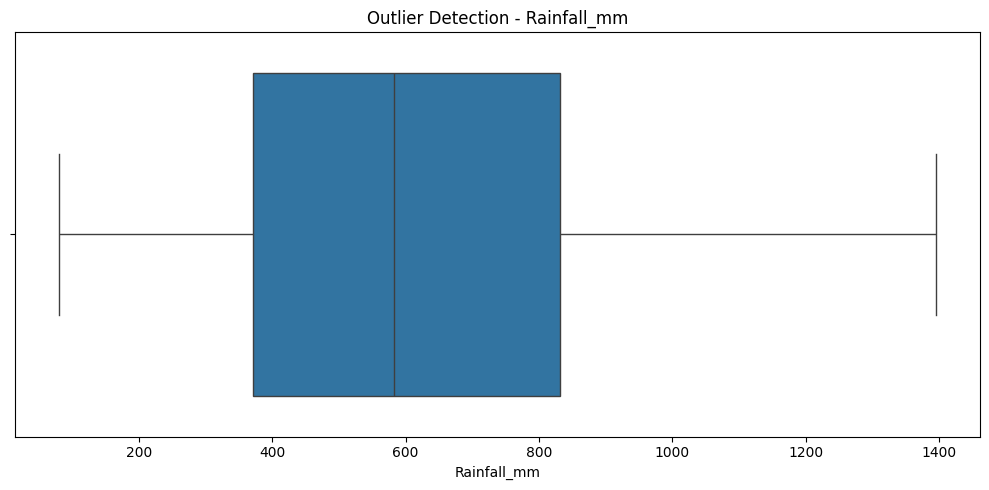

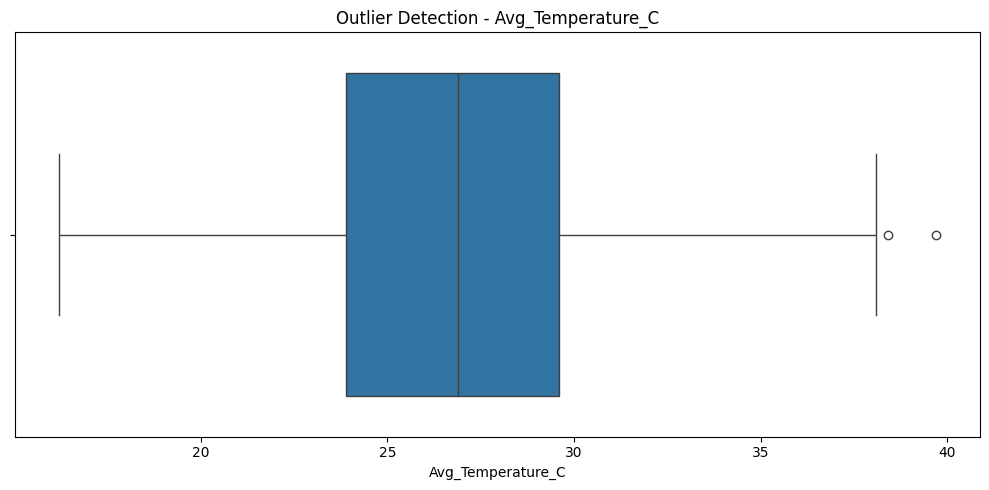

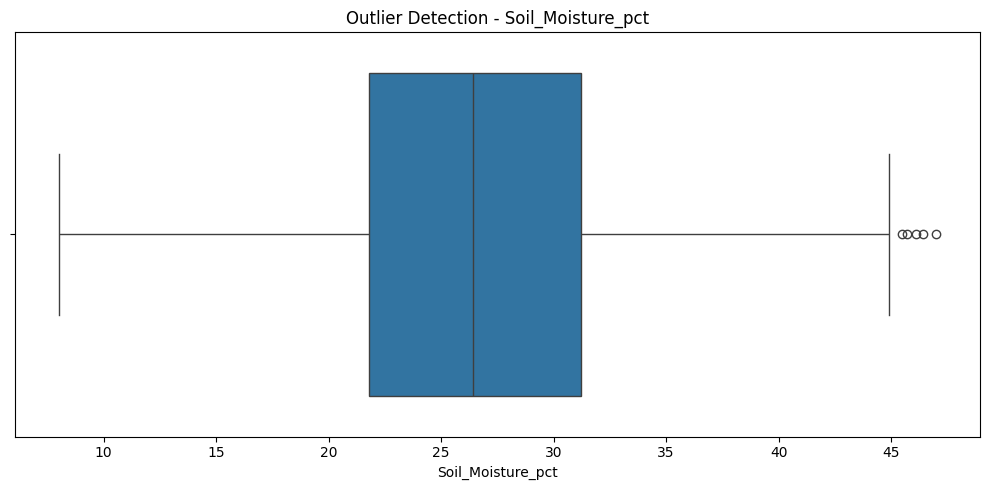

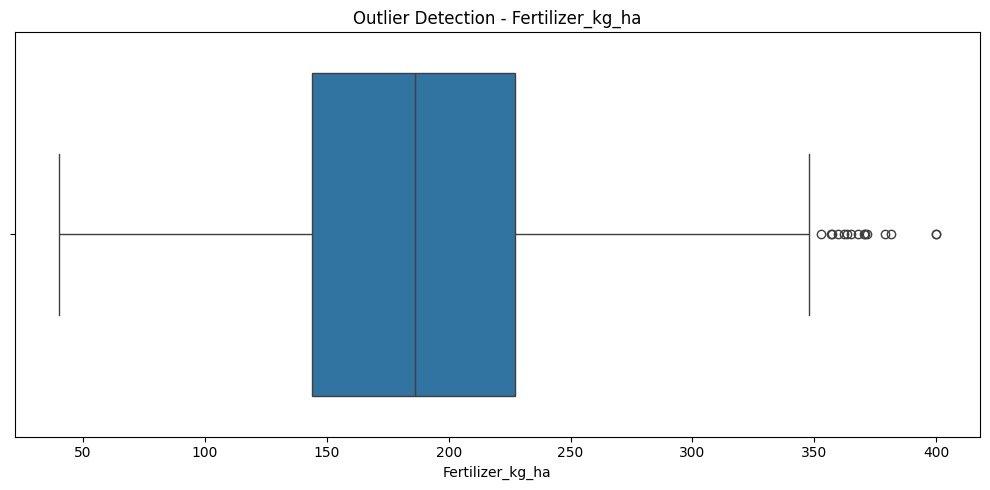

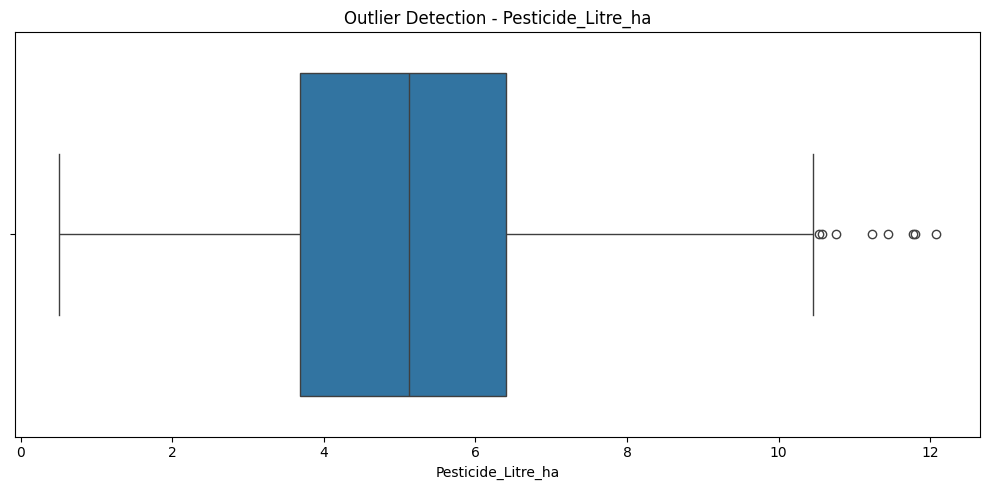

In [145]:
boxplot_columns = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Soil_Moisture_pct',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha'
]

for column in boxplot_columns:
    plt.figure(figsize=(10, 5))

    sns.boxplot(
        x=df_clean[column].dropna()
    )

    plt.title(f'Outlier Detection - {column}')
    plt.xlabel(column)

    plt.tight_layout()
    plt.show()

In [146]:
yield_outliers, yield_lower, yield_upper = detect_outliers_iqr(
    df_clean,
    'Yield_Tonnes_Ha'
)

print(f"Lower Bound: {yield_lower:.2f}")
print(f"Upper Bound: {yield_upper:.2f}")
print(f"Number of Yield Outliers: {len(yield_outliers)}")
print(
    f"Percentage of Yield Outliers: "
    f"{len(yield_outliers) / len(df_clean) * 100:.2f}%"
)

Lower Bound: -1.63
Upper Bound: 5.52
Number of Yield Outliers: 302
Percentage of Yield Outliers: 7.55%


In [147]:
yield_outliers, yield_lower, yield_upper = detect_outliers_iqr(
    df_clean,
    'Yield_Tonnes_Ha'
)

yield_outlier_records = yield_outliers[
    [
        'Farm_ID',
        'State',
        'District',
        'Crop',
        'Season',
        'Farm_Area_Hectares',
        'Yield_Tonnes_Ha',
        'Production_Tonnes',
        'Water_Used_m3',
        'Profit_INR'
    ]
].sort_values(
    'Yield_Tonnes_Ha',
    ascending=False
)

display(yield_outlier_records.head(20))

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Yield_Tonnes_Ha,Production_Tonnes,Water_Used_m3,Profit_INR
1715,SF11716,Gujarat,Indore,Sugarcane,Kharif,6.32,101.44,641.10,11781,1608291
3423,SF13424,Andhra Pradesh,Indore,Sugarcane,Kharif,14.87,95.79,1424.40,23289,3330582
3525,SF13526,Andhra Pradesh,Erode,Sugarcane,Rabi,6.96,93.13,648.18,10705,1471529
1464,SF11465,Gujarat,Nashik,Sugarcane,Kharif,7.65,91.98,703.65,12787,2216708
3523,SF13524,Karnataka,Nashik,Sugarcane,Kharif,0.82,91.46,75.00,1944,234320
2782,SF12783,Gujarat,Nalgonda,Sugarcane,Rabi,5.72,91.32,522.35,12199,1236801
644,SF10645,Andhra Pradesh,Ludhiana,Sugarcane,Kharif,7.48,89.34,668.26,11547,1984818
2847,SF12848,Telangana,Warangal,Sugarcane,Kharif,7.66,87.76,672.24,12526,2041678
357,SF10358,Punjab,Warangal,Sugarcane,Rabi,14.74,84.75,1249.21,23936,3378879
1178,SF11179,Karnataka,Nalgonda,Sugarcane,Kharif,6.38,83.79,534.58,11086,1200815


### Yield Outlier Interpretation

The identified yield outliers represent farms whose yield per hectare
is substantially different from the central distribution.

High-yield outliers may indicate:

- Highly productive farming practices
- Favorable crop and soil conditions
- Efficient irrigation
- High-quality seeds
- Effective nutrient management

Low-yield outliers may indicate:

- Poor environmental conditions
- Disease or pest pressure
- Inefficient resource usage
- Crop-specific difficulties
- Unfavorable farming conditions

These observations should be investigated rather than automatically removed.

In [148]:
profit_outliers, profit_lower, profit_upper = detect_outliers_iqr(
    df_clean,
    'Profit_INR'
)

print(f"Lower Bound: ₹{profit_lower:,.2f}")
print(f"Upper Bound: ₹{profit_upper:,.2f}")
print(f"Number of Profit Outliers: {len(profit_outliers)}")
print(
    f"Percentage of Profit Outliers: "
    f"{len(profit_outliers) / len(df_clean) * 100:.2f}%"
)

Lower Bound: ₹-696,111.00
Upper Bound: ₹763,567.00
Number of Profit Outliers: 404
Percentage of Profit Outliers: 10.10%


In [149]:
profit_outliers, profit_lower, profit_upper = detect_outliers_iqr(
    df_clean,
    'Profit_INR'
)

profit_outlier_records = profit_outliers[
    [
        'Farm_ID',
        'State',
        'District',
        'Crop',
        'Season',
        'Yield_Tonnes_Ha',
        'Market_Price_INR_Tonne',
        'Total_Cost_INR',
        'Revenue_INR',
        'Profit_INR'
    ]
].sort_values(
    'Profit_INR',
    ascending=False
)

display(profit_outlier_records.head(20))

,Farm_ID,State,District,Crop,Season,Yield_Tonnes_Ha,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR
2236,SF12237,Punjab,Rajkot,Chilli,Kharif,3.90,101780,712027,5057448,4345421
626,SF10627,Maharashtra,Warangal,Chilli,Kharif,2.92,120429,1059050,5080900,4021850
3425,SF13426,Madhya Pradesh,Rajkot,Sugarcane,Kharif,82.68,3886,745161,4485260,3740099
1690,SF11691,Karnataka,Warangal,Chilli,Kharif,3.01,115222,784135,4522464,3738329
247,SF10248,Maharashtra,Krishna,Chilli,Kharif,3.09,105082,1283161,4825365,3542204
357,SF10358,Punjab,Warangal,Sugarcane,Rabi,84.75,3483,972119,4350998,3378879
3423,SF13424,Andhra Pradesh,Indore,Sugarcane,Kharif,95.79,3109,1097878,4428460,3330582
1930,SF11931,Tamil Nadu,Guntur,Sugarcane,Kharif,79.25,3661,875331,4108301,3232970
3983,SF13984,Gujarat,Nashik,Chilli,Kharif,3.02,98175,844264,4055609,3211345
263,SF10264,Maharashtra,Ludhiana,Chilli,Rabi,2.53,112997,828217,3987664,3159447


In [150]:
negative_profit = df_clean[
    df_clean['Profit_INR'] < 0
].copy()

print(f"Farms with Negative Profit: {len(negative_profit)}")
print(
    f"Percentage of Farms with Negative Profit: "
    f"{len(negative_profit) / len(df_clean) * 100:.2f}%"
)

display(
    negative_profit[
        [
            'Farm_ID',
            'State',
            'District',
            'Crop',
            'Season',
            'Yield_Tonnes_Ha',
            'Market_Price_INR_Tonne',
            'Total_Cost_INR',
            'Revenue_INR',
            'Profit_INR'
        ]
    ].sort_values('Profit_INR').head(20)
)

Farms with Negative Profit: 1966
Percentage of Farms with Negative Profit: 49.15%


,Farm_ID,State,District,Crop,Season,Yield_Tonnes_Ha,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR
780,SF10781,Andhra Pradesh,Ludhiana,Groundnut,Rabi,0.30,63813,1299362,280139,-1019223
2210,SF12211,Andhra Pradesh,Raichur,Wheat,Rabi,0.30,23948,1097692,102497,-995195
3625,SF13626,Punjab,Krishna,Maize,Rabi,0.97,17330,1207553,226503,-981050
2182,SF12183,Andhra Pradesh,Krishna,Rice,Kharif,1.01,21578,1297725,320865,-976860
104,SF10105,Gujarat,Krishna,Wheat,Zaid,0.30,26773,1063989,98792,-965197
3394,SF13395,Gujarat,Erode,Wheat,Kharif,0.30,24787,1063040,99644,-963396
2730,SF12731,Madhya Pradesh,Ludhiana,Rice,Rabi,NaN,24777,995279,89197,-906082
1311,SF11312,Punjab,Rajkot,Rice,Zaid,0.45,26735,1065824,163084,-902740
585,SF10586,Telangana,Warangal,Cotton,Zaid,0.30,47327,1094030,198300,-895730
3090,SF13091,Karnataka,Ludhiana,Maize,Kharif,0.41,18479,999667,109026,-890641


In [151]:
negative_profit_by_season = (
    negative_profit
    .groupby('Season')
    .size()
    .sort_values(ascending=False)
)

display(negative_profit_by_season)

Season
Rabi      832
Kharif    751
Zaid      383
dtype: int64

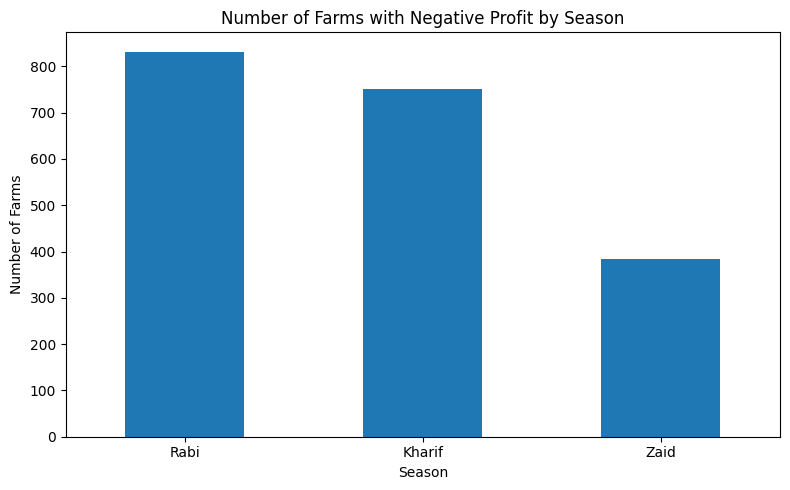

In [152]:
plt.figure(figsize=(8, 5))

negative_profit_by_season.plot(kind='bar')

plt.title('Number of Farms with Negative Profit by Season')
plt.xlabel('Season')
plt.ylabel('Number of Farms')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 16.10 Water Usage Anomalies

Water is a major agricultural resource.

Extremely high water usage may indicate:

- Inefficient irrigation
- Water-intensive crops
- Poor water management
- Seasonal water requirements

Extremely low usage may indicate:

- Efficient irrigation
- Rain-fed farming
- Water scarcity
- Crop-specific requirements

In [153]:
water_outliers, water_lower, water_upper = detect_outliers_iqr(
    df_clean,
    'Water_Used_m3'
)

print(f"Lower Bound: {water_lower:.2f} m³")
print(f"Upper Bound: {water_upper:.2f} m³")
print(f"Number of Water Usage Outliers: {len(water_outliers)}")

Lower Bound: -6072.75 m³
Upper Bound: 16171.25 m³
Number of Water Usage Outliers: 276


In [154]:
display(
    water_outliers[
        [
            'Farm_ID',
            'State',
            'District',
            'Crop',
            'Season',
            'Water_Used_m3',
            'Yield_Tonnes_Ha',
            'Water_Efficiency_t_per_1000m3'
        ]
    ]
    .sort_values('Water_Used_m3', ascending=False)
    .head(20)
)


,Farm_ID,State,District,Crop,Season,Water_Used_m3,Yield_Tonnes_Ha,Water_Efficiency_t_per_1000m3
2920,SF12921,Maharashtra,Ludhiana,Sugarcane,Rabi,40902,52.62,19.01
762,SF10763,Karnataka,Nalgonda,Sugarcane,Kharif,36156,70.62,28.26
1400,SF11401,Punjab,Nalgonda,Sugarcane,Zaid,34392,50.01,19.78
3780,SF13781,Karnataka,Erode,Sugarcane,Kharif,33109,56.17,22.19
1207,SF11208,Maharashtra,Guntur,Sugarcane,Rabi,31992,7.15,3.10
3279,SF13280,Tamil Nadu,Krishna,Sugarcane,Kharif,31776,69.80,25.20
3293,SF13294,Telangana,Indore,Rice,Rabi,31373,1.49,0.70
214,SF10215,Punjab,Krishna,Rice,Kharif,31242,3.59,1.57
1352,SF11353,Andhra Pradesh,Ludhiana,Rice,Zaid,30583,2.55,1.23
3118,SF13119,Madhya Pradesh,Raichur,Sugarcane,Zaid,30397,41.63,20.35


In [155]:
environmental_columns = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Soil_Moisture_pct',
    'Sunlight_Hours_Day'
]

environmental_outliers = {}

for column in environmental_columns:
    outliers, lower, upper = detect_outliers_iqr(
        df_clean,
        column
    )

    environmental_outliers[column] = {
        'count': len(outliers),
        'lower_bound': lower,
        'upper_bound': upper
    }

environmental_outlier_df = pd.DataFrame(
    environmental_outliers
).T

display(environmental_outlier_df.round(2))

,count,lower_bound,upper_bound
Rainfall_mm,0.00,-319.02,1522.57
Avg_Temperature_C,2.00,15.35,38.15
Humidity_pct,6.00,29.09,97.59
Soil_Moisture_pct,5.00,7.70,45.30
Sunlight_Hours_Day,26.00,4.35,10.35


In [156]:
yield_outlier_season = (
    yield_outliers
    .groupby('Season')
    .size()
    .reindex(['Kharif', 'Rabi', 'Zaid'], fill_value=0)
)

display(yield_outlier_season)

Season
Kharif    129
Rabi      124
Zaid       49
dtype: int64

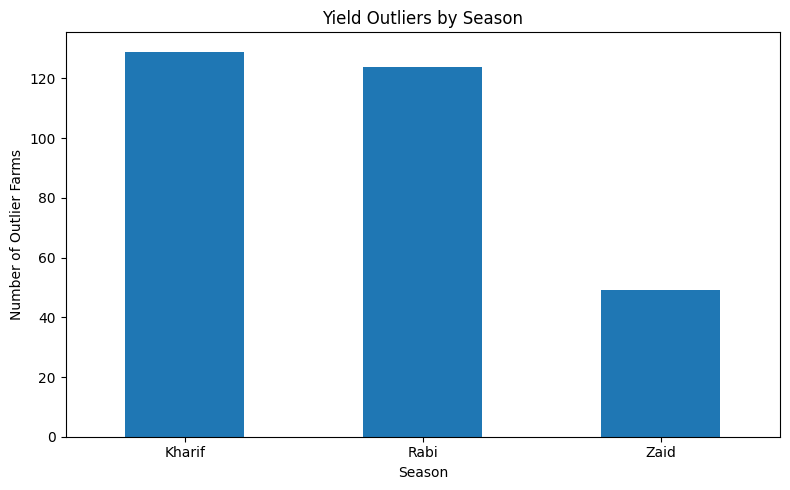

In [157]:
plt.figure(figsize=(8, 5))

yield_outlier_season.plot(kind='bar')

plt.title('Yield Outliers by Season')
plt.xlabel('Season')
plt.ylabel('Number of Outlier Farms')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [158]:
yield_outlier_crop = (
    yield_outliers
    .groupby('Crop')
    .size()
    .sort_values(ascending=False)
)

display(yield_outlier_crop)

Crop
Sugarcane    293
Maize          7
Rice           2
dtype: int64

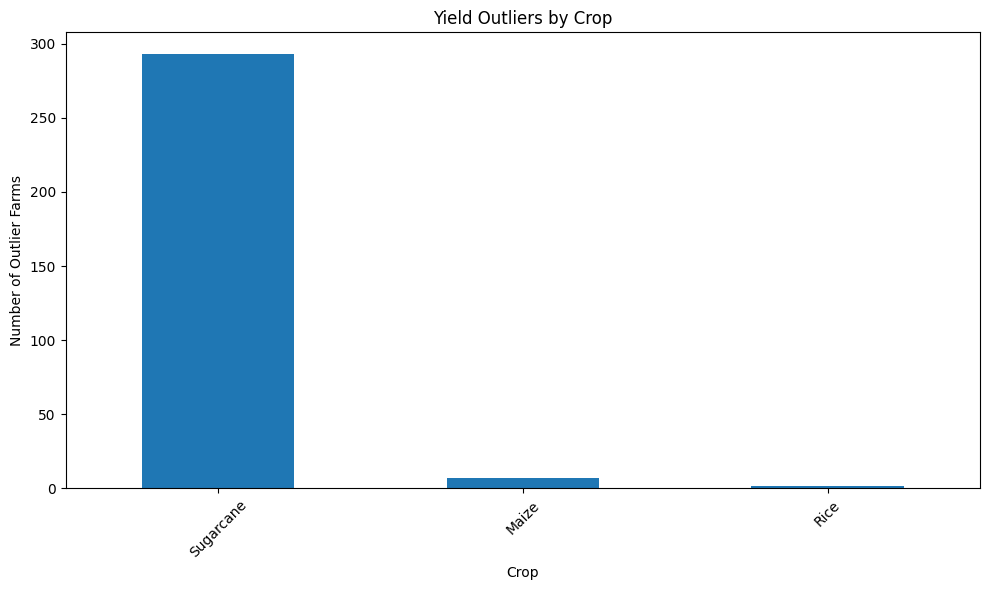

In [159]:
plt.figure(figsize=(10, 6))

yield_outlier_crop.plot(kind='bar')

plt.title('Yield Outliers by Crop')
plt.xlabel('Crop')
plt.ylabel('Number of Outlier Farms')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [160]:
anomaly_columns = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Soil_Moisture_pct',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Water_Used_m3',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Profit_INR',
    'Disease_Pest_Risk_pct'
]

df_anomaly = df_clean.copy()

df_anomaly['Anomaly_Count'] = 0

for column in anomaly_columns:
    Q1 = df_anomaly[column].quantile(0.25)
    Q3 = df_anomaly[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_anomaly['Anomaly_Count'] += (
        (df_anomaly[column] < lower) |
        (df_anomaly[column] > upper)
    ).astype(int)

display(
    df_anomaly[
        [
            'Farm_ID',
            'State',
            'District',
            'Crop',
            'Season',
            'Anomaly_Count'
        ]
    ]
    .sort_values('Anomaly_Count', ascending=False)
    .head(20)
)

,Farm_ID,State,District,Crop,Season,Anomaly_Count
3501,SF13502,Tamil Nadu,Erode,Sugarcane,Rabi,5
1194,SF11195,Madhya Pradesh,Warangal,Sugarcane,Kharif,5
1197,SF11198,Karnataka,Rajkot,Sugarcane,Kharif,4
3464,SF13465,Telangana,Krishna,Sugarcane,Kharif,4
990,SF10991,Madhya Pradesh,Rajkot,Sugarcane,Rabi,4
862,SF10863,Maharashtra,Raichur,Sugarcane,Rabi,4
303,SF10304,Tamil Nadu,Raichur,Sugarcane,Zaid,4
3425,SF13426,Madhya Pradesh,Rajkot,Sugarcane,Kharif,4
1538,SF11539,Gujarat,Raichur,Sugarcane,Kharif,4
1663,SF11664,Tamil Nadu,Ludhiana,Sugarcane,Rabi,4


In [161]:
high_anomaly_farms = df_anomaly[
    df_anomaly['Anomaly_Count'] >= 3
].copy()

print(
    f"Number of farms with 3 or more anomalous variables: "
    f"{len(high_anomaly_farms)}"
)

display(
    high_anomaly_farms[
        [
            'Farm_ID',
            'State',
            'District',
            'Crop',
            'Season',
            'Yield_Tonnes_Ha',
            'Water_Used_m3',
            'Profit_INR',
            'Disease_Pest_Risk_pct',
            'Anomaly_Count'
        ]
    ].head(20)
)

Number of farms with 3 or more anomalous variables: 171


,Farm_ID,State,District,Crop,Season,Yield_Tonnes_Ha,Water_Used_m3,Profit_INR,Disease_Pest_Risk_pct,Anomaly_Count
75,SF10076,Maharashtra,Guntur,Sugarcane,Kharif,62.58,23608,1675730,58.80,4
92,SF10093,Gujarat,Guntur,Sugarcane,Kharif,70.23,18596,2427692,51.90,4
113,SF10114,Tamil Nadu,Rajkot,Sugarcane,Rabi,58.06,27123,2324331,64.20,4
154,SF10155,Telangana,Ludhiana,Sugarcane,Kharif,47.88,21550,798280,54.40,4
222,SF10223,Maharashtra,Nashik,Sugarcane,Rabi,72.54,12436,2578433,58.00,3
253,SF10254,Tamil Nadu,Ludhiana,Sugarcane,Zaid,62.76,10283,952081,58.70,3
270,SF10271,Punjab,Warangal,Sugarcane,Rabi,69.71,13059,1263352,52.80,3
298,SF10299,Punjab,Erode,Sugarcane,Kharif,71.83,14945,1528473,52.60,3
301,SF10302,Punjab,Krishna,Sugarcane,Kharif,45.71,25870,1283142,51.80,4
303,SF10304,Tamil Nadu,Raichur,Sugarcane,Zaid,38.78,22104,934612,46.00,4


## 16.16 Outlier & Anomaly Analysis — Key Findings

The IQR method was used to identify potential outliers in important
agricultural variables.

The analysis examined environmental conditions, resource usage,
productivity and economic performance.

### Major observations

1. Yield outliers represent farms with unusually high or low productivity
   compared with the overall dataset.

2. Profit outliers can reveal farms with exceptionally high returns or
   unusually large losses.

3. Negative-profit farms represent an important economic anomaly because
   production costs and market returns may not be favorable for those farms.

4. Water usage outliers may indicate farms with unusually high resource
   consumption and therefore require investigation from a water-efficiency
   perspective.

5. Environmental outliers can represent unusual rainfall, temperature,
   humidity or soil-moisture conditions.

6. Anomaly counts help identify farms that simultaneously exhibit unusual
   values across multiple variables.

### Important Note

An outlier is not automatically an incorrect record.

An unusual observation may represent a genuine agricultural condition,
exceptional farm performance, unusual weather, crop-specific behavior,
or a potential data-quality issue.

Therefore, outliers should be investigated before removing them.

The analysis supports the project's objective of detecting unusual
patterns and identifying observations that deserve further investigation.

## 17. Regional, Crop & Irrigation-wise Comparative Analysis

The objective of this section is to compare agricultural performance
across different geographical and farming categories.

The analysis focuses on:

- State-wise performance
- District-wise performance
- Crop-wise performance
- Irrigation method-wise performance
- Seed quality-wise performance
- Seasonal performance within different groups

The major performance indicators considered are:

- Yield
- Production
- Profit
- Revenue
- Water Usage
- Water Efficiency
- Disease/Pest Risk

This analysis helps identify high-performing and low-performing groups
and provides evidence for targeted agricultural recommendations.

In [162]:
state_summary = (
    df_clean
    .groupby('State')
    .agg(
        Farms=('Farm_ID', 'count'),
        Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
        Total_Production=('Production_Tonnes', 'sum'),
        Avg_Profit=('Profit_INR', 'mean'),
        Avg_Revenue=('Revenue_INR', 'mean'),
        Avg_Water_Used=('Water_Used_m3', 'mean'),
        Avg_Water_Efficiency=(
            'Water_Efficiency_t_per_1000m3',
            'mean'
        ),
        Avg_Disease_Risk=('Disease_Pest_Risk_pct', 'mean')
    )
    .sort_values('Avg_Yield', ascending=False)
)

display(state_summary.round(2))

,Farms,Avg_Yield,Total_Production,Avg_Profit,Avg_Revenue,Avg_Water_Used,Avg_Water_Efficiency,Avg_Disease_Risk
State,,,,,,,,
Punjab,484,6.12,25280.82,136025.64,686225.70,6565.92,5.62,46.00
Karnataka,489,5.73,23341.30,119422.34,653426.18,6414.33,5.56,46.06
Gujarat,488,5.70,23586.01,117568.24,654692.86,6142.50,5.58,45.95
Telangana,516,5.08,20255.16,108829.62,628784.53,5801.83,5.46,46.36
Maharashtra,512,5.03,22519.83,135428.86,650032.67,5968.08,5.28,46.44
Madhya Pradesh,497,5.03,18667.08,86840.76,597558.36,5663.92,5.27,47.08
Tamil Nadu,485,4.90,19807.58,117744.75,629093.42,5775.22,5.31,46.28
Andhra Pradesh,529,4.65,19527.06,73453.53,606663.66,6058.38,5.03,46.72


plt.figure(figsize=(12, 6))

state_summary['Avg_Yield'].sort_values().plot(kind='barh')

plt.title('Average Yield by State')
plt.xlabel('Average Yield (Tonnes/Ha)')
plt.ylabel('State')

plt.tight_layout()
plt.show()

### Interpretation

The state-wise yield comparison identifies geographical regions
with relatively high and low average productivity.

Higher average yield may indicate favorable combinations of:

- Crop selection
- Soil conditions
- Irrigation
- Farming practices
- Resource availability
- Environmental conditions

However, state-level differences should be interpreted together with
crop composition and seasonal distribution.

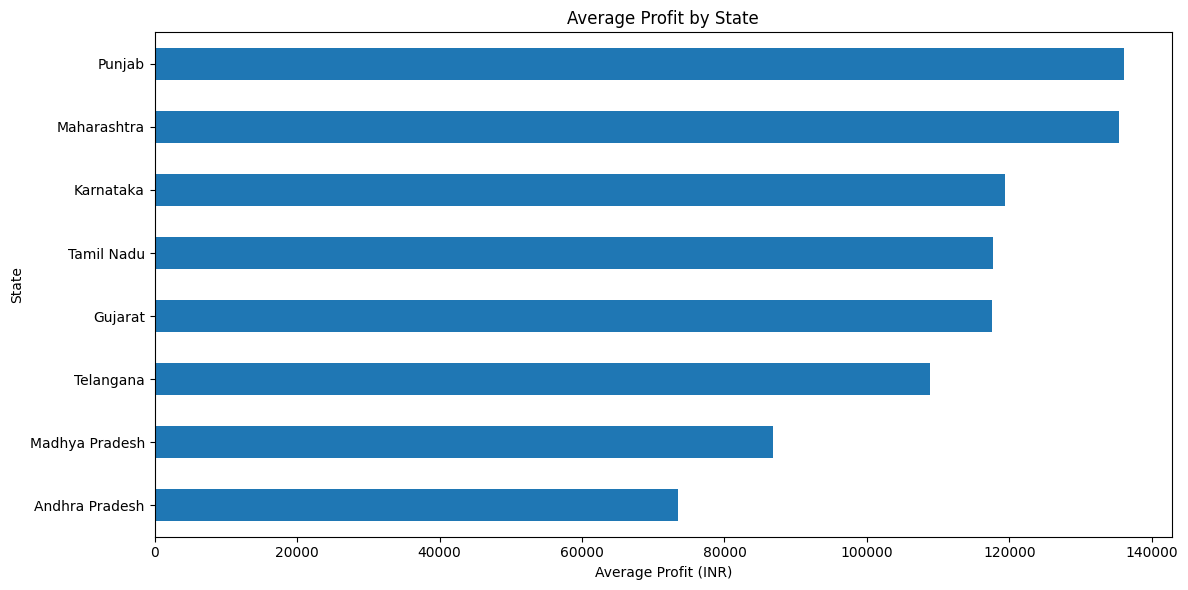

In [163]:
plt.figure(figsize=(12, 6))

state_summary['Avg_Profit'].sort_values().plot(kind='barh')

plt.title('Average Profit by State')
plt.xlabel('Average Profit (INR)')
plt.ylabel('State')

plt.tight_layout()
plt.show()

In [164]:
best_state_yield = state_summary['Avg_Yield'].idxmax()
worst_state_yield = state_summary['Avg_Yield'].idxmin()

best_state_profit = state_summary['Avg_Profit'].idxmax()
worst_state_profit = state_summary['Avg_Profit'].idxmin()

print(f"Highest average yield: {best_state_yield}")
print(f"Lowest average yield: {worst_state_yield}")

print(f"Highest average profit: {best_state_profit}")
print(f"Lowest average profit: {worst_state_profit}")


Highest average yield: Punjab
Lowest average yield: Andhra Pradesh
Highest average profit: Punjab
Lowest average profit: Andhra Pradesh


## 17.5 District-wise Performance

District-level analysis provides a more detailed geographical view
than state-level analysis.

It can reveal local variations that may be hidden when observations
are aggregated at the state level.

In [165]:
district_summary = (
    df_clean
    .groupby(['State', 'District'])
    .agg(
        Farms=('Farm_ID', 'count'),
        Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
        Total_Production=('Production_Tonnes', 'sum'),
        Avg_Profit=('Profit_INR', 'mean'),
        Avg_Water_Used=('Water_Used_m3', 'mean'),
        Avg_Water_Efficiency=(
            'Water_Efficiency_t_per_1000m3',
            'mean'
        ),
        Avg_Disease_Risk=('Disease_Pest_Risk_pct', 'mean')
    )
    .sort_values('Avg_Yield', ascending=False)
)

display(district_summary.round(2))

,,Farms,Avg_Yield,Total_Production,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency,Avg_Disease_Risk
State,District,,,,,,,
Karnataka,Nalgonda,52,12.03,5191.45,167340.94,8939.73,9.16,47.12
Gujarat,Indore,34,9.85,2037.23,42073.32,5968.12,6.79,48.81
Karnataka,Rajkot,58,9.40,4267.42,100128.17,5962.57,7.41,45.67
Punjab,Warangal,57,8.98,4983.82,301710.33,6921.75,7.48,49.49
Madhya Pradesh,Warangal,62,8.41,3878.78,213645.69,6542.10,6.73,48.15
...,...,...,...,...,...,...,...,...
Tamil Nadu,Nashik,41,2.86,715.20,75510.12,5334.88,3.97,47.51
Punjab,Raichur,43,2.78,1227.23,207547.21,5765.70,4.28,46.69
Maharashtra,Erode,47,2.65,900.78,41703.74,4851.83,3.44,46.35


In [166]:
print("Top 10 Districts by Average Yield")

display(
    district_summary
    .sort_values('Avg_Yield', ascending=False)
    .head(10)
    .round(2)
)

Top 10 Districts by Average Yield


,,Farms,Avg_Yield,Total_Production,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency,Avg_Disease_Risk
State,District,,,,,,,
Karnataka,Nalgonda,52,12.03,5191.45,167340.94,8939.73,9.16,47.12
Gujarat,Indore,34,9.85,2037.23,42073.32,5968.12,6.79,48.81
Karnataka,Rajkot,58,9.40,4267.42,100128.17,5962.57,7.41,45.67
Punjab,Warangal,57,8.98,4983.82,301710.33,6921.75,7.48,49.49
Madhya Pradesh,Warangal,62,8.41,3878.78,213645.69,6542.10,6.73,48.15
Gujarat,Rajkot,48,8.13,4163.90,230545.21,7246.71,7.37,46.67
Telangana,Raichur,35,7.87,1607.60,186997.34,4741.94,7.28,48.71
Punjab,Ludhiana,48,7.78,3088.74,62368.90,7071.71,6.65,47.07
Madhya Pradesh,Ludhiana,57,7.74,2829.01,78735.12,6349.40,7.12,46.04


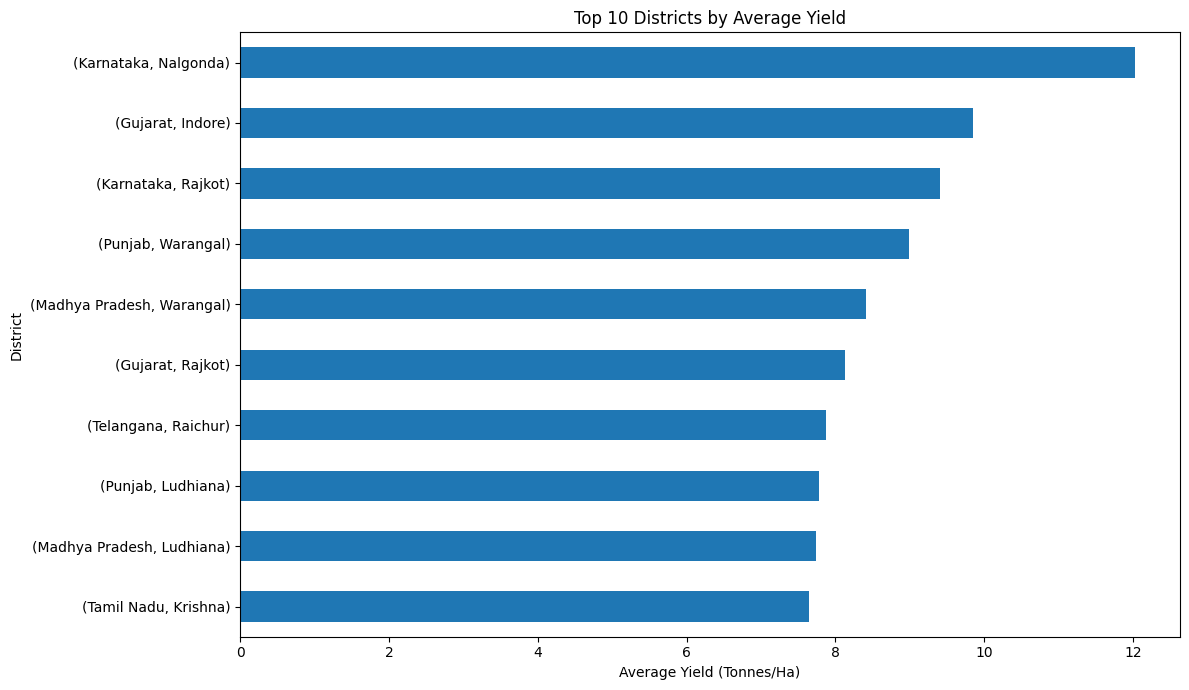

In [167]:
plt.figure(figsize=(12, 7))

top_districts = (
    district_summary
    .sort_values('Avg_Yield', ascending=False)
    .head(10)
    .sort_values('Avg_Yield')
)

top_districts['Avg_Yield'].plot(kind='barh')

plt.title('Top 10 Districts by Average Yield')
plt.xlabel('Average Yield (Tonnes/Ha)')
plt.ylabel('District')

plt.tight_layout()
plt.show()

## 17.7 Crop-wise Performance

Different crops have different environmental requirements,
resource requirements, production levels and market values.

Crop-wise analysis helps identify:

- High-yielding crops
- High-profit crops
- Water-intensive crops
- Water-efficient crops
- Crops with higher disease/pest risk

In [168]:
crop_summary = (
    df_clean
    .groupby('Crop')
    .agg(
        Farms=('Farm_ID', 'count'),
        Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
        Total_Production=('Production_Tonnes', 'sum'),
        Avg_Profit=('Profit_INR', 'mean'),
        Avg_Revenue=('Revenue_INR', 'mean'),
        Avg_Cost=('Total_Cost_INR', 'mean'),
        Avg_Water_Used=('Water_Used_m3', 'mean'),
        Avg_Water_Efficiency=(
            'Water_Efficiency_t_per_1000m3',
            'mean'
        ),
        Avg_Disease_Risk=('Disease_Pest_Risk_pct', 'mean')
    )
    .sort_values('Avg_Yield', ascending=False)
)

display(crop_summary.round(2))

,Farms,Avg_Yield,Total_Production,Avg_Profit,Avg_Revenue,Avg_Cost,Avg_Water_Used,Avg_Water_Efficiency,Avg_Disease_Risk
Crop,,,,,,,,,
Sugarcane,305,46.94,119685.97,817187.99,1371980.11,554792.13,13897.70,30.48,45.40
Maize,551,2.72,12001.40,-83978.33,457067.99,541046.32,4377.78,5.60,45.54
Rice,690,2.44,13309.15,-102213.50,423615.26,525828.76,10920.22,1.95,46.50
Wheat,614,2.11,10348.30,-123398.34,400104.89,523503.22,4054.40,4.63,47.85
Chilli,412,1.54,5101.75,750878.34,1276777.23,525898.89,4577.47,2.95,46.06
Groundnut,424,1.32,4094.07,44858.12,542935.50,498077.38,3459.54,3.15,46.29
Cotton,508,1.23,4773.10,124546.92,639423.08,514876.17,5410.86,1.94,45.97
Pulses,496,0.92,3671.10,-4238.05,528465.87,532703.92,2833.67,2.90,46.57


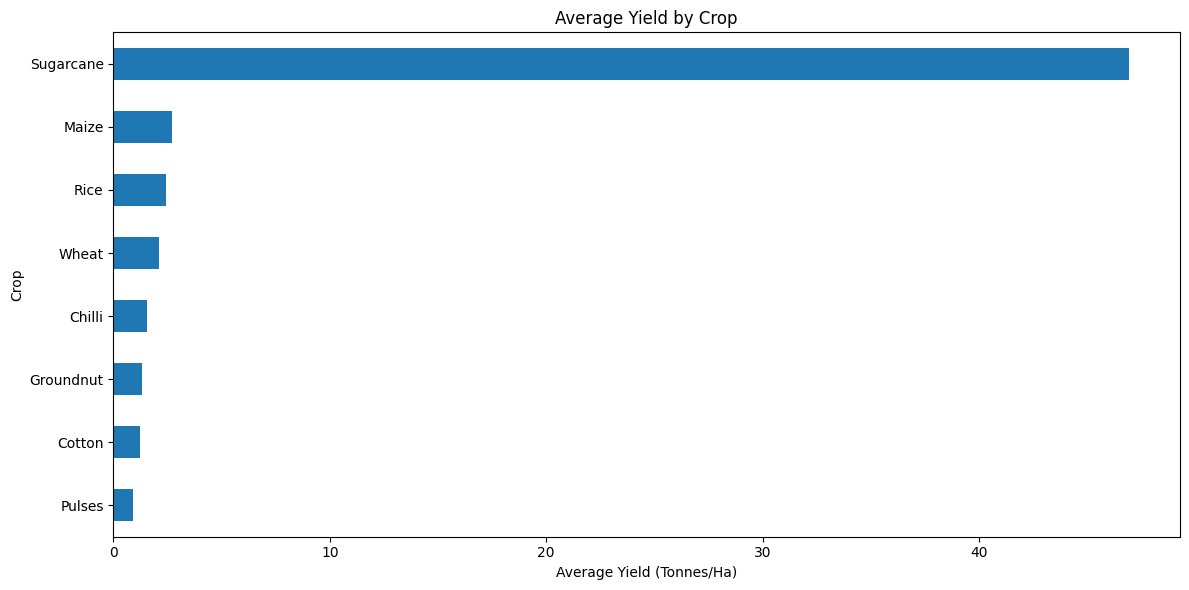

In [169]:
plt.figure(figsize=(12, 6))

crop_summary['Avg_Yield'].sort_values().plot(kind='barh')

plt.title('Average Yield by Crop')
plt.xlabel('Average Yield (Tonnes/Ha)')
plt.ylabel('Crop')

plt.tight_layout()
plt.show()

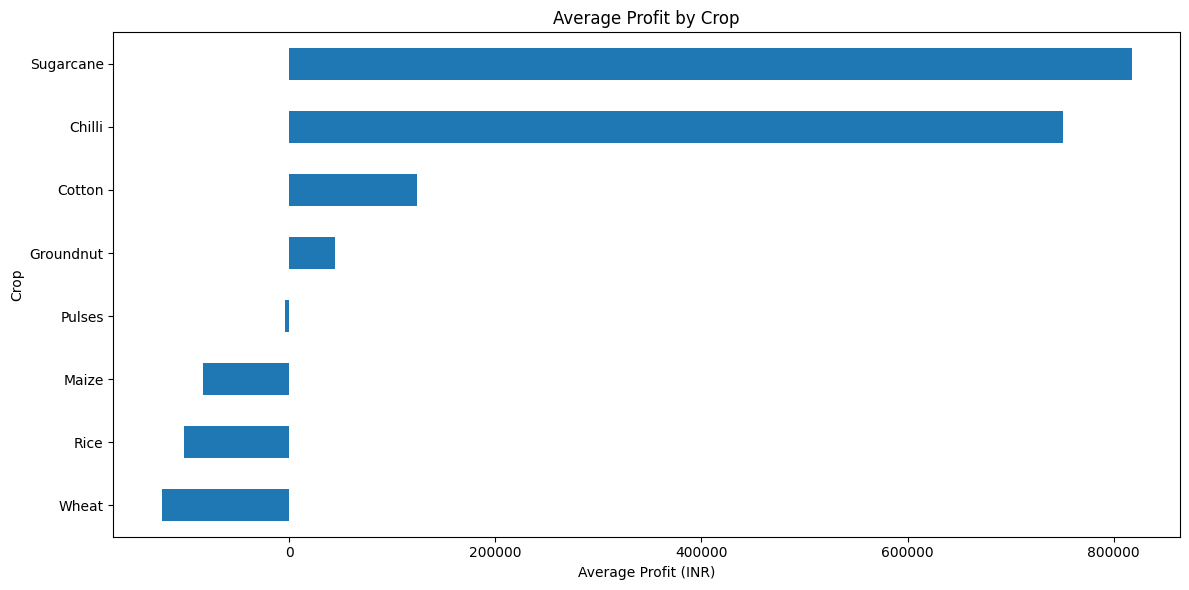

In [170]:
plt.figure(figsize=(12, 6))

crop_summary['Avg_Profit'].sort_values().plot(kind='barh')

plt.title('Average Profit by Crop')
plt.xlabel('Average Profit (INR)')
plt.ylabel('Crop')

plt.tight_layout()
plt.show()

In [171]:

print("Top Crops by Average Profit")

display(
    crop_summary
    .sort_values('Avg_Profit', ascending=False)
    [['Farms', 'Avg_Yield', 'Avg_Profit',
      'Avg_Water_Used', 'Avg_Water_Efficiency']]
    .head(10)
    .round(2)
)

Top Crops by Average Profit


,Farms,Avg_Yield,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency
Crop,,,,,
Sugarcane,305,46.94,817187.99,13897.70,30.48
Chilli,412,1.54,750878.34,4577.47,2.95
Cotton,508,1.23,124546.92,5410.86,1.94
Groundnut,424,1.32,44858.12,3459.54,3.15
Pulses,496,0.92,-4238.05,2833.67,2.90
Maize,551,2.72,-83978.33,4377.78,5.60
Rice,690,2.44,-102213.50,10920.22,1.95
Wheat,614,2.11,-123398.34,4054.40,4.63


In [172]:

water_efficient_crops = (
    crop_summary
    .sort_values(
        'Avg_Water_Efficiency',
        ascending=False
    )
)

display(
    water_efficient_crops[
        [
            'Farms',
            'Avg_Yield',
            'Avg_Water_Used',
            'Avg_Water_Efficiency',
            'Avg_Profit'
        ]
    ].round(2)
)

,Farms,Avg_Yield,Avg_Water_Used,Avg_Water_Efficiency,Avg_Profit
Crop,,,,,
Sugarcane,305,46.94,13897.70,30.48,817187.99
Maize,551,2.72,4377.78,5.60,-83978.33
Wheat,614,2.11,4054.40,4.63,-123398.34
Groundnut,424,1.32,3459.54,3.15,44858.12
Chilli,412,1.54,4577.47,2.95,750878.34
Pulses,496,0.92,2833.67,2.90,-4238.05
Rice,690,2.44,10920.22,1.95,-102213.50
Cotton,508,1.23,5410.86,1.94,124546.92


plt.figure(figsize=(12, 6))

water_efficient_crops[
    'Avg_Water_Efficiency'
].sort_values().plot(kind='barh')

plt.title('Water Efficiency by Crop')
plt.xlabel('Water Efficiency (Tonnes per 1000 m³)')
plt.ylabel('Crop')

plt.tight_layout()
plt.show()


## 17.12 Irrigation Method-wise Analysis

Irrigation is an important factor in agricultural resource management.

The dataset contains different irrigation methods.

The performance of each irrigation method is compared using:

- Yield
- Profit
- Water usage
- Water efficiency
- Production
- Disease/Pest Risk

In [173]:
irrigation_summary = (
    df_clean
    .groupby('Irrigation_Method')
    .agg(
        Farms=('Farm_ID', 'count'),
        Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
        Total_Production=('Production_Tonnes', 'sum'),
        Avg_Profit=('Profit_INR', 'mean'),
        Avg_Water_Used=('Water_Used_m3', 'mean'),
        Avg_Water_Efficiency=(
            'Water_Efficiency_t_per_1000m3',
            'mean'
        ),
        Avg_Disease_Risk=('Disease_Pest_Risk_pct', 'mean')
    )
    .sort_values('Avg_Yield', ascending=False)
)

display(irrigation_summary.round(2))

,Farms,Avg_Yield,Total_Production,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency,Avg_Disease_Risk
Irrigation_Method,,,,,,,
Drip,915,6.62,53064.77,219626.00,5918.75,6.27,45.79
Sprinkler,734,5.19,31075.82,91121.08,6208.26,4.67,46.48
Flood,1310,4.90,50738.41,73354.02,8026.47,3.44,46.60
Rainfed,1041,4.61,38105.84,79050.37,3549.55,7.56,46.49


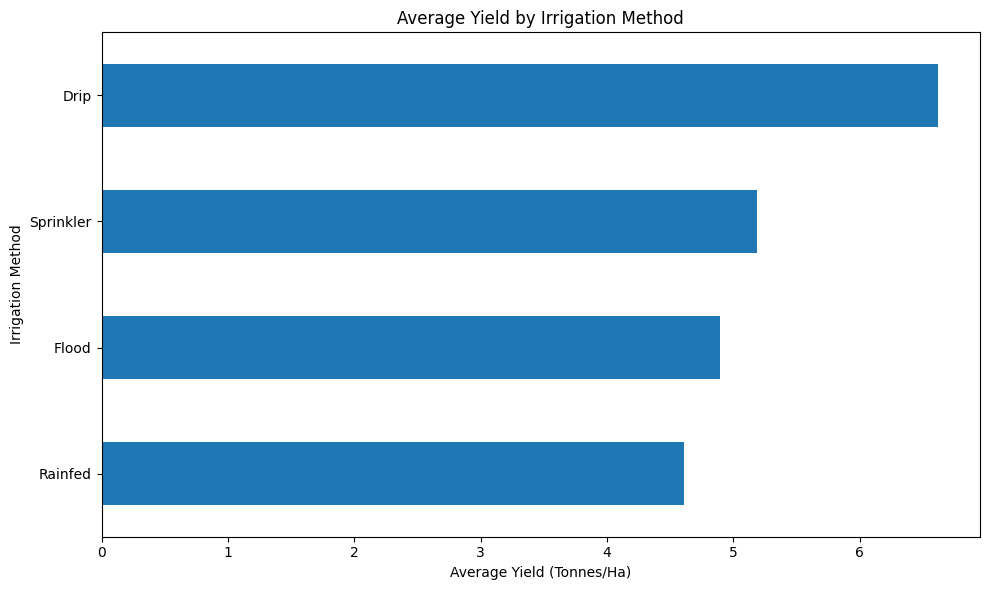

In [174]:
plt.figure(figsize=(10, 6))

irrigation_summary['Avg_Yield'].sort_values().plot(
    kind='barh'
)

plt.title('Average Yield by Irrigation Method')
plt.xlabel('Average Yield (Tonnes/Ha)')
plt.ylabel('Irrigation Method')

plt.tight_layout()
plt.show()

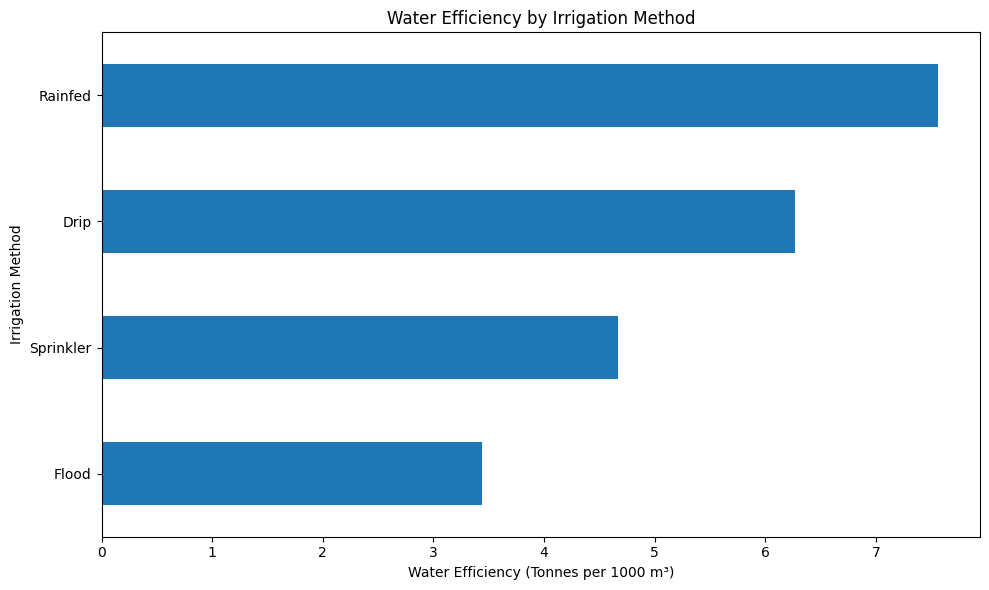

In [175]:
plt.figure(figsize=(10, 6))

irrigation_summary[
    'Avg_Water_Efficiency'
].sort_values().plot(kind='barh')

plt.title('Water Efficiency by Irrigation Method')
plt.xlabel('Water Efficiency (Tonnes per 1000 m³)')
plt.ylabel('Irrigation Method')

plt.tight_layout()
plt.show()


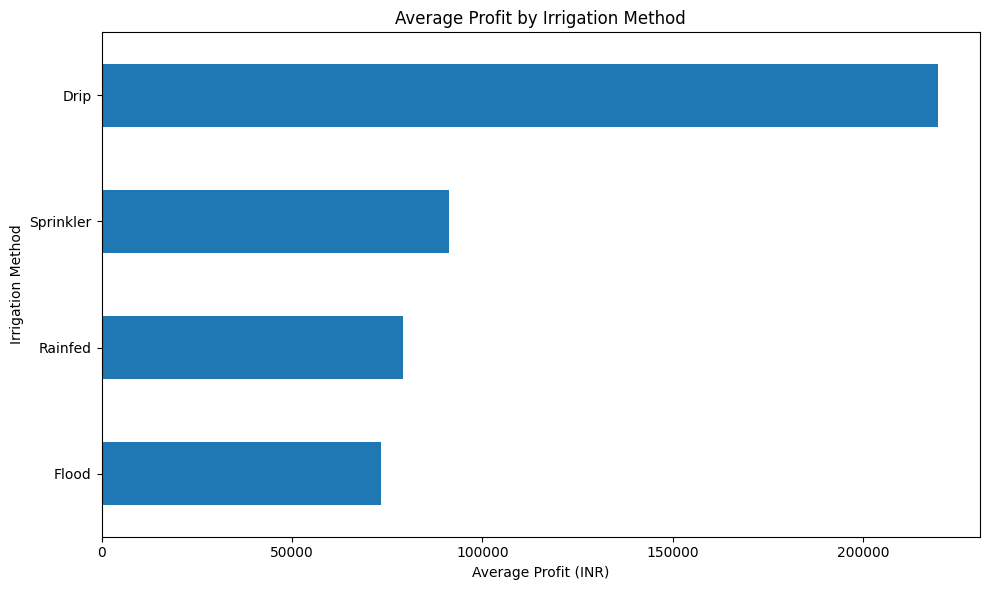

In [176]:
plt.figure(figsize=(10, 6))

irrigation_summary[
    'Avg_Profit'
].sort_values().plot(kind='barh')

plt.title('Average Profit by Irrigation Method')
plt.xlabel('Average Profit (INR)')
plt.ylabel('Irrigation Method')

plt.tight_layout()
plt.show()

## 17.16 Seed Quality Analysis

Seed quality can influence crop productivity.

The dataset contains a Seed_Quality category, allowing us to compare
agricultural performance across different seed-quality levels.

In [177]:
seed_summary = (
    df_clean
    .groupby('Seed_Quality_Score')
    .agg(
        Farms=('Farm_ID', 'count'),
        Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
        Avg_Profit=('Profit_INR', 'mean'),
        Avg_Water_Used=('Water_Used_m3', 'mean'),
        Avg_Water_Efficiency=(
            'Water_Efficiency_t_per_1000m3',
            'mean'
        ),
        Avg_Disease_Risk=('Disease_Pest_Risk_pct', 'mean')
    )
    .sort_values('Avg_Yield', ascending=False)
)

display(seed_summary.round(2))

,Farms,Avg_Yield,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency,Avg_Disease_Risk
Seed_Quality_Score,,,,,,
0.77,98,9.37,186508.85,5863.57,7.83,47.76
1.00,73,9.31,293396.92,6858.12,7.94,45.97
0.76,99,8.84,245728.46,6918.70,7.30,45.00
0.82,123,8.11,185563.99,6962.20,6.43,48.01
0.72,107,7.86,221407.97,6746.88,7.60,48.22
0.90,98,6.93,161690.39,5877.53,6.50,44.02
0.83,122,6.49,96849.87,7106.69,5.51,46.13
0.92,113,6.39,136511.46,7026.04,5.42,46.57
0.98,122,6.22,146761.30,5989.84,6.50,46.68


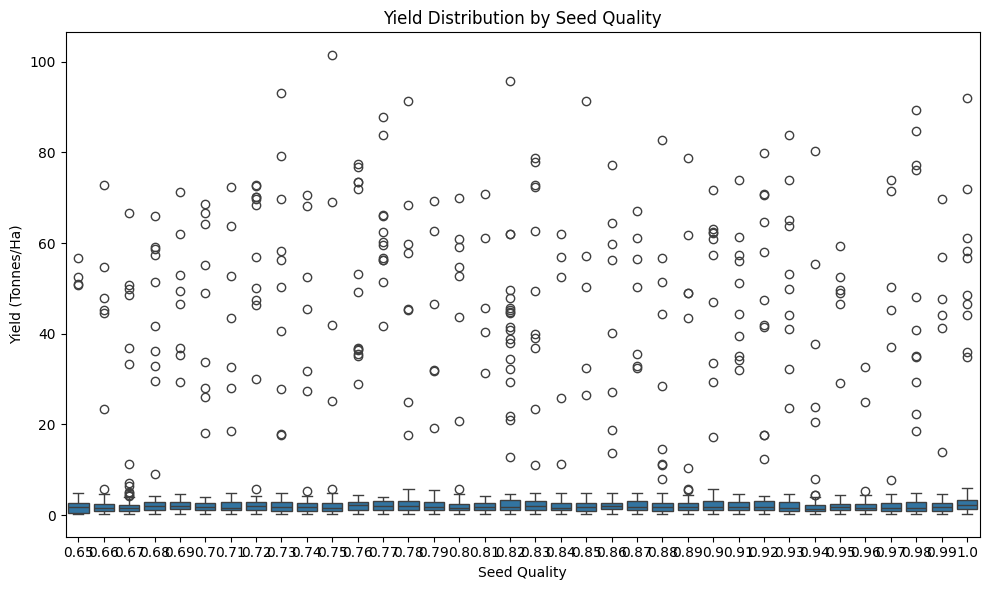

In [178]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x='Seed_Quality_Score',
    y='Yield_Tonnes_Ha'
)

plt.title('Yield Distribution by Seed Quality')
plt.xlabel('Seed Quality')
plt.ylabel('Yield (Tonnes/Ha)')

plt.tight_layout()
plt.show()

In [179]:
crop_season_yield = pd.pivot_table(
    df_clean,
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

display(crop_season_yield.round(2))

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.18
Cotton,1.37,1.19,0.95
Groundnut,1.48,1.22,1.04
Maize,2.97,2.61,2.30
Pulses,1.04,0.87,0.65
Rice,2.71,2.33,1.90
Sugarcane,53.46,43.94,38.42
Wheat,2.26,2.06,1.75


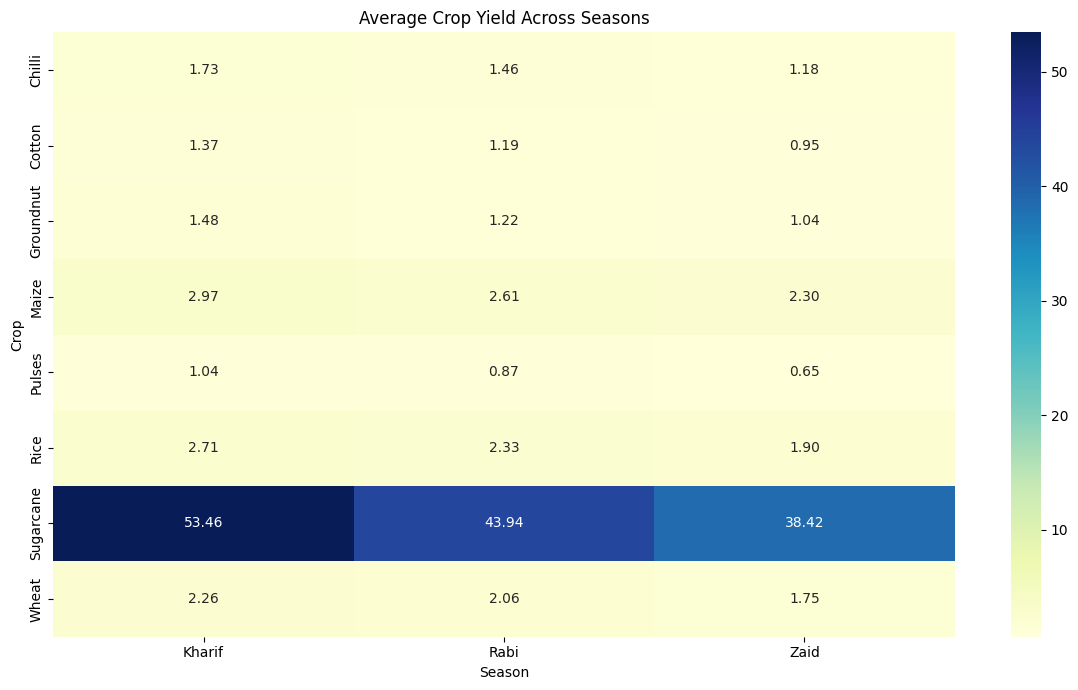

In [180]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Average Crop Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('Crop')

plt.tight_layout()
plt.show()

In [181]:
irrigation_season_yield = pd.pivot_table(
    df_clean,
    values='Yield_Tonnes_Ha',
    index='Irrigation_Method',
    columns='Season',
    aggfunc='mean'
)

display(irrigation_season_yield.round(2))

Season,Kharif,Rabi,Zaid
Irrigation_Method,,,
Drip,7.26,6.21,5.85
Flood,5.00,5.10,4.03
Rainfed,5.72,3.94,3.06
Sprinkler,4.67,5.36,6.17


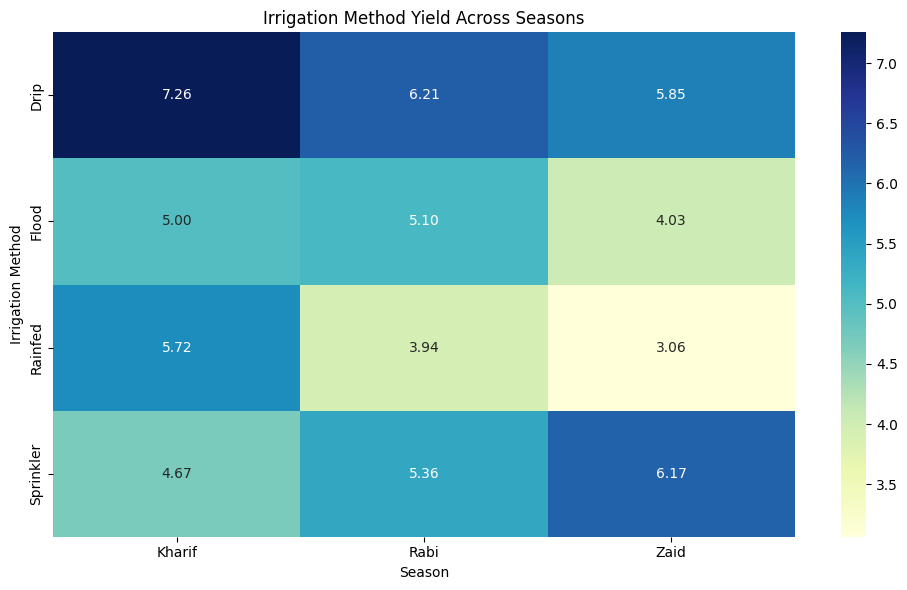

In [182]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    irrigation_season_yield,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Irrigation Method Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('Irrigation Method')

plt.tight_layout()
plt.show()

In [183]:
state_crop_yield = pd.pivot_table(
    df_clean,
    values='Yield_Tonnes_Ha',
    index='State',
    columns='Crop',
    aggfunc='mean'
)

display(state_crop_yield.round(2))

Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
State,,,,,,,,
Andhra Pradesh,1.42,1.19,1.32,2.80,0.92,2.54,50.26,1.88
Gujarat,1.64,1.20,1.28,2.51,0.98,2.34,48.17,1.97
Karnataka,1.45,1.30,1.28,2.77,0.90,2.35,44.51,2.24
Madhya Pradesh,1.52,1.26,1.10,2.52,0.86,2.42,47.48,2.22
Maharashtra,1.65,1.15,1.36,2.68,0.98,2.32,46.96,2.16
Punjab,1.48,1.23,1.50,2.91,0.94,2.43,44.23,2.02
Tamil Nadu,1.60,1.20,1.36,2.81,0.79,2.32,49.62,2.21
Telangana,1.58,1.29,1.38,2.75,0.97,2.75,46.47,2.19


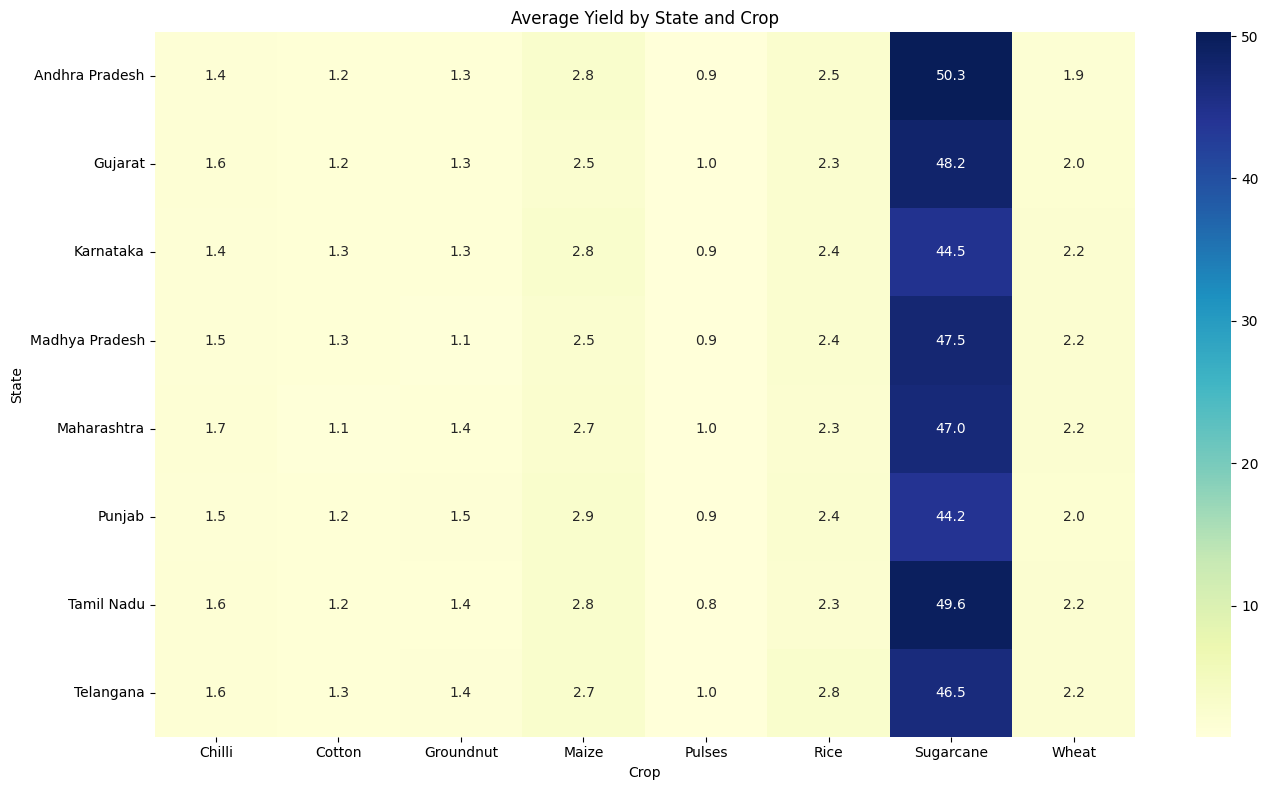

In [184]:
plt.figure(figsize=(14, 8))

sns.heatmap(
    state_crop_yield,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu'
)

plt.title('Average Yield by State and Crop')
plt.xlabel('Crop')
plt.ylabel('State')

plt.tight_layout()
plt.show()

In [185]:
state_summary = (
    df_clean
    .groupby('State')
    .agg(
        Farms=('Farm_ID', 'count'),
        Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
        Total_Production=('Production_Tonnes', 'sum'),
        Avg_Profit=('Profit_INR', 'mean'),
        Avg_Revenue=('Revenue_INR', 'mean'),
        Avg_Water_Used=('Water_Used_m3', 'mean'),
        Avg_Water_Efficiency=(
            'Water_Efficiency_t_per_1000m3',
            'mean'
        ),
        Avg_Disease_Risk=('Disease_Pest_Risk_pct', 'mean')
    )
    .sort_values('Avg_Yield', ascending=False)
)

district_summary = (
    df_clean
    .groupby(['State', 'District'])
    .agg(
        Farms=('Farm_ID', 'count'),
        Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
        Total_Production=('Production_Tonnes', 'sum'),
        Avg_Profit=('Profit_INR', 'mean'),
        Avg_Water_Used=('Water_Used_m3', 'mean'),
        Avg_Water_Efficiency=(
            'Water_Efficiency_t_per_1000m3',
            'mean'
        ),
        Avg_Disease_Risk=('Disease_Pest_Risk_pct', 'mean')
    )
    .sort_values('Avg_Yield', ascending=False)
)

crop_summary = (
    df_clean
    .groupby('Crop')
    .agg(
        Farms=('Farm_ID', 'count'),
        Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
        Total_Production=('Production_Tonnes', 'sum'),
        Avg_Profit=('Profit_INR', 'mean'),
        Avg_Revenue=('Revenue_INR', 'mean'),
        Avg_Cost=('Total_Cost_INR', 'mean'),
        Avg_Water_Used=('Water_Used_m3', 'mean'),
        Avg_Water_Efficiency=(
            'Water_Efficiency_t_per_1000m3',
            'mean'
        ),
        Avg_Disease_Risk=('Disease_Pest_Risk_pct', 'mean')
    )
    .sort_values('Avg_Yield', ascending=False)
)

irrigation_summary = (
    df_clean
    .groupby('Irrigation_Method')
    .agg(
        Farms=('Farm_ID', 'count'),
        Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
        Total_Production=('Production_Tonnes', 'sum'),
        Avg_Profit=('Profit_INR', 'mean'),
        Avg_Water_Used=('Water_Used_m3', 'mean'),
        Avg_Water_Efficiency=(
            'Water_Efficiency_t_per_1000m3',
            'mean'
        ),
        Avg_Disease_Risk=('Disease_Pest_Risk_pct', 'mean')
    )
    .sort_values('Avg_Yield', ascending=False)
)

seed_summary = (
    df_clean
    .groupby('Seed_Quality_Score')
    .agg(
        Farms=('Farm_ID', 'count'),
        Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
        Avg_Profit=('Profit_INR', 'mean'),
        Avg_Water_Used=('Water_Used_m3', 'mean'),
        Avg_Water_Efficiency=(
            'Water_Efficiency_t_per_1000m3',
            'mean'
        ),
        Avg_Disease_Risk=('Disease_Pest_Risk_pct', 'mean')
    )
    .sort_values('Avg_Yield', ascending=False)
)

best_groups = {
    'Best State by Yield': state_summary['Avg_Yield'].idxmax(),
    'Best District by Yield': district_summary['Avg_Yield'].idxmax(),
    'Best Crop by Yield': crop_summary['Avg_Yield'].idxmax(),
    'Best Irrigation Method by Yield': irrigation_summary['Avg_Yield'].idxmax(),
    'Best Seed Quality by Yield': seed_summary['Avg_Yield'].idxmax(),
    'Best Crop by Profit': crop_summary['Avg_Profit'].idxmax(),
    'Best Irrigation Method by Water Efficiency':
        irrigation_summary['Avg_Water_Efficiency'].idxmax()
}

for key, value in best_groups.items():
    print(f"{key}: {value}")

Best State by Yield: Punjab
Best District by Yield: ('Karnataka', 'Nalgonda')
Best Crop by Yield: Sugarcane
Best Irrigation Method by Yield: Drip
Best Seed Quality by Yield: 0.77
Best Crop by Profit: Sugarcane
Best Irrigation Method by Water Efficiency: Rainfed


In [186]:
state_summary = (
    df_clean
    .groupby('State')
    .agg(
        Farms=('Farm_ID', 'count'),
        Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
        Total_Production=('Production_Tonnes', 'sum'),
        Avg_Profit=('Profit_INR', 'mean'),
        Avg_Revenue=('Revenue_INR', 'mean'),
        Avg_Water_Used=('Water_Used_m3', 'mean'),
        Avg_Water_Efficiency=(
            'Water_Efficiency_t_per_1000m3',
            'mean'
        ),
        Avg_Disease_Risk=('Disease_Pest_Risk_pct', 'mean')
    )
    .sort_values('Avg_Yield', ascending=False)
)

district_summary = (
    df_clean
    .groupby(['State', 'District'])
    .agg(
        Farms=('Farm_ID', 'count'),
        Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
        Total_Production=('Production_Tonnes', 'sum'),
        Avg_Profit=('Profit_INR', 'mean'),
        Avg_Water_Used=('Water_Used_m3', 'mean'),
        Avg_Water_Efficiency=(
            'Water_Efficiency_t_per_1000m3',
            'mean'
        ),
        Avg_Disease_Risk=('Disease_Pest_Risk_pct', 'mean')
    )
    .sort_values('Avg_Yield', ascending=False)
)

crop_summary = (
    df_clean
    .groupby('Crop')
    .agg(
        Farms=('Farm_ID', 'count'),
        Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
        Total_Production=('Production_Tonnes', 'sum'),
        Avg_Profit=('Profit_INR', 'mean'),
        Avg_Revenue=('Revenue_INR', 'mean'),
        Avg_Cost=('Total_Cost_INR', 'mean'),
        Avg_Water_Used=('Water_Used_m3', 'mean'),
        Avg_Water_Efficiency=(
            'Water_Efficiency_t_per_1000m3',
            'mean'
        ),
        Avg_Disease_Risk=('Disease_Pest_Risk_pct', 'mean')
    )
    .sort_values('Avg_Yield', ascending=False)
)

irrigation_summary = (
    df_clean
    .groupby('Irrigation_Method')
    .agg(
        Farms=('Farm_ID', 'count'),
        Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
        Total_Production=('Production_Tonnes', 'sum'),
        Avg_Profit=('Profit_INR', 'mean'),
        Avg_Water_Used=('Water_Used_m3', 'mean'),
        Avg_Water_Efficiency=(
            'Water_Efficiency_t_per_1000m3',
            'mean'
        ),
        Avg_Disease_Risk=('Disease_Pest_Risk_pct', 'mean')
    )
    .sort_values('Avg_Yield', ascending=False)
)

seed_summary = (
    df_clean
    .groupby('Seed_Quality_Score')
    .agg(
        Farms=('Farm_ID', 'count'),
        Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
        Avg_Profit=('Profit_INR', 'mean'),
        Avg_Water_Used=('Water_Used_m3', 'mean'),
        Avg_Water_Efficiency=(
            'Water_Efficiency_t_per_1000m3',
            'mean'
        ),
        Avg_Disease_Risk=('Disease_Pest_Risk_pct', 'mean')
    )
    .sort_values('Avg_Yield', ascending=False)
)

comparison_table = pd.DataFrame({
    'Category': [
        'State',
        'District',
        'Crop',
        'Irrigation Method',
        'Seed Quality'
    ],
    'Best Group by Average Yield': [
        state_summary['Avg_Yield'].idxmax(),
        district_summary['Avg_Yield'].idxmax(),
        crop_summary['Avg_Yield'].idxmax(),
        irrigation_summary['Avg_Yield'].idxmax(),
        seed_summary['Avg_Yield'].idxmax()
    ]
})

display(comparison_table)

,Category,Best Group by Average Yield
0,State,Punjab
1,District,"(Karnataka, Nalgonda)"
2,Crop,Sugarcane
3,Irrigation Method,Drip
4,Seed Quality,0.77


## 17.23 Regional, Crop & Irrigation Analysis — Key Findings

The comparative analysis provides a detailed view of agricultural
performance across geographical and farming categories.

### Regional Performance

State-wise and district-wise analysis reveals geographical differences
in yield, profitability, resource consumption and disease/pest risk.

### Crop Performance

Different crops show different productivity, profitability and water
efficiency characteristics. Therefore, crop selection can be an important
factor in improving farm performance.

### Irrigation Performance

Irrigation methods differ in their relationship with yield, water usage
and water efficiency. A method producing high yield does not necessarily
have the highest water efficiency.

### Seed Quality

Seed quality categories can be compared to determine whether better
quality seeds are associated with improved yield and profitability.

### Cross-Category Analysis

Crop × Season, Irrigation × Season and State × Crop analysis helps
identify combinations that perform particularly well or poorly.

These comparisons demonstrate that agricultural performance is influenced
by multiple interacting factors rather than season alone.

The results can therefore support more targeted recommendations based on
location, crop selection, irrigation strategy and farming practices.

# 18. Advanced Seasonal Pattern & Trend Analysis

This section performs an advanced analysis of seasonal agricultural
patterns by combining crop, season, state, irrigation, yield,
profitability, water efficiency, and disease/pest risk.

The objective is to identify the strongest and weakest combinations
and derive final evidence-based recommendations from the dataset.

In [187]:
crop_season_summary = (
    df_clean.groupby(['Crop', 'Season'])
    .agg(
        Farms=('Farm_ID', 'count'),
        Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
        Total_Production=('Production_Tonnes', 'sum'),
        Avg_Profit=('Profit_INR', 'mean'),
        Avg_Water_Used=('Water_Used_m3', 'mean'),
        Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
        Avg_Risk=('Disease_Pest_Risk_pct', 'mean')
    )
    .reset_index()
)

crop_season_summary.sort_values(
    'Avg_Yield',
    ascending=False
).head(15)

,Crop,Season,Farms,Avg_Yield,Total_Production,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency,Avg_Risk
18,Sugarcane,Kharif,125,53.46,55759.37,1000790.81,13689.51,36.00,54.02
19,Sugarcane,Rabi,129,43.94,47118.96,731612.86,13757.14,27.92,39.85
20,Sugarcane,Zaid,51,38.42,16807.64,583635.80,14763.53,23.39,38.35
9,Maize,Kharif,234,2.97,5463.54,-39332.67,4329.20,6.05,54.82
15,Rice,Kharif,314,2.71,7049.19,-64903.40,11378.45,2.17,54.25
10,Maize,Rabi,233,2.61,5030.78,-89133.40,4416.94,5.46,39.41
16,Rice,Rabi,274,2.33,4719.24,-98427.87,10178.32,1.84,40.79
11,Maize,Zaid,84,2.30,1507.08,-194049.17,4404.45,4.75,36.68
21,Wheat,Kharif,292,2.26,5345.95,-105871.87,4294.81,4.76,55.58
22,Wheat,Rabi,237,2.06,3807.63,-119954.57,3804.25,4.69,41.46


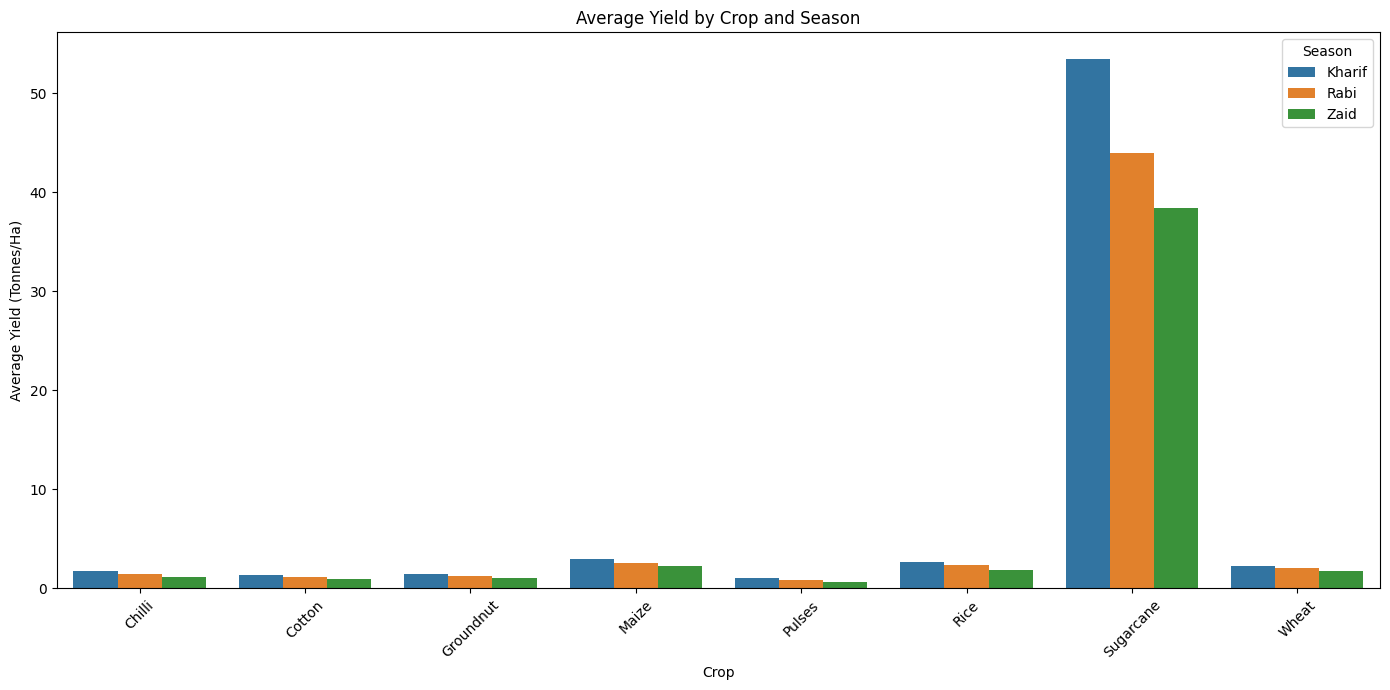

In [188]:
plt.figure(figsize=(14, 7))

sns.barplot(
    data=crop_season_summary,
    x='Crop',
    y='Avg_Yield',
    hue='Season'
)

plt.title('Average Yield by Crop and Season')
plt.xlabel('Crop')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.legend(title='Season')
plt.tight_layout()
plt.show()

### Interpretation

The Crop × Season analysis helps determine whether a crop performs
consistently throughout the year or whether its performance depends
strongly on the growing season.

Higher values of average yield indicate combinations that are more
productive per hectare. However, yield alone should not be used to
select the best combination because profitability, water efficiency,
and disease/pest risk must also be considered.

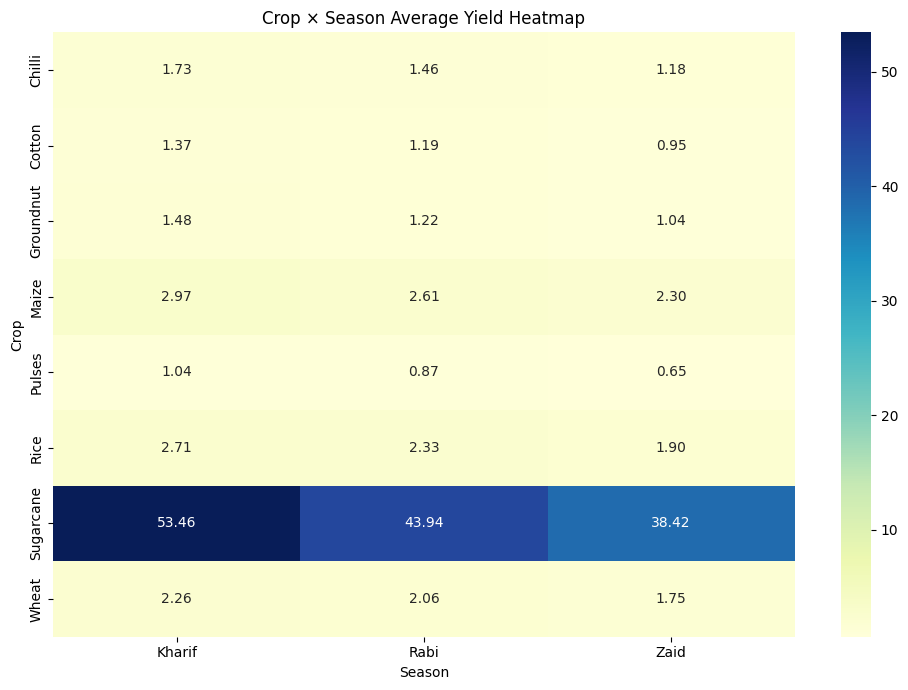

In [189]:
crop_season_pivot = crop_season_summary.pivot(
    index='Crop',
    columns='Season',
    values='Avg_Yield'
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    crop_season_pivot,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Crop × Season Average Yield Heatmap')
plt.xlabel('Season')
plt.ylabel('Crop')
plt.tight_layout()
plt.show()

### Interpretation

The heatmap provides a quick comparison of crop performance across
Kharif, Rabi, and Zaid seasons.

Dark/high-value cells represent relatively better yield performance,
while lower-value cells indicate comparatively weaker performance.

This analysis can help identify crops that are particularly suitable
for specific seasons.

In [190]:
best_crop_season = crop_season_summary.sort_values(
    'Avg_Yield',
    ascending=False
).head(10)

worst_crop_season = crop_season_summary.sort_values(
    'Avg_Yield',
    ascending=True
).head(10)

print("Top 10 Crop–Season Combinations by Average Yield")
display(best_crop_season)

print("\nBottom 10 Crop–Season Combinations by Average Yield")
display(worst_crop_season)

Top 10 Crop–Season Combinations by Average Yield


,Crop,Season,Farms,Avg_Yield,Total_Production,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency,Avg_Risk
18,Sugarcane,Kharif,125,53.46,55759.37,1000790.81,13689.51,36.00,54.02
19,Sugarcane,Rabi,129,43.94,47118.96,731612.86,13757.14,27.92,39.85
20,Sugarcane,Zaid,51,38.42,16807.64,583635.80,14763.53,23.39,38.35
9,Maize,Kharif,234,2.97,5463.54,-39332.67,4329.20,6.05,54.82
15,Rice,Kharif,314,2.71,7049.19,-64903.40,11378.45,2.17,54.25
10,Maize,Rabi,233,2.61,5030.78,-89133.40,4416.94,5.46,39.41
16,Rice,Rabi,274,2.33,4719.24,-98427.87,10178.32,1.84,40.79
11,Maize,Zaid,84,2.30,1507.08,-194049.17,4404.45,4.75,36.68
21,Wheat,Kharif,292,2.26,5345.95,-105871.87,4294.81,4.76,55.58
22,Wheat,Rabi,237,2.06,3807.63,-119954.57,3804.25,4.69,41.46



Bottom 10 Crop–Season Combinations by Average Yield


,Crop,Season,Farms,Avg_Yield,Total_Production,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency,Avg_Risk
14,Pulses,Zaid,62,0.65,306.46,-139227.81,2647.19,1.95,38.97
13,Pulses,Rabi,213,0.87,1533.28,-14309.14,2867.45,2.70,40.08
5,Cotton,Zaid,92,0.95,637.62,-53925.34,5385.88,1.49,36.34
12,Pulses,Kharif,221,1.04,1831.36,43338.90,2853.42,3.35,54.96
8,Groundnut,Zaid,54,1.04,465.55,-68872.50,3792.30,2.47,39.13
2,Chilli,Zaid,64,1.18,638.56,448659.09,4986.30,2.20,40.50
4,Cotton,Rabi,201,1.19,1897.64,107343.59,5377.81,1.94,41.54
7,Groundnut,Rabi,177,1.22,1603.90,10416.54,3490.11,2.90,39.76
3,Cotton,Kharif,215,1.37,2237.84,216999.55,5452.45,2.13,54.24
1,Chilli,Rabi,163,1.46,1787.45,638572.50,4351.58,2.89,40.59


### Interpretation

The ranking identifies the crop–season combinations with the highest
and lowest average productivity.

These results can be used to prioritize suitable crop choices for
different seasons. However, recommendations should also consider
profitability, water availability, and environmental risk.

In [191]:
state_season_summary = (
    df_clean.groupby(['State', 'Season'])
    .agg(
        Farms=('Farm_ID', 'count'),
        Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
        Total_Production=('Production_Tonnes', 'sum'),
        Avg_Profit=('Profit_INR', 'mean'),
        Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
        Avg_Risk=('Disease_Pest_Risk_pct', 'mean')
    )
    .reset_index()
)

display(
    state_season_summary.sort_values(
        'Avg_Yield',
        ascending=False
    ).head(15)
)

,State,Season,Farms,Avg_Yield,Total_Production,Avg_Profit,Avg_Water_Efficiency,Avg_Risk
16,Punjab,Rabi,186,8.61,13948.49,169294.52,6.68,40.48
8,Karnataka,Zaid,74,6.62,3911.90,23310.91,5.30,37.09
6,Karnataka,Kharif,209,6.52,11785.02,201226.21,5.89,53.92
3,Gujarat,Kharif,221,6.34,12051.63,217051.33,6.38,53.51
9,Madhya Pradesh,Kharif,226,6.00,9901.52,134242.40,6.22,54.78
17,Punjab,Zaid,77,5.91,4314.39,62109.69,4.92,35.72
0,Andhra Pradesh,Kharif,240,5.69,11095.26,169315.52,6.12,54.63
21,Telangana,Kharif,234,5.57,9735.09,199668.38,5.83,55.34
11,Madhya Pradesh,Zaid,63,5.54,2638.05,209.70,4.90,40.73
18,Tamil Nadu,Kharif,206,5.52,10940.87,211303.96,6.07,55.08


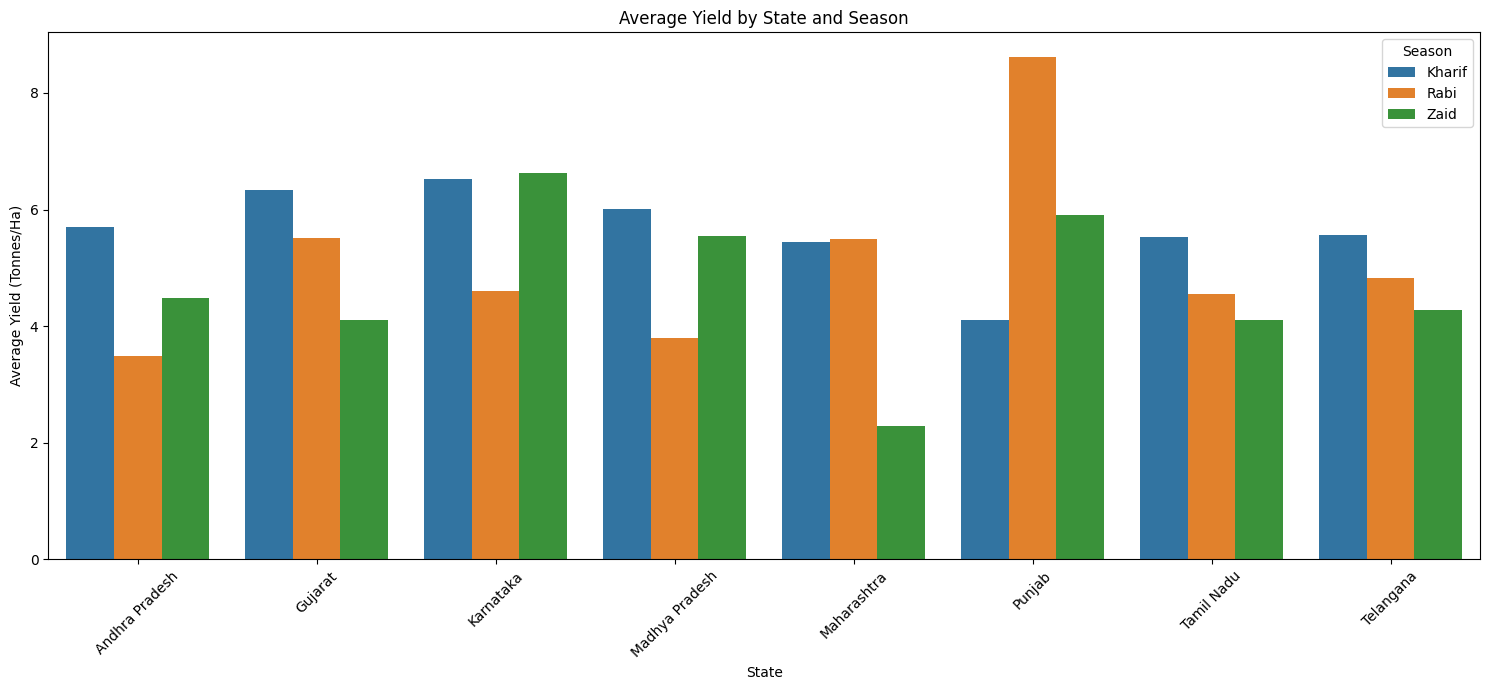

In [192]:
plt.figure(figsize=(15, 7))

sns.barplot(
    data=state_season_summary,
    x='State',
    y='Avg_Yield',
    hue='Season'
)

plt.title('Average Yield by State and Season')
plt.xlabel('State')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.legend(title='Season')
plt.tight_layout()
plt.show()

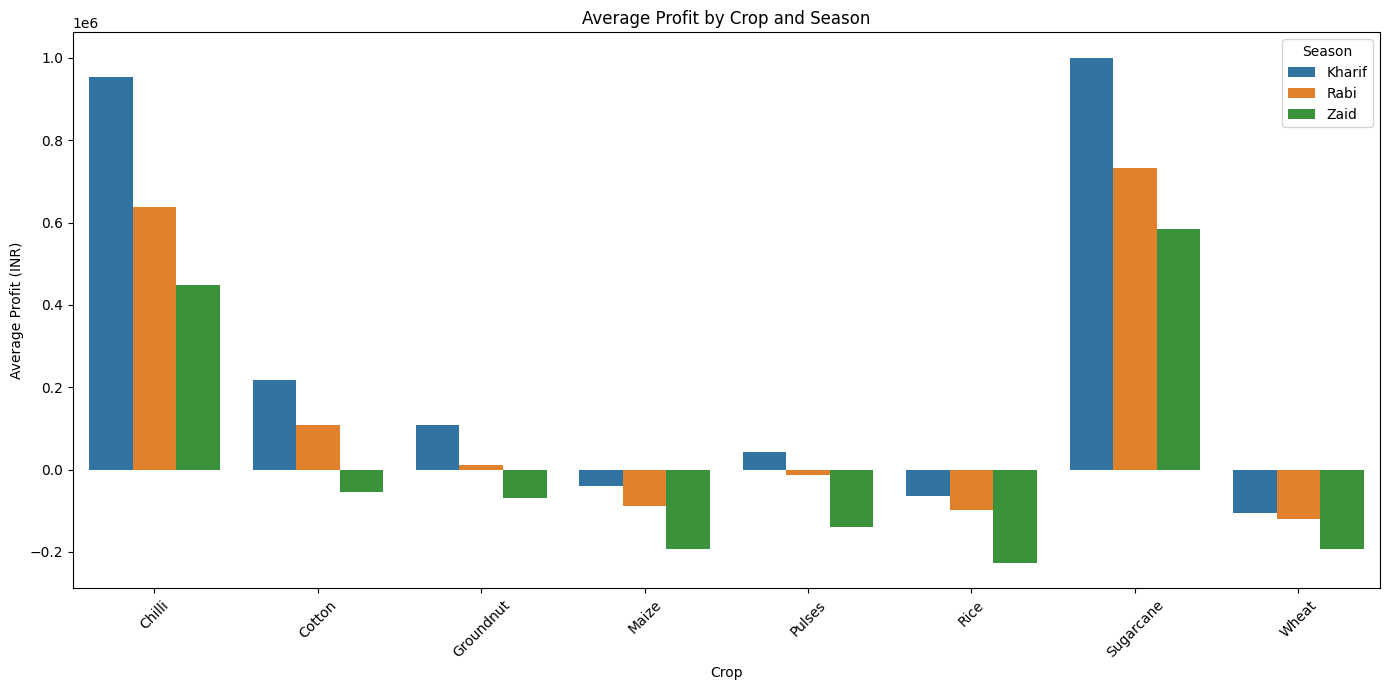

In [193]:
profit_season_crop = (
    df_clean.groupby(['Season', 'Crop'])['Profit_INR']
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=profit_season_crop,
    x='Crop',
    y='Profit_INR',
    hue='Season'
)

plt.title('Average Profit by Crop and Season')
plt.xlabel('Crop')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)
plt.legend(title='Season')
plt.tight_layout()
plt.show()

### Interpretation

Profitability provides a more complete picture of agricultural
performance than yield alone.

A crop may achieve high yield but still generate lower profit because
of high production costs, water consumption, fertilizer expenses,
pesticide usage, or market-price differences.

Therefore, crop selection should consider both productivity and
economic performance.

In [194]:
season_variability = (
    df_clean.groupby('Season')
    .agg(
        Mean_Yield=('Yield_Tonnes_Ha', 'mean'),
        Std_Yield=('Yield_Tonnes_Ha', 'std'),
        Mean_Profit=('Profit_INR', 'mean'),
        Std_Profit=('Profit_INR', 'std'),
        Mean_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
        Std_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'std')
    )
    .reset_index()
)

season_variability['Yield_CV_%'] = (
    season_variability['Std_Yield'] /
    season_variability['Mean_Yield']
) * 100

season_variability['Profit_CV_%'] = (
    season_variability['Std_Profit'].abs() /
    season_variability['Mean_Profit'].abs()
) * 100

display(season_variability)

,Season,Mean_Yield,Std_Yield,Mean_Profit,Std_Profit,Mean_Water_Efficiency,Std_Water_Efficiency,Yield_CV_%,Profit_CV_%
0,Kharif,5.64,14.42,178914.65,611549.78,5.89,9.83,255.48,341.81
1,Rabi,5.08,12.83,87689.47,489901.25,5.19,8.26,252.44,558.68
2,Zaid,4.67,11.32,-24804.82,436356.75,4.41,6.93,242.56,1759.16


### Interpretation

Standard deviation measures the absolute variability of a performance
indicator, while the coefficient of variation (CV) expresses
variability relative to the mean.

A higher CV indicates greater inconsistency.

This analysis is useful because a season with a high average yield may
still be less predictable if its yield varies substantially between
farms.

In [195]:
most_consistent_yield_season = season_variability.loc[
    season_variability['Yield_CV_%'].idxmin()
]

most_variable_yield_season = season_variability.loc[
    season_variability['Yield_CV_%'].idxmax()
]

print(
    "Most consistent season based on yield CV:",
    most_consistent_yield_season['Season']
)

print(
    "Most variable season based on yield CV:",
    most_variable_yield_season['Season']
)

Most consistent season based on yield CV: Zaid
Most variable season based on yield CV: Kharif


In [196]:
performance_summary = (
    df_clean.groupby(['Crop', 'Season'])
    .agg(
        Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
        Avg_Profit=('Profit_INR', 'mean'),
        Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
        Avg_Risk=('Disease_Pest_Risk_pct', 'mean')
    )
    .reset_index()
)

# Min-Max normalization
def min_max_scale(series):
    if series.max() == series.min():
        return pd.Series(1.0, index=series.index)
    return (series - series.min()) / (series.max() - series.min())

performance_summary['Yield_Score'] = min_max_scale(
    performance_summary['Avg_Yield']
)

performance_summary['Profit_Score'] = min_max_scale(
    performance_summary['Avg_Profit']
)

performance_summary['Water_Efficiency_Score'] = min_max_scale(
    performance_summary['Avg_Water_Efficiency']
)

# Lower disease/pest risk is better
performance_summary['Risk_Score'] = 1 - min_max_scale(
    performance_summary['Avg_Risk']
)

performance_summary['Overall_Performance_Score'] = (
    0.30 * performance_summary['Yield_Score'] +
    0.30 * performance_summary['Profit_Score'] +
    0.20 * performance_summary['Water_Efficiency_Score'] +
    0.20 * performance_summary['Risk_Score']
)

performance_summary = performance_summary.sort_values(
    'Overall_Performance_Score',
    ascending=False
)

display(performance_summary.head(10))

,Crop,Season,Avg_Yield,Avg_Profit,Avg_Water_Efficiency,Avg_Risk,Yield_Score,Profit_Score,Water_Efficiency_Score,Risk_Score,Overall_Performance_Score
18,Sugarcane,Kharif,53.46,1000790.81,36.00,54.02,1.00,1.00,1.00,0.08,0.82
19,Sugarcane,Rabi,43.94,731612.86,27.92,39.85,0.82,0.78,0.77,0.82,0.80
20,Sugarcane,Zaid,38.42,583635.80,23.39,38.35,0.72,0.66,0.63,0.90,0.72
1,Chilli,Rabi,1.46,638572.50,2.89,40.59,0.02,0.71,0.04,0.78,0.38
0,Chilli,Kharif,1.73,954380.42,3.26,52.81,0.02,0.96,0.05,0.14,0.33
2,Chilli,Zaid,1.18,448659.09,2.20,40.50,0.01,0.55,0.02,0.78,0.33
5,Cotton,Zaid,0.95,-53925.34,1.49,36.34,0.01,0.14,0.00,1.00,0.24
10,Maize,Rabi,2.61,-89133.40,5.46,39.41,0.04,0.11,0.12,0.84,0.24
7,Groundnut,Rabi,1.22,10416.54,2.90,39.76,0.01,0.19,0.04,0.82,0.23
4,Cotton,Rabi,1.19,107343.59,1.94,41.54,0.01,0.27,0.01,0.73,0.23


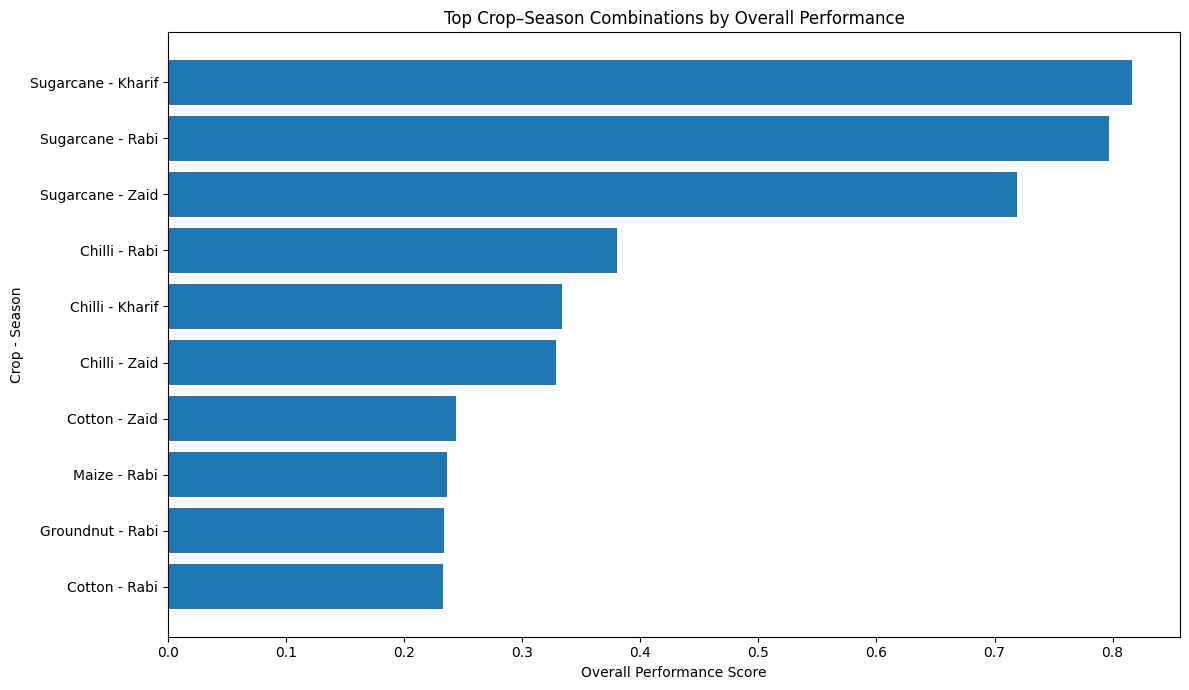

In [197]:
top_combinations = performance_summary.head(10)

plt.figure(figsize=(12, 7))

labels = (
    top_combinations['Crop'] +
    " - " +
    top_combinations['Season']
)

plt.barh(
    labels,
    top_combinations['Overall_Performance_Score']
)

plt.xlabel('Overall Performance Score')
plt.ylabel('Crop - Season')
plt.title('Top Crop–Season Combinations by Overall Performance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Interpretation

The overall performance score combines multiple agricultural
dimensions instead of relying on a single metric.

The weighting used in this project is:

- 30% Yield
- 30% Profit
- 20% Water Efficiency
- 20% Disease/Pest Risk

Higher scores represent stronger overall performance.

This score is intended as an analytical comparison rather than a
universal agricultural standard. Different farming objectives may
require different weights.

In [198]:
final_season_summary = (
    df_clean.groupby('Season')
    .agg(
        Farms=('Farm_ID', 'count'),
        Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
        Total_Production=('Production_Tonnes', 'sum'),
        Avg_Profit=('Profit_INR', 'mean'),
        Avg_Water_Used=('Water_Used_m3', 'mean'),
        Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
        Avg_Disease_Risk=('Disease_Pest_Risk_pct', 'mean')
    )
    .reset_index()
)

display(final_season_summary)

,Season,Farms,Avg_Yield,Total_Production,Avg_Profit,Avg_Water_Used,Avg_Water_Efficiency,Avg_Disease_Risk
0,Kharif,1779,5.64,82387.61,178914.65,6102.20,5.89,54.47
1,Rabi,1627,5.08,67498.88,87689.47,5846.99,5.19,40.48
2,Zaid,594,4.67,23098.35,-24804.82,6419.89,4.41,38.22


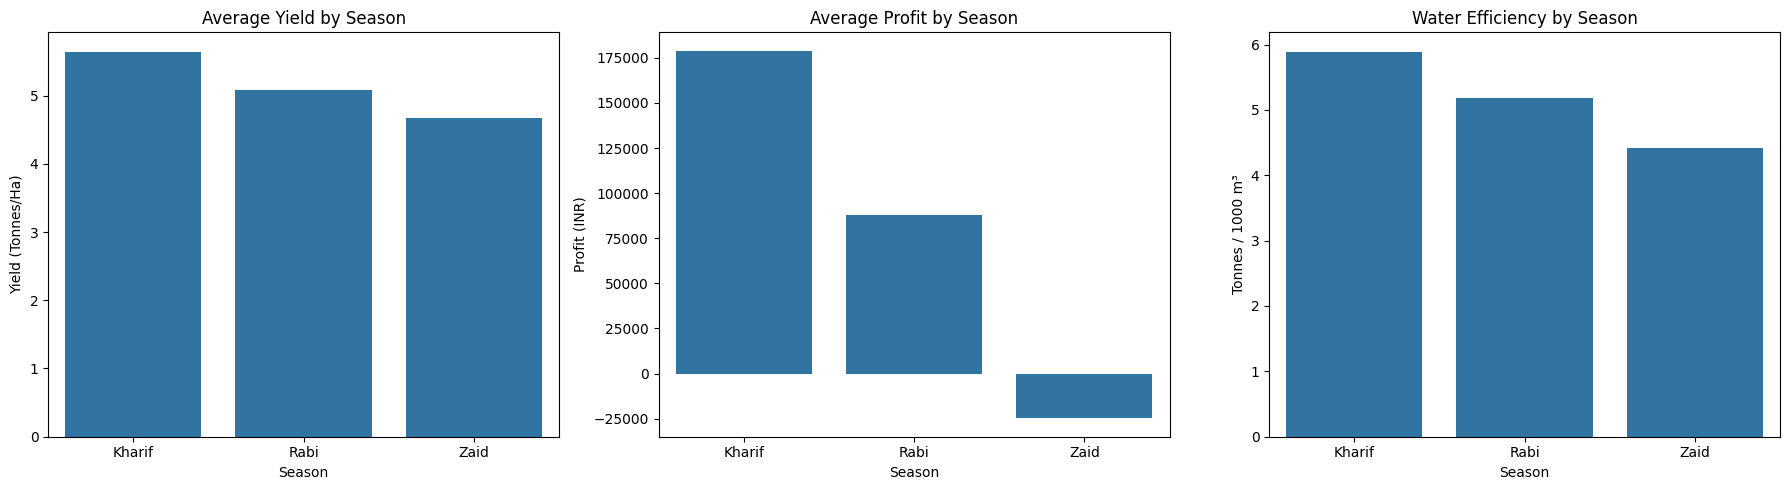

In [199]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    data=final_season_summary,
    x='Season',
    y='Avg_Yield',
    ax=axes[0]
)

axes[0].set_title('Average Yield by Season')
axes[0].set_ylabel('Yield (Tonnes/Ha)')

sns.barplot(
    data=final_season_summary,
    x='Season',
    y='Avg_Profit',
    ax=axes[1]
)

axes[1].set_title('Average Profit by Season')
axes[1].set_ylabel('Profit (INR)')

sns.barplot(
    data=final_season_summary,
    x='Season',
    y='Avg_Water_Efficiency',
    ax=axes[2]
)

axes[2].set_title('Water Efficiency by Season')
axes[2].set_ylabel('Tonnes / 1000 m³')

plt.tight_layout()
plt.show()

## Final Findings

Based on the complete analysis of the Seasonal Agriculture dataset,
the following major findings can be established:

### 1. Seasonal Performance

The three agricultural seasons show clear differences in productivity,
profitability, resource usage, and environmental conditions.

Kharif, Rabi, and Zaid should therefore not be treated as identical
production environments.

### 2. Yield Performance

Seasonal and crop-level comparisons demonstrate that crop productivity
varies across growing conditions.

The Crop × Season analysis provides a more useful picture than looking
at overall crop averages alone.

### 3. Environmental Conditions

Rainfall, temperature, humidity, sunlight, and soil moisture vary
considerably across seasons.

However, the overall correlations between these environmental
variables and yield are weak in this dataset. This indicates that
agricultural performance depends on multiple interacting factors.

### 4. Resource Utilization

Water consumption and water-use efficiency differ between seasons,
crops, and irrigation methods.

Higher water usage does not automatically guarantee higher yield.

### 5. Economic Performance

Profitability varies significantly across seasons and crop groups.

Therefore, maximum production does not necessarily imply maximum
economic return.

### 6. Risk

Disease and pest risk varies between agricultural groups.

High-risk combinations should receive additional monitoring and
preventive management.

### 7. Regional Differences

State and district comparisons reveal geographical variation in
yield, profitability, production, water efficiency, and agricultural
risk.

### 8. Statistical Evidence

ANOVA and post-hoc testing provide statistical evidence for determining
whether observed differences between seasons are meaningful rather than
simply random variation.

### 9. Outliers

Extreme observations were detected in environmental conditions,
resource consumption, yield, production, and profitability.

These observations should be investigated rather than automatically
removed because they may represent either unusual farming conditions
or particularly successful/unsuccessful farms.

### 10. Multi-Factor Performance

The final performance score demonstrates that the best agricultural
option should ideally balance:

- Productivity
- Profitability
- Water efficiency
- Risk management

## Recommendations

### Recommendation 1: Select Crops According to Season

Farmers and planners should use Crop × Season performance analysis to
identify crops that are naturally better suited to specific seasons.

### Recommendation 2: Focus on Profit, Not Only Yield

High yield should not be considered the only indicator of success.
Production cost, market price, revenue, and profit should also be
included in crop-selection decisions.

### Recommendation 3: Improve Water Efficiency

Water-efficient crops and irrigation methods should be prioritized,
particularly in seasons with relatively high water requirements.

### Recommendation 4: Monitor High-Risk Combinations

Crop–season or regional combinations with elevated disease/pest risk
should receive additional monitoring and preventive measures.

### Recommendation 5: Investigate Regional Differences

States and districts with consistently strong performance can provide
useful benchmarks, while weaker regions may require targeted
resource-management strategies.

### Recommendation 6: Use Data-Driven Planning

Historical seasonal patterns should be incorporated into future crop
planning, resource allocation, irrigation scheduling, and financial
planning.

### Recommendation 7: Investigate Anomalies

Extreme yield, water-use, cost, or profit observations should be
investigated before making operational decisions.

### Recommendation 8: Use Multi-Factor Decision Making

Agricultural decisions should balance yield, profit, water efficiency,
and risk rather than optimizing a single metric.

# Conclusion

The Seasonal Agriculture Performance Analysis successfully examined
agricultural performance across seasons, geographical regions, crops,
resources, environmental conditions, irrigation methods, and economic
factors.

The analysis demonstrates that agricultural performance is influenced
by multiple dimensions rather than a single environmental or resource
variable.

Seasonal comparison revealed differences in yield, production,
profitability, water consumption, water efficiency, and disease/pest
risk. Crop-wise, state-wise, district-wise, irrigation-wise, and
seed-quality comparisons provided additional insight into the factors
associated with stronger agricultural outcomes.

Statistical analysis was used to evaluate whether seasonal differences
were statistically meaningful, while correlation analysis helped
identify relationships between agricultural variables. Outlier analysis
further highlighted unusual observations that may require additional
investigation.

The advanced Crop × Season and State × Season analyses provided a
more detailed understanding of agricultural patterns. The final
multi-factor performance score combined productivity, profitability,
water efficiency, and risk to provide a broader measure of performance.

Overall, the project shows how exploratory data analysis, statistical
methods, visualization, and comparative analysis can transform raw
agricultural data into meaningful evidence for agricultural planning
and decision-making.

The findings can support farmers, agricultural planners, and
decision-makers in selecting suitable crops, improving resource
efficiency, managing risk, and improving economic outcomes.

In [200]:
# Dataset shape
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Duplicate records
print("Duplicates:", df.duplicated().sum())

# Missing values
print(df.isnull().sum()[df.isnull().sum() > 0])

# Handle missing values
df_clean = df.copy()

df_clean['Rainfall_mm'] = (
    df_clean['Rainfall_mm']
    .fillna(df_clean['Rainfall_mm'].median())
)

df_clean['Soil_Moisture_pct'] = (
    df_clean['Soil_Moisture_pct']
    .fillna(df_clean['Soil_Moisture_pct'].median())
)

Rows: 4000
Columns: 28
Duplicates: 0
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64
